### Імпорт бібліотек, встановлення налаштувань відображення, завантаження файлу

In [235]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os 
import statsmodels.formula.api as smf

In [236]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

In [237]:
df = pd.read_csv("D:\\my_projects\\kursah\\data\\raw\\result_test_10000.csv")

In [238]:
# Створюємо папку для графіків
os.makedirs('plots', exist_ok=True)

In [239]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   price_UAH           10000 non-null  str  
 1   price_USD           10000 non-null  str  
 2   title               10000 non-null  str  
 3   location_list       10000 non-null  str  
 4   details_list        10000 non-null  str  
 5   advantages_list     10000 non-null  str  
 6   description         10000 non-null  str  
 7   created_at          10000 non-null  str  
 8   facilities_list     10000 non-null  str  
 9   technically_tested  10000 non-null  str  
 10  seller_name         10000 non-null  str  
 11  seller_trust        10000 non-null  str  
 12  city                10000 non-null  str  
 13  plus_text           10000 non-null  str  
 14  url                 10000 non-null  str  
 15  page                10000 non-null  int64
dtypes: int64(1), str(15)
memory usage: 1.2 MB


## 1. Очистка і формування стовпчиків для аналізу

### Загальні стовпці з ціною, id, кількістю кімнат

In [240]:
df['id'] = df['title'].str.extract(r'ID (\d+)')
df['rooms'] = df['title'].str.extract(r'(\d+)к квартири', expand=False).astype('Int64')
df['price_UAH'] = df['price_UAH'].str.replace(' ', '').str.extract(r'(\d+)', expand=False).astype('Int64')
df['price_USD'] = df['price_USD'].str.replace(' ', '').str.extract(r'(\d+)', expand=False).astype('Int64')

### Стовпець дати

In [241]:
months = {
    'січ': '01', 'лют': '02', 'бер': '03', 'кві': '04',
    'тра': '05', 'чер': '06', 'лип': '07', 'сер': '08',
    'вер': '09', 'жов': '10', 'лис': '11', 'гру': '12'
}
extracted = df['created_at'].str.extract(r'(\d+)\s+([а-яіїєґ]+)\.*\s*(\d{4})?')
extracted.columns = ['day', 'month_abbr', 'year']
current_year = str(pd.Timestamp.now().year)
extracted['year'] = extracted['year'].fillna(current_year)
extracted['month'] = extracted['month_abbr'].map(months)

df['date'] = pd.to_datetime(
    extracted['day'] + '.' + extracted['month'] + '.' + extracted['year'],
    format='%d.%m.%Y'
)

### Створення стовпців з локацією

In [242]:
df['city_name'] = df['city'].str.split(',').str[2].str.strip().astype(str)
df['district'] = df['location_list'].str.extract(r'район\s+([^|]+)')[0].str.strip()
df['metro'] = df['location_list'].str.extract(r'метро\s+([^|]+)')[0].str.strip()
df['address'] = df['title'].str.extract(r'на\s+((?:вул|просп|бул|пров|пл|шосе|наб)\.?\s+.+?)(?=\s*•)')[0].str.strip()

### Створення стовпців з інформацією про продавця

In [243]:
df['seller'] = df['seller_name'].str.extract(r'\n([А-ЯІЇЄҐа-яA-Za-z][^\n\d]+?)(?:\n|$)')[0].str.strip()

def experience_to_months(text):
    if pd.isna(text):
        return 0
    
    years  = re.search(r'(\d+)\+?\s*рок|(\d+)\+?\s*рік', text)
    months = re.search(r'(\d+)\s*місяц', text)
    days   = re.search(r'(\d+)\s*дн', text)
    
    total = 0
    if years:
        total += int(years.group(1) or years.group(2)) * 12
    if months:
        total += int(months.group(1))
    if days:
        total += int(days.group(1)) / 30
    
    return total

def categorize(months):
    if months < 12:
        return 'Новачок'        # < 1 року
    elif months < 36:
        return 'Досвідчений'     # 1–3 роки
    elif months < 60:
        return 'Професіонал'  # 3–5 років
    else:
        return 'Експерт'      # 5+ років
    
df['experience_months'] = df['seller_trust'].apply(experience_to_months).round().astype(int)
df['seller_level'] = df['experience_months'].apply(categorize)

print(df[['experience_months', 'seller_level']].head(10))

   experience_months seller_level
0                 60      Експерт
1                  0      Новачок
2                 60      Експерт
3                 60      Експерт
4                 51  Професіонал
5                 10      Новачок
6                 60      Експерт
7                 22  Досвідчений
8                 35  Досвідчений
9                 60      Експерт


### Створення стовпців по площі 

In [244]:
df['area_total']   = df['details_list'].str.extract(r'[Зз]агальна площа\s+([\d.]+)')[0]
df['area_living']  = df['details_list'].str.extract(r'житлова\s+([\d.]+)')[0]
df['area_kitchen'] = df['details_list'].str.extract(r'кухня\s+([\d.]+)')[0]

for col in ['area_total', 'area_living', 'area_kitchen']:
    df[col] = df[col].astype(float)

print(df[['area_total', 'area_living', 'area_kitchen']].head(10))

   area_total  area_living  area_kitchen
0        27.0         16.0           6.0
1        56.8         39.7           5.3
2       140.0         55.4          34.2
3        87.0         60.0          20.0
4       198.8        113.6          14.0
5       132.0          NaN          22.0
6       193.1        106.2          20.2
7        44.3         14.4          10.0
8       150.0        120.0          17.0
9        60.0         27.0          12.0


### Створення стовпців поверху квартири та поверховості будинку

In [245]:
df['floor_current'] = df['technically_tested'].str.extract(r'(\d+)\s+поверх з')[0].astype('Int64')
df['floor_total']   = df['technically_tested'].str.extract(r'поверх з\s+(\d+)')[0].astype('Int64')

print(df[['floor_current', 'floor_total']].head(10))

   floor_current  floor_total
0              3            4
1              5            6
2              7            8
3              5           16
4             14           15
5             18           26
6              4           17
7              3           25
8              2            6
9              3           12


### Створення бінарних стовпців по особливостям планування

In [246]:
df['kitchen_studio'] = df['plus_text'].str.extract(r'(Кухня-студія)', flags=re.IGNORECASE)
df['penthouse']      = df['plus_text'].str.extract(r'(Пентхаус)', flags=re.IGNORECASE)
df['multilevel']     = df['plus_text'].str.extract(r'(Багаторівнева)', flags=re.IGNORECASE)

for col in ['kitchen_studio', 'penthouse', 'multilevel']:
    df[col] = df[col].notna().astype(int)

print(df[['kitchen_studio', 'penthouse', 'multilevel']].head(20))

    kitchen_studio  penthouse  multilevel
0                1          0           0
1                0          0           0
2                1          1           1
3                1          0           0
4                1          0           1
5                0          0           0
6                0          0           0
7                0          0           0
8                0          0           0
9                1          0           0
10               0          0           0
11               1          0           0
12               0          0           0
13               0          0           0
14               1          0           0
15               1          0           0
16               1          0           0
17               0          0           0
18               0          0           0
19               0          0           0


### Створення стовпця про наявність укриття 

In [247]:
df['shelter'] = df['advantages_list'].str.extract(r'((?:У|у)криття[^|]+)')[0].str.strip()

def extract_shelter_context(text):
    if pd.isna(text):
        return None
    match = re.search(r'(\S+\s+){0,2}\S*[Уу]крит\S*(\s+\S+){0,2}', text)
    return match.group().strip() if match else None

df['shelter_context'] = df['description'].apply(extract_shelter_context)
df['shelter_plus'] = df['plus_text'].apply(extract_shelter_context)

print(df['shelter'].head(10))

0    Укриття в будинку
1                  NaN
2                  NaN
3                  NaN
4                  NaN
5    Укриття в будинку
6                  NaN
7    Укриття в будинку
8    Укриття в будинку
9                  NaN
Name: shelter, dtype: str


Зведення до єдиної бінарної колонки по наявності укриття:

In [248]:
df['shelter_plus'] = df['shelter_plus'].str.contains('укриття', case=False, na=False).astype(int)
df['shelter_context'] = df['shelter_context'].str.contains('укриття', case=False, na=False).astype(int)
df['shelter'] = df['shelter'].str.contains('укриття', case=False, na=False).astype(int)

shelter_columns = ['shelter_plus', 'shelter_context', 'shelter']
df['has_shelter'] = df[shelter_columns].any(axis=1).astype(int)


# print(df[['shelter_plus', 'shelter_context', 'shelter']])
print(df['has_shelter'].value_counts())

has_shelter
0    7094
1    2906
Name: count, dtype: int64


### Створення стовпця дозволу проживання з тваринами

In [249]:
df['pets'] = df['facilities_list'].str.extract(r'((?:[Мм]ожна|[Нн]е можна|[Бб]ез)\s+з?\s*тварин[^|]*)')[0].str.strip()

def extract_bober_context(text):
    if pd.isna(text):
        return None
    match = re.search(r'(\S+\s+){0,2}\S*[Тт]варин\S*(\s+\S+){0,2}', text)
    return match.group().strip() if match else None

df['pets_desc'] = df['description'].apply(extract_bober_context)

Зведення до єдиної бінарної колонки по дозволу проживання з тваринами:

In [250]:
df['pets'] = df['pets'].fillna('Не вказано')

def classify_pets_desc(text):
    if pd.isna(text):
        return None
    text_lower = text.lower()
    
    if re.search(r'без тварин|не можна|заборон|неможлив|не приймаємо тварин|не розглядаєть|не розглядаємо', text_lower):
        return 'не можна'
    
    if re.search(r'тварин|тваринк', text_lower):
        return 'можна'
    
    return None

df['pets_classified'] = df['pets_desc'].apply(classify_pets_desc)

df['pets'] = df['pets'].fillna(df['pets_classified']).fillna('не вказано')


print(df['pets'].value_counts())

pets
Не вказано           5220
Без тварин           2833
Можна з тваринами    1947
Name: count, dtype: int64


### Створення стовпців забезпеченості при відсутності електроенергії.   

In [251]:
features = {
    'no_light_internet':    'є інтернет',
    'no_light_mobile_connection':      'є мобільний зв\'язок',
    'no_light_water':       'є водопостачання',
    'no_light_heating':     'працює опалення',
    'no_light_gas':         'є газ',
    'no_light_elevator':    'працює ліфт'
}

for col, keyword in features.items():
    df[col] = df['plus_text'].str.contains(keyword, case=False, na=False).astype(int)

df[['no_light_internet', 'no_light_mobile_connection', 'no_light_water', 'no_light_heating', 'no_light_gas',
           'no_light_elevator']].head(10)

,no_light_internet,no_light_mobile_connection,no_light_water,no_light_heating,no_light_gas,no_light_elevator
0,1,0,0,0,0,0
1,1,0,1,1,1,0
2,1,0,1,1,1,0
3,1,0,1,1,0,1
4,1,0,0,1,0,1
5,0,0,0,0,0,0
6,0,0,0,0,0,0
7,1,1,1,1,0,1
8,0,0,0,0,0,0
9,1,1,1,0,1,0


### **Створення кінцевого датасету**

In [252]:
cl_df = df[['id', 'rooms', 'price_UAH', 'price_USD', 'date', 'city_name', 'district', 'metro', 'address', 'seller',
            'experience_months', 'seller_level', 'area_total', 'area_living', 'area_kitchen', 'floor_current', 
            'floor_total', 'kitchen_studio', 'penthouse', 'multilevel', 'has_shelter', 'pets', 'no_light_internet',
            'no_light_mobile_connection', 'no_light_water', 'no_light_heating', 'no_light_gas', 'no_light_elevator',
            'url']].copy()

print(cl_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   id                          9998 non-null   str           
 1   rooms                       9998 non-null   Int64         
 2   price_UAH                   9998 non-null   Int64         
 3   price_USD                   9998 non-null   Int64         
 4   date                        9998 non-null   datetime64[us]
 5   city_name                   9933 non-null   str           
 6   district                    8941 non-null   str           
 7   metro                       3492 non-null   str           
 8   address                     9751 non-null   str           
 9   seller                      9995 non-null   str           
 10  experience_months           10000 non-null  int64         
 11  seller_level                10000 non-null  str           
 12  ar

## 2. EDA (Exploratory Data Analysis)

### 1. Обробка пропущених значень

In [253]:
cl_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   id                          9998 non-null   str           
 1   rooms                       9998 non-null   Int64         
 2   price_UAH                   9998 non-null   Int64         
 3   price_USD                   9998 non-null   Int64         
 4   date                        9998 non-null   datetime64[us]
 5   city_name                   9933 non-null   str           
 6   district                    8941 non-null   str           
 7   metro                       3492 non-null   str           
 8   address                     9751 non-null   str           
 9   seller                      9995 non-null   str           
 10  experience_months           10000 non-null  int64         
 11  seller_level                10000 non-null  str           
 12  ar

#### Перевірка і видалення дублікатів

Спочатку перевіряємо повністю дублюючі рядки і видаляємо дублікати. 

In [254]:
n_duplicates = cl_df.duplicated().sum()
print(f"Кількість повних дублікатів: {n_duplicates}")
print(f"Це {n_duplicates / len(cl_df) * 100:.2f}% від усіх рядків ({len(cl_df)} загалом)")

cl_df = cl_df.drop_duplicates()
print(f"\nПісля видалення: {len(cl_df)} рядків залишилось")

Кількість повних дублікатів: 201
Це 2.01% від усіх рядків (10000 загалом)

Після видалення: 9799 рядків залишилось


Далі перевіряємо і видаляємо дублікати по колонці `id`

In [255]:
n_duplicates_id = cl_df.duplicated(subset=['id']).sum()
print(f"Кількість дублікатів по колонці id: {n_duplicates_id}")
print(f"Це {n_duplicates_id / len(cl_df) * 100:.2f}% від усіх рядків ({len(cl_df)} загалом)")

cl_df = cl_df.drop_duplicates(subset=['id'])
print(f"\nПісля видалення: {len(cl_df)} рядків залишилось")

Кількість дублікатів по колонці id: 10
Це 0.10% від усіх рядків (9799 загалом)

Після видалення: 9789 рядків залишилось


Додатково перевіряємо і видаляємо дублікати за ціною, площею та адресою. Скоріш за все це спам рієлторів для підняття оголошень в топ при повторному опублікуванні.

In [256]:
# 1. Рахуємо загальну кількість "схованих" дублікатів
columns_to_check = ['price_UAH', 'rooms', 'area_total', 'floor_current', 'address']
dup_count = cl_df.duplicated(subset=columns_to_check).sum()

print(f"Знайдено прихованих дублікатів (рієлторського спаму): {dup_count}")

# 2. Дістаємо всі ці рядки (і оригінали, і їхні копії)
semantic_duplicates = cl_df[cl_df.duplicated(subset=columns_to_check, keep=False)]

# 3. Виводимо їх на екран, відсортувавши за ціною та площею
if not semantic_duplicates.empty:
    print("\nОсь як вони виглядають:")
    print(semantic_duplicates.sort_values(by=['price_UAH', 'area_total'])[
        ['id', 'price_UAH', 'rooms', 'area_total', 'floor_current', 'address']
    ].head(20))

Знайдено прихованих дублікатів (рієлторського спаму): 94

Ось як вони виглядають:
            id  price_UAH  rooms  area_total  floor_current  \
4249  33955060       5000      1        20.0              3   
7665  33510975       5000      1        20.0              3   
7593  33526587       6000      1        20.0              1   
8082  33409948       6000      1        20.0              1   
8250  33357853       6000      1        20.0              3   
8363  33322073       6000      1        20.0              3   
8606  33216945       6000      1        20.0              2   
8739  33166565       6000      1        20.0              2   
2495  34036223       6000      1        22.0              6   
3744  33989698       6000      1        22.0              6   
7652  33513930       6000      1        22.0              2   
8108  33400006       6000      1        22.0              2   
5345  33861527       6500      1        25.0              1   
7297  33535555       6500      1    

In [257]:
print(f"Довжина датасету до видалення дублікатів: {len(cl_df)}")
cl_df = cl_df.drop_duplicates(subset=['price_UAH', 'rooms', 'area_total', 'floor_current', 'address'], keep='first')
print(f"Довжина датасету після видалення дублікатів: {len(cl_df)}")

Довжина датасету до видалення дублікатів: 9789
Довжина датасету після видалення дублікатів: 9695


Також видаляємо схожі оголошення від одного автора за основною колонкою `seller`

In [258]:
# 1. Рахуємо загальну кількість "схованих" дублікатів
columns_to_check = ['price_UAH', 'rooms', 'area_total', 'floor_current', 'seller']
dup_count = cl_df.duplicated(subset=columns_to_check).sum()

print(f"Знайдено прихованих дублікатів (рієлторського спаму): {dup_count}")

# 2. Дістаємо всі ці рядки (і оригінали, і їхні копії)
semantic_duplicates = cl_df[cl_df.duplicated(subset=columns_to_check, keep=False)]

# 3. Виводимо їх на екран, відсортувавши за ціною та площею
if not semantic_duplicates.empty:
    print("\nОсь як вони виглядають:")
    print(semantic_duplicates.sort_values(by=['price_UAH', 'area_total'])[
        ['id', 'price_UAH', 'rooms', 'area_total', 'floor_current', 'seller']
    ].head(20))

Знайдено прихованих дублікатів (рієлторського спаму): 73

Ось як вони виглядають:
            id  price_UAH  rooms  area_total  floor_current         seller
3267  34012904       4412      1        34.0              3  Анна Тодорова
4564  33930357       4412      1        34.0              3  Анна Тодорова
9329  32845255       5000      1        33.0              1   Олександр ОС
9354  32833533       5000      1        33.0              1   Олександр ОС
8737  33166694       5500      1        20.0              3          Ирина
8934  33062828       5500      1        20.0              3          Ирина
9015  33019329       5500      1        20.0              1          Ирина
9068  32992543       5500      1        20.0              2          Ирина
9069  32992197       5500      1        20.0              2          Ирина
9260  32890231       5500      1        20.0              4          Ирина
9283  32879037       5500      1        20.0              4          Ирина
9314  32856311    

In [259]:
print(f"Довжина датасету до видалення дублікатів: {len(cl_df)}")
cl_df = cl_df.drop_duplicates(subset=['price_UAH', 'rooms', 'area_total', 'floor_current', 'seller'], keep='first')
print(f"Довжина датасету після видалення дублікатів: {len(cl_df)}")

Довжина датасету до видалення дублікатів: 9695
Довжина датасету після видалення дублікатів: 9622


Також виконаємо пошук незважаючи на ціну і площу (їх можуть спеціально змінювати агенства) за кількістю кімнат, поверхом, містом і точною адресою. Під точною адресою я маю на увазі адреси з вказаним номером будинку, а не лише вулицею. Не точні адреси було вирішено не брати тому що на одній вулиці дійсно можуть бути квартири з однаковою кількістю кімнат і поверхом.

In [260]:
pattern = r'\d+[А-Яа-яa-zA-Z]?\s*$'
has_number = cl_df['address'].str.contains(pattern, na=False, regex=True)
df_precise_for_check = cl_df[has_number]
sneaky_duplicates = df_precise_for_check[df_precise_for_check.duplicated(subset=['rooms', 'floor_current', 'address', 'city_name'],
                                                                          keep=False)]

if not sneaky_duplicates.empty:
    print("Знайдено квартири за ТОЧНОЮ адресою, але з різною ціною/площею:")
    print(f"Знайдено рієлторських дублікатів: {len(sneaky_duplicates)}")
    print(sneaky_duplicates.sort_values(by=['address', 'floor_current'])[
        ['address', 'floor_current', 'price_UAH', 'area_total', 'seller', 'url']
    ].head(20))
else:
    print("Все ідеально чисто, хитрих дублікатів немає!")

Знайдено квартири за ТОЧНОЮ адресою, але з різною ціною/площею:
Знайдено рієлторських дублікатів: 707
                                  address  floor_current  price_UAH  \
5659                бул. Лесі Українки 7В             11      88140   
8705                бул. Лесі Українки 7В             11      48477   
8040                бул. Лесі Українки 7В             12      96954   
8224                бул. Лесі Українки 7В             12      96954   
6101                 бул. Французький 60А             13      17628   
8850                 бул. Французький 60А             13      30849   
3166                   вул. 600-річчя 66В             10      17000   
4213                   вул. 600-річчя 66В             10      17000   
105   вул. 93-ї Холодноярської Бригади 4А              4      44120   
5657  вул. 93-ї Холодноярської Бригади 4А              4      44070   
8409             вул. Євгена Сверстюка 6А              7      26000   
9719             вул. Євгена Сверстюка 6А     

In [261]:
print(f"Довжина датасету до видалення дублікатів: {len(cl_df)}")

cl_df = cl_df.sort_values(by='date', ascending=False)

# Для більшої точності для перевірки беремо лише точні адреси (з вказаним номером будинку), а адреси лише з вулицею не беремо.
pattern = r'\d+[А-Яа-яa-zA-Z]?\s*$'
has_number = cl_df['address'].str.contains(pattern, na=False, regex=True)
df_precise = cl_df[has_number].copy() # Адреси з номером (закінчуються на цифру)
df_broad = cl_df[~has_number].copy() # Тільки вулиці (закінчуються на букву)
df_precise = df_precise.drop_duplicates(subset=['city_name', 'address', 'rooms', 'floor_current'], keep='first')
cl_df = pd.concat([df_precise, df_broad])

print(f"Готово! Залишилося унікальних реальних квартир: {len(cl_df)}")

Довжина датасету до видалення дублікатів: 9622
Готово! Залишилося унікальних реальних квартир: 9239


#### Видалення пустих рядків і заповнення

Також видаляємо рядки з відсутнім поверхом. Це може бути через неперевірену квартиру або збій - обидва варіанти нам не підходять.

In [262]:
print(f"До: {len(cl_df)}")
cl_df = cl_df.dropna(subset=['floor_current'])
print(f"Після: {len(cl_df)}")

До: 9239
Після: 9221


В наступних комірках заповнюємо пропущені значення медіаною групи і загальною. Це так звана Імпутація. Оскільки це площа кухні і житлова за орієнтир беремо кількість кімнат. Також порівнюємо медіану і середнє до та після заповнення.

In [263]:
print(cl_df['area_kitchen'].median())
print(cl_df['area_kitchen'].mean())
print(cl_df['area_living'].median())
print(cl_df['area_living'].mean())

12.0
13.673011085331272
30.0
35.950772266065385


In [264]:
# Заповнюємо площу медіаною на основі кількості кімнат
cl_df['area_living'] = cl_df['area_living'].fillna(
    cl_df.groupby('rooms')['area_living'].transform('median')
)


cl_df['area_kitchen'] = cl_df['area_kitchen'].fillna(
    cl_df.groupby('rooms')['area_kitchen'].transform('median')
)

# Залишок заповнюємо просто загальною медіаною
cl_df['area_kitchen'] = cl_df['area_kitchen'].fillna(cl_df['area_kitchen'].median())
cl_df['area_living'] = cl_df['area_living'].fillna(cl_df['area_living'].median())

In [265]:
print(cl_df['area_kitchen'].median())
print(cl_df['area_kitchen'].mean())
print(cl_df['area_living'].median())
print(cl_df['area_living'].mean())

12.0
13.468004554820519
30.0
34.666015616527496


Після заповнення пропусків спостерігаються незначні зміни у середньому значення та медіані, проте вони знаходяться в межах дозволеного. 

Наступним кроком видаляємо рядки без адреси і без міста. Залишити їх не можемо, тому що без цієї інформації не можливо перевірити їх унікальність розташування. Додатково видаляємо декілька оголошень без імені продавця, яке можливо відсутнє через збій парсера даних.

In [266]:
print(f"До: {len(cl_df)}")
cl_df = cl_df.dropna(subset=['address'])
cl_df = cl_df.dropna(subset=['city_name'])
cl_df = cl_df.dropna(subset=['seller'])
print(f"Після: {len(cl_df)}")

До: 9221
Після: 8922


Ще заповнюємо відсутні значення у стовпці метро 'Немає метро' і створюємо для майбутніх дій бінарний стовпець 'has_metro'.
Відсутні значення у стовпці район також заповнюємо 'Невідомий район'.

In [267]:
cl_df['metro'] = cl_df['metro'].fillna('Немає метро')
cl_df['has_metro'] = (cl_df['metro'] != 'Немає метро').astype(int)


cl_df['district'] = cl_df['district'].fillna('Невідомий район')

Також необхідно відрізати неактуальні оголошення в часі. Так як планується досліджувати вплив зимових обставин на ціноутворення - обмежуємо датасет даними з 01.12.2025 до 31.03.2026 (4 місяці). 

In [268]:
# Дивимося на найстарішу і найновішу дату в базі
print(f"Найстаріше оголошення: {cl_df['date'].min()}")
print(f"Найсвіжіше оголошення: {cl_df['date'].max()}")

Найстаріше оголошення: 2024-07-05 00:00:00
Найсвіжіше оголошення: 2026-03-27 00:00:00


In [269]:
cl_df = cl_df[cl_df['date'] >= '2025-12-01']

print(f"Залишилося актуальних оголошень: {len(cl_df)}")

Залишилося актуальних оголошень: 5692


Також створимо колонку місяця для зручності.

In [270]:
# Створюємо колонку 'year_month'
cl_df['year_month'] = cl_df['date'].dt.to_period('M')

# Розподіл по місяцях для розуміння
print(cl_df['year_month'].value_counts().sort_index())

year_month
2025-12     711
2026-01     801
2026-02    1339
2026-03    2841
Freq: M, Name: count, dtype: int64


Дивимося на результат заповнення порожніх комірок: маємо `5692 з 10000, тобто це ≈56%`. Для даних з парсера сайту це гарний результат, враховуючи що більшість оголошень було видалено по часовому фільтру. І тепер маємо актуальні та очищенні дані.

In [271]:
cl_df.info()

<class 'pandas.DataFrame'>
Index: 5692 entries, 222 to 6208
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   id                          5692 non-null   str           
 1   rooms                       5692 non-null   Int64         
 2   price_UAH                   5692 non-null   Int64         
 3   price_USD                   5692 non-null   Int64         
 4   date                        5692 non-null   datetime64[us]
 5   city_name                   5692 non-null   str           
 6   district                    5692 non-null   str           
 7   metro                       5692 non-null   str           
 8   address                     5692 non-null   str           
 9   seller                      5692 non-null   str           
 10  experience_months           5692 non-null   int64         
 11  seller_level                5692 non-null   str           
 12  area_t

### 2. Перевірка викидів

Спочатку розподілимо колонки по групам для зручності аналізу.

In [272]:
numeric_cols = [
    'price_UAH', 'price_USD',
    'area_total', 'area_living', 'area_kitchen',
    'floor_current', 'floor_total',
    'experience_months', 'rooms'
]

binary_cols = [
    'kitchen_studio', 'penthouse', 'multilevel', 'has_shelter',
    'no_light_internet', 'no_light_mobile_connection',
    'no_light_water', 'no_light_heating', 'no_light_gas',
    'no_light_elevator', 'has_metro'
]

categorical_cols = ['seller_level', 'pets', 'city_name', 'district']

#### 1. Візуалізація (боксплоти)

Використаємо `Boxplots` для наочного виявлення аномалій.

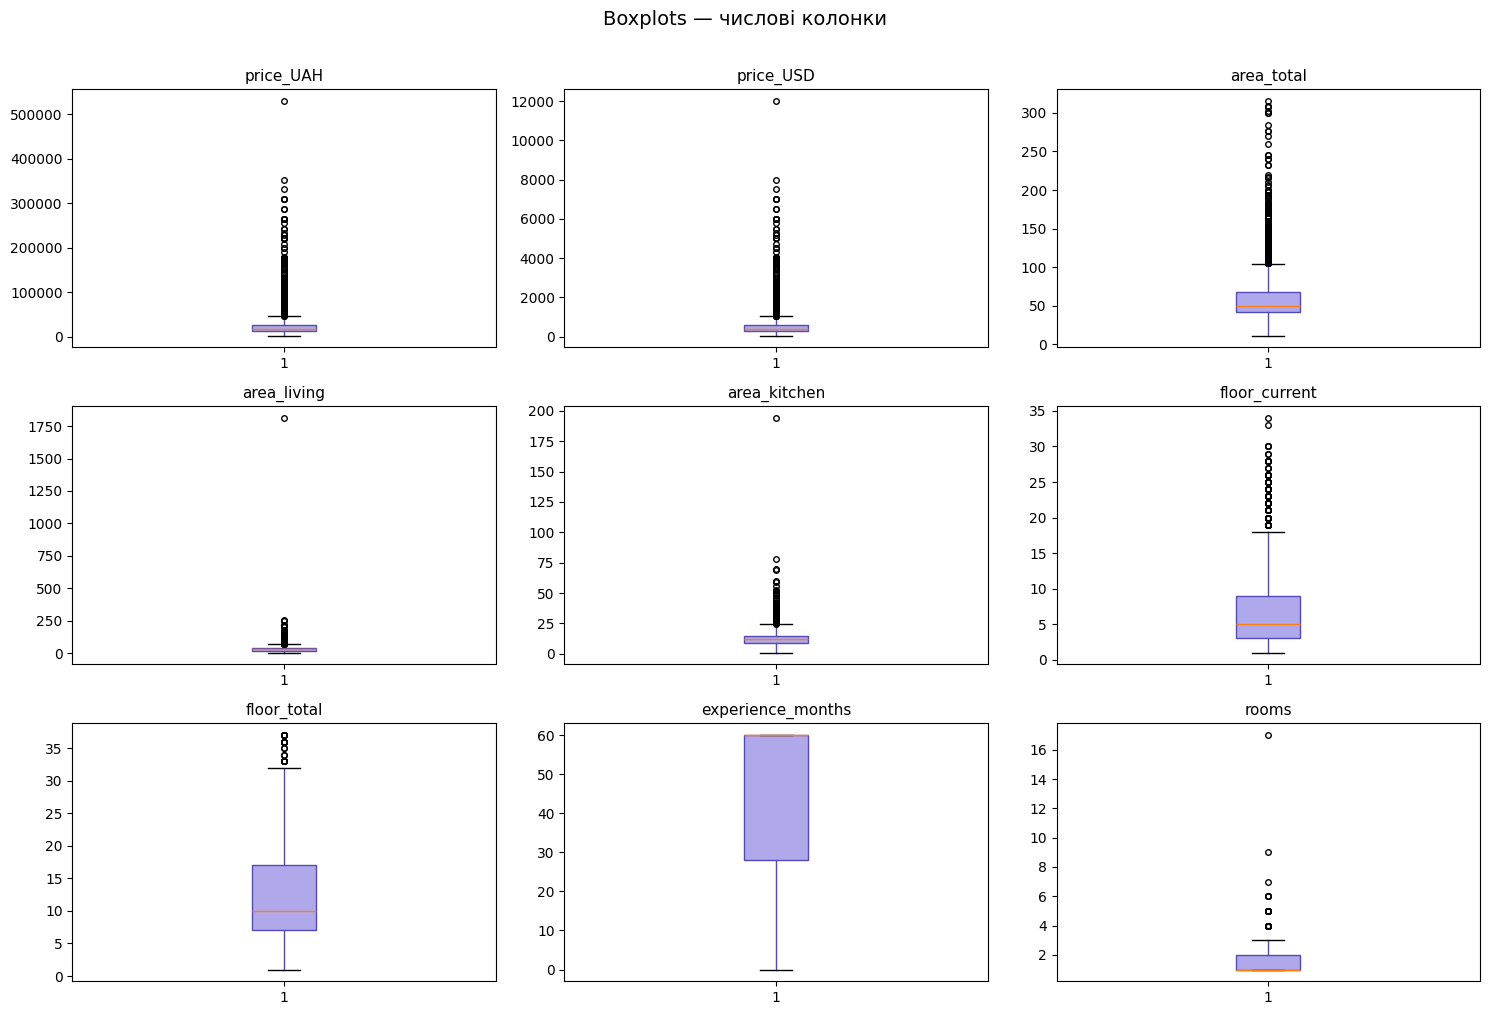

In [273]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(cl_df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#AFA9EC', color='#534AB7'),
                    whiskerprops=dict(color='#534AB7'),
                    flierprops=dict(marker='o', color='#D85A30', markersize=4))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')

plt.suptitle('Boxplots — числові колонки', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Спочатку перевіряємо нижній поріг цін. Так як таких оголошень не багато виконаємо наочну перевірку на достовірність (квартира на довгострокову оренду). За результатом вирішено залишити ці квартири - це дійсно об'єкти найнижчого цінового сегменту на ринку.

In [274]:
# Шукаємо підозріло дешеві об'єкти (менше 4000 грн)
suspicious_low = cl_df[cl_df['price_UAH'] < 4000]

# Виводимо їх, щоб оцінити очима
print(f"Знайдено підозріло дешевих: {len(suspicious_low)}")
suspicious_low[['id', 'price_UAH', 'rooms', 'area_total', 'url']].head(10)

Знайдено підозріло дешевих: 17


,id,price_UAH,rooms,area_total,url
1303,34077319,3500,1,24.0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-harkov-saltovskiy-yubileynyy-prospekt-34077319.html
1785,34062890,2500,1,30.0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-harkov-626-yy-mikrorayon-edinstva-krasnodarskaya-ulitsa-34062890.html
1911,34033167,3100,1,35.5,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-kamenskoe-dneprovskiy-naddnepryanskiy-50-let-sssr-prospekt-34033167.html
3087,34018397,3000,2,43.0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-krivoy-rog-inguletskiy-solnechnaya-ulitsa-34018397.html
4131,33964072,2700,1,19.0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-harkov-kievskiy-shevchenkovskiy-pereulok-33964072.html
4274,33953474,3999,1,20.0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-harkov-shevchenkovskiy-pereulok-33953474.html
4353,33944738,3000,1,18.0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-harkov-kievskiy-chernivetskaya-ulitsa-33944738.html
4571,33929343,3000,1,36.0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-harkov-saltovskiy-neskorenyh-geroev-truda-ulitsa-33929343.html
5439,33854001,3500,1,18.0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-harkov-slobodskoy-geroev-harkova-moskovskiy-prospekt-33854001.html
5444,33853735,3000,1,19.0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-harkov-shishkovka-jilyardi-ulitsa-33853735.html


Для перевірки достовірності ціни квартири створюємо стовпець ціни за квадратний метр. І наочно переглядаємо найдорожчі квартири за квадратний метр в пошуку неправдивих даних.

In [275]:
cl_df['price_per_sqm'] = cl_df['price_UAH'] / cl_df['area_total']

In [276]:
expensive_df = cl_df[cl_df['price_UAH'] > 60000]

print(expensive_df.sort_values(by='price_per_sqm', ascending=False)[
    ['id', 'price_UAH', 'area_total', 'rooms', 'price_per_sqm', 'url']
].head(15))

            id  price_UAH  area_total  rooms  price_per_sqm  \
4532  33930690     264720        51.6      1    5130.232558   
4365  33936983     255896        78.8      2    3247.411168   
4331  33945308     352960       123.6      3     2855.66343   
4415  33937954     123536        49.2      1    2510.894309   
1519  34067954     286780       123.6      3    2320.226537   
3703  33987955     330900       149.5      4    2213.377926   
4060  33963234     110300        51.6      1    2137.596899   
5732  33821239     286455       137.5      4    2083.309091   
6147  33771563     158652        79.3      2    2000.655738   
5091  33884625     264720       132.7      4    1994.875659   
4330  33945295     242660       124.1      3    1955.358582   
6188  33771841     123396        64.4      1    1916.086957   
2582  34030070     141184        74.0      2    1907.891892   
5370  33859530     114712        60.6      1    1892.937294   
3830  33979465     233836       124.1      3    1884.25

За результатами перевірки не було виявлено оголошень з хибними даними, такі квартири дійсно існують і складають преміум сегмет на ринку оренди житлової нерухомості Києва.

In [277]:
cl_df[cl_df['price_UAH'] > 200000].head()

,id,rooms,price_UAH,price_USD,date,city_name,district,metro,address,seller,experience_months,seller_level,area_total,area_living,area_kitchen,floor_current,floor_total,kitchen_studio,penthouse,multilevel,has_shelter,pets,no_light_internet,no_light_mobile_connection,no_light_water,no_light_heating,no_light_gas,no_light_elevator,url,has_metro,year_month,price_per_sqm
1126,34081972,4,529440,12000,2026-03-20,Київ,Печерськ,Арсенальна,вул. Івана Мазепи 11Б,Валерия Корбут,43,Професіонал,309.0,220.0,50.0,11,26,1,0,0,1,Можна з тваринами,1,0,1,1,0,1,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-kiev-pechersk-ivana-mazepy-yanvarskogo-vosstaniya-ulitsa-34081972.html,1,2026-03,1713.398058
1261,34078076,3,308840,7000,2026-03-19,Київ,Центр,Немає метро,вул. Олександра Кониського 46/11,Яна Юріївна Мірошніченко,32,Досвідчений,172.0,90.0,30.0,3,17,1,0,0,0,Не вказано,1,1,1,1,0,1,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-kiev-tsentr-aleksandra-konisskogo-turgenevskaya-ulitsa-34078076.html,0,2026-03,1795.581395
1519,34067954,3,286780,6500,2026-03-17,Київ,Чорна Гора,Немає метро,вул. Андрія Верхогляда 15А,Яна Юріївна Мірошніченко,32,Досвідчений,123.6,63.2,18.0,9,17,1,0,0,0,Не вказано,0,1,0,0,0,0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-kiev-chernaya-gora-andreya-verhoglyada-dragomirova-ulitsa-34067954.html,0,2026-03,2320.226537
2943,34024745,5,229424,5200,2026-03-04,Київ,Чорна Гора,Немає метро,вул. Андрія Верхогляда 15,Яна Юріївна Мірошніченко,32,Досвідчений,193.5,105.5,18.6,26,30,1,0,0,0,Не вказано,0,1,0,0,0,0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-kiev-chernaya-gora-andreya-verhoglyada-dragomirova-ulitsa-34024745.html,0,2026-03,1185.653747
3037,34020462,5,308840,7000,2026-03-03,Київ,Чорна Гора,Немає метро,вул. Андрія Верхогляда 15,Яна Юріївна Мірошніченко,32,Досвідчений,192.0,105.6,18.4,23,30,0,0,0,0,Не вказано,0,0,0,0,0,0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-kiev-chernaya-gora-andreya-verhoglyada-dragomirova-ulitsa-34020462.html,0,2026-03,1608.541667


Викиди у ціновому стовпчику є цілком реальними і будуть залишені для розуміння загальної картини. Проте в майбутньому при аналізі певних ознак краще розділяти ринок на два датасети (звичайне житло і преміум клас). 

Під час перевірки викидів на графіках помічено нелогічні викиди у площах і вирішено перевірити на логічність дані площ (площа кухні і житлова не може бути більше загальної площі). Видаляємо всі оголошення з неправильно вказаною площею.

In [278]:
print(f"Кількість оголошень до видалення аномалій площі: {len(cl_df)}")
print(f"Знайдено оголошень з неправильною житловою площею: {len(cl_df[cl_df['area_living'] > cl_df['area_total']])}")
print(f"Знайдено оголошень з неправильною площею кухні: {len(cl_df[cl_df['area_kitchen'] > cl_df['area_total']])}")

cl_df = cl_df[cl_df['area_living'] <= cl_df['area_total']]
cl_df = cl_df[cl_df['area_kitchen'] <= cl_df['area_total']]

print(f"Кількість оголошень після видалення аномалій площі: {len(cl_df)}")

Кількість оголошень до видалення аномалій площі: 5692
Знайдено оголошень з неправильною житловою площею: 22
Знайдено оголошень з неправильною площею кухні: 3
Кількість оголошень після видалення аномалій площі: 5668


Також перевірено загальну площу квартир. По нижній межі не було виявлено проблем. По верхній межі знайдено 23 оголошення, які на перший погляд здалися викидом. Проте після детальнішої перевірки було досягнуто висновку, що це просто квартири з великою кількістю кімнат або преміальні великі багатоярусні пентхауси. Тож такі квартири залишимо у датасеті, бо вони не є викидами, але при розрахунку цін і площ квартир у майбутньому необхідно використовувати `median` замість `mean` для точнішої оцінки.

In [279]:
outliers_b = cl_df[(cl_df['area_total'] < 15) | (cl_df['area_total'] > 200)]

print(f"Знайдено великих за площею квартир: {len(outliers_b)}")
print(outliers_b[['id', 'rooms', 'area_total', 'price_UAH', 'penthouse', 'multilevel']].head(10))

Знайдено великих за площею квартир: 23
            id  rooms  area_total  price_UAH  penthouse  multilevel
534   34091621      4       232.9      44500          0           0
1126  34081972      4       309.0     529440          0           0
1200  34076248      6       315.5     110300          0           0
2058  34034902      6       217.0      50000          0           1
2077  34053147      4       211.0     176480          0           0
3094  34015227      4       246.1     154420          0           0
3773  31889708      3       276.4     154420          1           1
3852  33982948      3       233.0      75004          0           0
4162  32963581      5       240.0      66180          1           0
4190  33938538      4       216.0     198540          1           1


Також виконаємо логічну перевірку для поверхів квартири

In [280]:
weird_bottom = cl_df[cl_df['floor_current'] < 1]
print(f"Квартир на 0 або мінусовому поверсі: {len(weird_bottom)}")

Квартир на 0 або мінусовому поверсі: 0


In [281]:
one_story = cl_df[cl_df['floor_total'] == 1]
print(f"Квартир в 1-поверхових будинках: {len(one_story)}")
one_story.head()

Квартир в 1-поверхових будинках: 20


,id,rooms,price_UAH,price_USD,date,city_name,district,metro,address,seller,experience_months,seller_level,area_total,area_living,area_kitchen,floor_current,floor_total,kitchen_studio,penthouse,multilevel,has_shelter,pets,no_light_internet,no_light_mobile_connection,no_light_water,no_light_heating,no_light_gas,no_light_elevator,url,has_metro,year_month,price_per_sqm
2191,34048994,1,10000,227,2026-03-11,Хмельницький,Невідомий район,Немає метро,вул. Трипільська 42,Анастасія Хмельницька,60,Експерт,38.0,18.0,11.9,1,1,0,0,0,0,Не вказано,0,1,1,1,1,0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-hmelnitskiy-tripolskaya-schedrina-ulitsa-34048994.html,0,2026-03,263.157895
2196,34048495,1,9500,215,2026-03-11,Вінниця,П'ятничани,Немає метро,вул. Івана Богуна 97,Алі Адалят Громов,60,Експерт,35.0,19.0,8.0,1,1,1,0,0,0,Не вказано,0,0,0,0,0,0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-vinnitsa-pyatnichany-ivana-boguna-ulitsa-34048495.html,0,2026-03,271.428571
3306,34001298,2,20000,453,2026-02-27,Хмельницький,Дубове,Немає метро,вул. Симона Петлюри 15/1,Ирина,60,Експерт,80.0,34.2,15.0,1,1,0,0,0,0,Без тварин,0,0,0,0,0,0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-hmelnitskiy-dubovo-simona-petlyury-kuprina-ulitsa-34001298.html,0,2026-02,250.0
4024,33969062,3,10000,227,2026-02-16,Хмельницький,Ракове,Немає метро,"вул. Чорновола В’ячеслава 129, кв. 1",Тетяна Петрівна,60,Експерт,53.0,40.0,6.5,1,1,0,0,0,0,Не вказано,0,0,0,0,0,0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-hmelnitskiy-rakovo-chernovola-vyacheslava-ulitsa-33969062.html,0,2026-02,188.679245
4879,33904604,2,12000,272,2026-01-23,Одеса,Молдаванка,Немає метро,вул. М’ясоїдівська 34,Ирина,60,Експерт,50.0,34.2,12.0,1,1,0,0,0,0,Без тварин,0,0,0,0,0,0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-odessa-moldavanka-myasoedovskaya-ulitsa-33904604.html,0,2026-01,240.0


Виявлено 20 квартир в одноповерхових будинках, після перевірки було вирішено видалити їх з датасету, оскільки тут маємо дослідження саме квартир, а не будинків чи комуналок - вони мають свій ринок і окреме ціноутворення.

In [282]:
# Відсікаємо одноповерхові "квартири"
cl_df = cl_df[cl_df['floor_total'] > 1]

print(f"Фінальна кількість чистих квартир: {len(cl_df)}")

Фінальна кількість чистих квартир: 5648


In [283]:
print(f"Кількість оголошень до видалення аномалій поверху: {len(cl_df)}")
print(f"Знайдено оголошень з неправильним поверхом: {len(cl_df[cl_df['floor_current'] > cl_df['floor_total']])}")

cl_df = cl_df[cl_df['floor_current'] <= cl_df['floor_total']]

print(f"Кількість оголошень після видалення аномалій поверху: {len(cl_df)}")

Кількість оголошень до видалення аномалій поверху: 5648
Знайдено оголошень з неправильним поверхом: 0
Кількість оголошень після видалення аномалій поверху: 5648


Перевіряємо викиди по кількості кімнат. Порівнюємо ціну до кількості кімнат і обрізаємо датасет ,залишаючи максимум 7 кімнатні квартири, які можуть справді існувати за таку ціну.

In [284]:
print("Оголошення з 5+ кімнатами:")
cl_df[(cl_df['rooms'] > 6)]

Оголошення з 5+ кімнатами:


,id,rooms,price_UAH,price_USD,date,city_name,district,metro,address,seller,experience_months,seller_level,area_total,area_living,area_kitchen,floor_current,floor_total,kitchen_studio,penthouse,multilevel,has_shelter,pets,no_light_internet,no_light_mobile_connection,no_light_water,no_light_heating,no_light_gas,no_light_elevator,url,has_metro,year_month,price_per_sqm
1546,34071282,17,4500,102,2026-03-17,Харків,Невідомий район,Немає метро,вул. Нескорених 36,Ирина,6,Новачок,33.0,30.0,12.0,7,9,0,0,0,0,Не вказано,0,1,1,1,1,0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-harkov-neskorenyh-geroev-truda-ulitsa-34071282.html,0,2026-03,136.363636
5507,33847958,7,132360,3000,2025-12-29,Львів,Личаків,Немає метро,"вул. Верхратського 15, кв. 5",Анна Христюк,20,Досвідчений,302.0,157.7,14.7,3,3,0,0,0,0,Не вказано,0,0,0,0,0,0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-lvov-lychakov-verhratskogo-ulitsa-33847958.html,0,2025-12,438.278146
5616,33837750,9,70512,1600,2025-12-24,Київ,Солдатська Слобідка,Немає метро,вул. Олександра Кониського 52-58,Оксана Вікторівна Негода,60,Експерт,276.5,212.3,13.2,8,10,0,0,0,1,Не вказано,0,0,0,0,0,0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-kiev-soldatskaya-slobodka-aleksandra-konisskogo-turgenevskaya-ulitsa-33837750.html,0,2025-12,255.016275


In [285]:
cl_df = cl_df[(cl_df['rooms'] >= 1) & (cl_df['rooms'] <= 7)]

print(f"Кількість оголошень після видалення аномалій по кімнатам: {len(cl_df)}")

Кількість оголошень після видалення аномалій по кімнатам: 5646


Тепер ще раз поглянемо на графік після першої очистки за ним:

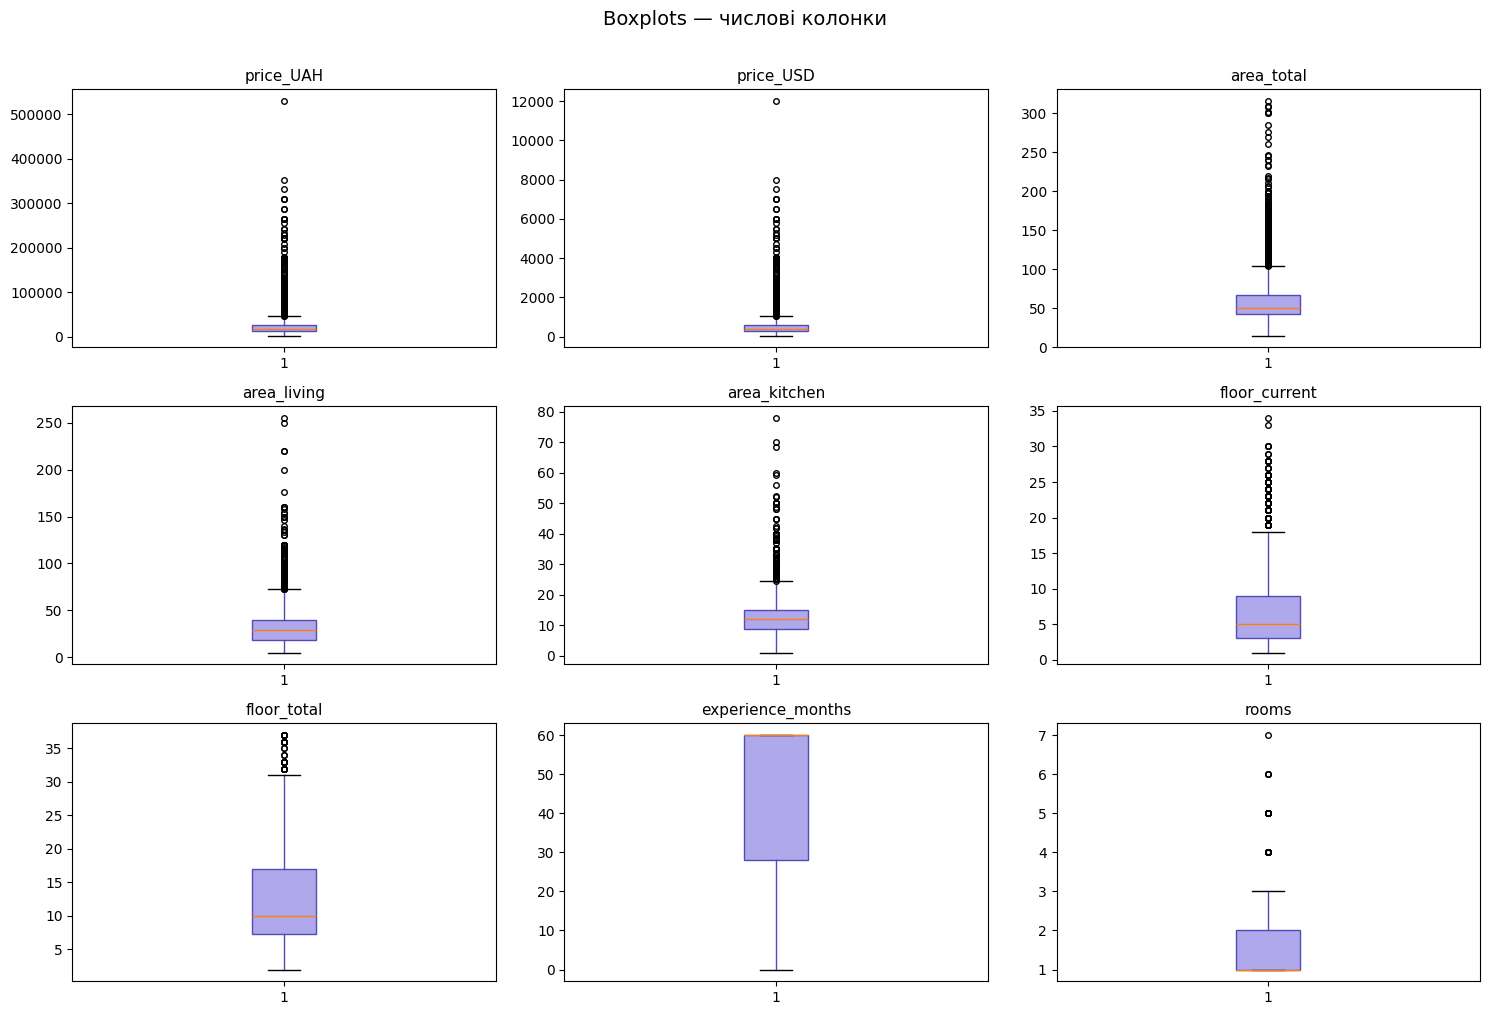

In [286]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(cl_df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#AFA9EC', color='#534AB7'),
                    whiskerprops=dict(color='#534AB7'),
                    flierprops=dict(marker='o', color='#D85A30', markersize=4))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')

plt.suptitle('Boxplots — числові колонки', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

В результаті маємо готові дані для аналізу і побудови гіпотез, в залежності від напрямку аналізу будемо розділяти дані квартир на 2 датасети (звичайні vs преміум).

#### Перевірка бінарних (лише коректність)

Для впевненості у бінарних колонках перевіримо значення цих колонок.

In [287]:
print("=== Перевірка бінарних колонок (допустимі значення: 0 або 1) ===")
for col in binary_cols:
    unique_vals = cl_df[col].unique()
    bad = [v for v in unique_vals if v not in [0, 1]]
    if bad:
        print(f"  ⚠️  {col}: знайдено дивні значення → {bad}")
    else:
        print(f"  ✅ {col}: OK ({cl_df[col].value_counts().to_dict()})")

=== Перевірка бінарних колонок (допустимі значення: 0 або 1) ===
  ✅ kitchen_studio: OK ({0: 4085, 1: 1561})
  ✅ penthouse: OK ({0: 5615, 1: 31})
  ✅ multilevel: OK ({0: 5572, 1: 74})
  ✅ has_shelter: OK ({0: 4167, 1: 1479})
  ✅ no_light_internet: OK ({0: 3664, 1: 1982})
  ✅ no_light_mobile_connection: OK ({0: 3399, 1: 2247})
  ✅ no_light_water: OK ({0: 2890, 1: 2756})
  ✅ no_light_heating: OK ({0: 3532, 1: 2114})
  ✅ no_light_gas: OK ({0: 4038, 1: 1608})
  ✅ no_light_elevator: OK ({0: 4441, 1: 1205})
  ✅ has_metro: OK ({0: 4026, 1: 1620})


#### Перевірка категоріальних

In [288]:
print("=== Рідкісні категорії (< 1% = підозрілі) ===")
for col in categorical_cols:
    counts = cl_df[col].value_counts(normalize=True) * 100
    rare = counts[counts < 1.0]
    print(f"\n{col}:")
    print(counts.round(2).to_string())
    if not rare.empty:
        print(f"  ⚠️  Рідкісні значення: {rare.index.tolist()}")

=== Рідкісні категорії (< 1% = підозрілі) ===

seller_level:
seller_level
Експерт        52.36
Досвідчений    19.16
Новачок        14.59
Професіонал    13.89

pets:
pets
Не вказано           52.07
Без тварин           29.61
Можна з тваринами    18.31

city_name:
city_name
Київ                          35.72
Вінниця                       10.82
Одеса                         10.57
Дніпро                         9.14
Львів                          5.60
Хмельницький                   4.78
Тернопіль                      4.20
Рівне                          3.37
Івано-Франківськ               2.39
Харків                         1.68
Миколаїв                       1.19
Ірпінь                         1.12
Софіївська Борщагівка          1.04
Луцьк                          0.81
Чернівці                       0.74
Біла Церква                    0.62
Полтава                        0.55
Ужгород                        0.46
Лиманка                        0.44
Кривий Ріг                     0.37
Житомир

В категоріальних даних нічого не видаляємо, просто ознайомилися з існуючими категоріями.

In [289]:
cl_df.info()

<class 'pandas.DataFrame'>
Index: 5646 entries, 222 to 6208
Data columns (total 32 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   id                          5646 non-null   str           
 1   rooms                       5646 non-null   Int64         
 2   price_UAH                   5646 non-null   Int64         
 3   price_USD                   5646 non-null   Int64         
 4   date                        5646 non-null   datetime64[us]
 5   city_name                   5646 non-null   str           
 6   district                    5646 non-null   str           
 7   metro                       5646 non-null   str           
 8   address                     5646 non-null   str           
 9   seller                      5646 non-null   str           
 10  experience_months           5646 non-null   int64         
 11  seller_level                5646 non-null   str           
 12  area_t

Також не було проаналізованого стовпчики `id`, `date`, `address`, `url`, `seller`, `metro` так як вони використовуються для позначення унікальності оголошення або інших не аналізуючих в цьому випадку особливостей.

### 3. Аналіз

C:\Users\Acer\AppData\Local\Temp\ipykernel_20520\1319112852.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(


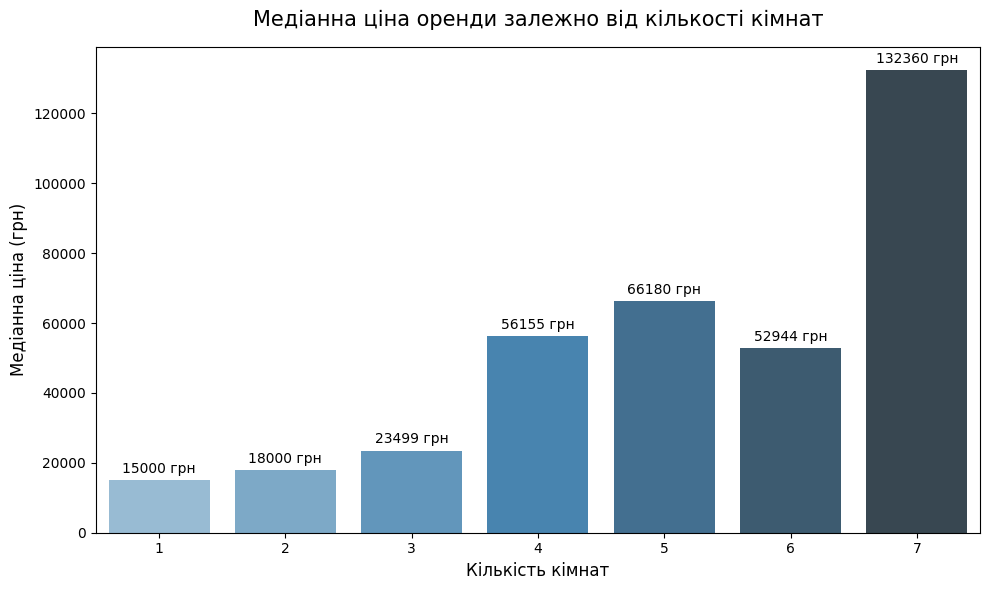

C:\Users\Acer\AppData\Local\Temp\ipykernel_20520\1319112852.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(


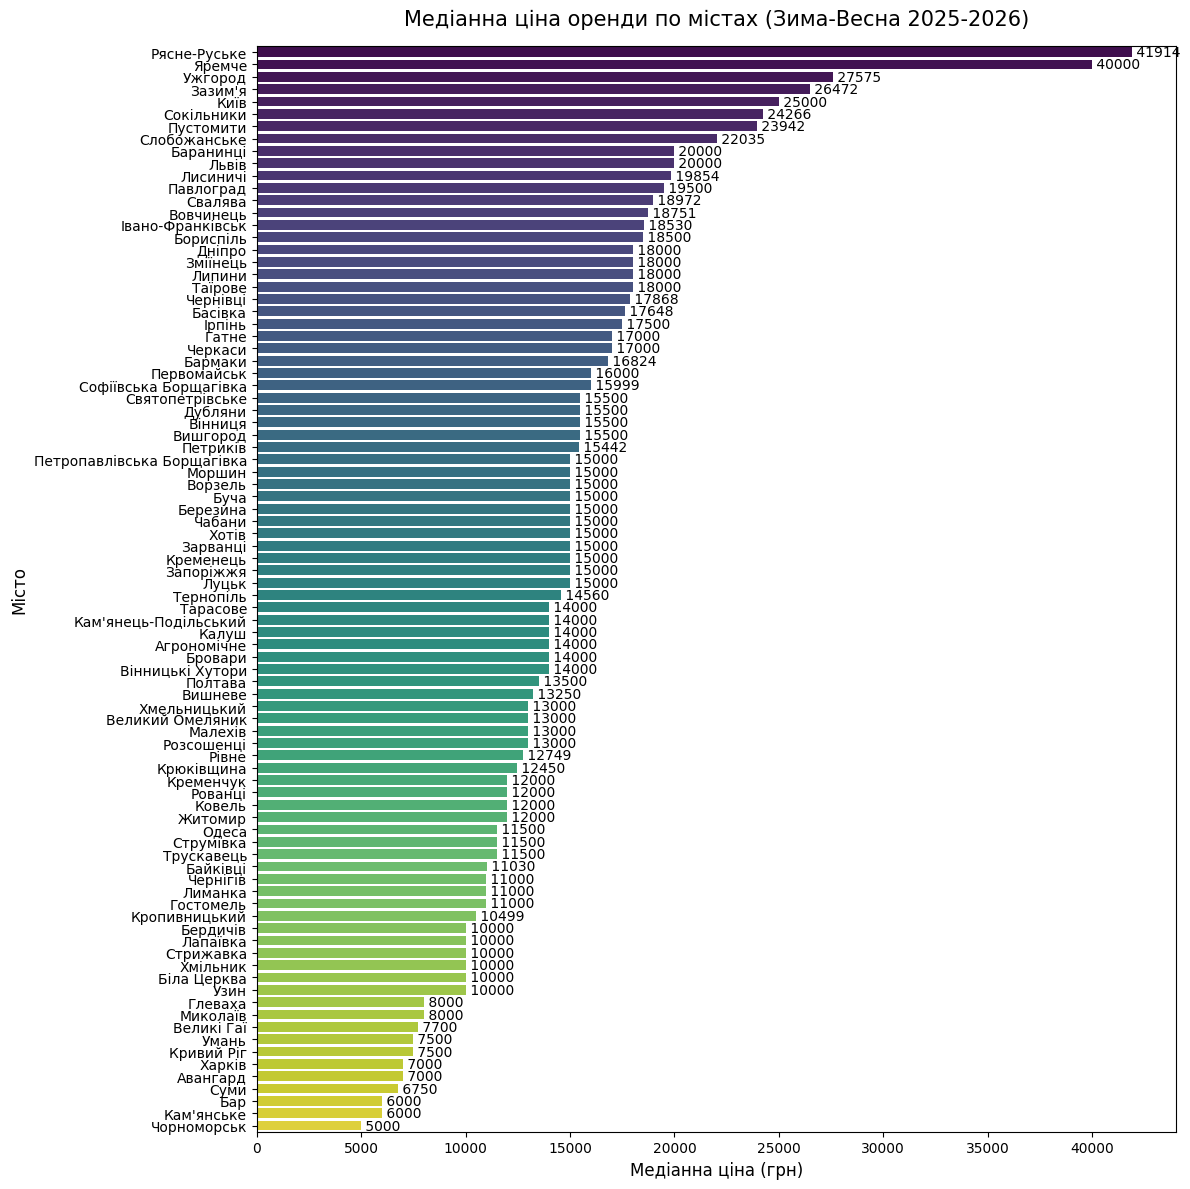

In [290]:
# ==========================================
# ГРАФІК 1: Ціна відносно кількості кімнат
# ==========================================
plt.figure(figsize=(10, 6))

# Будуємо вертикальний графік
ax1 = sns.barplot(
    data=cl_df, 
    x='rooms', 
    y='price_UAH', 
    estimator=np.median, # Рахуємо медіану
    errorbar=None,       # Прибираємо "вусики"
    palette='Blues_d'    # Градієнт синього
)

plt.title('Медіанна ціна оренди залежно від кількості кімнат', fontsize=15, pad=15)
plt.xlabel('Кількість кімнат', fontsize=12)
plt.ylabel('Медіанна ціна (грн)', fontsize=12)

# Додаємо точні цифри над кожним стовпчиком
for container in ax1.containers:
    ax1.bar_label(container, fmt='%d грн', padding=3)

plt.tight_layout()
plt.show()


# ==========================================
# ГРАФІК 2: Ціна по містах України
# ==========================================
# Робимо графік високим (12 дюймів), бо міст багато і їм треба місце
plt.figure(figsize=(12, 12)) 

# Сортуємо міста за медіанною ціною (від найдорожчого до найдешевшого)
city_order = cl_df.groupby('city_name')['price_UAH'].median().sort_values(ascending=False).index

# Будуємо горизонтальний графік
ax2 = sns.barplot(
    data=cl_df, 
    y='city_name', 
    x='price_UAH', 
    estimator=np.median,
    errorbar=None,
    order=city_order,
    palette='viridis' # Яскрава палітра від жовтого до фіолетового
)

plt.title('Медіанна ціна оренди по містах (Зима-Весна 2025-2026)', fontsize=15, pad=15)
plt.xlabel('Медіанна ціна (грн)', fontsize=12)
plt.ylabel('Місто', fontsize=12)

# Додаємо точні цифри поруч із кожним стовпчиком
for p in ax2.patches:
    # Оскільки графік горизонтальний, ми беремо width (ширину), а не height (висоту)
    ax2.annotate(f" {int(p.get_width())}", 
                 (p.get_width(), p.get_y() + p.get_height() / 2.), 
                 ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [291]:
cl_df.head(3)

,id,rooms,price_UAH,price_USD,date,city_name,district,metro,address,seller,experience_months,seller_level,area_total,area_living,area_kitchen,floor_current,floor_total,kitchen_studio,penthouse,multilevel,has_shelter,pets,no_light_internet,no_light_mobile_connection,no_light_water,no_light_heating,no_light_gas,no_light_elevator,url,has_metro,year_month,price_per_sqm
222,33956641,1,15000,340,2026-03-27,Київ,Харківський Масив,Вирлиця,вул. Кам’янська 6,Олена Гранд,18,Досвідчений,30.0,18.0,6.0,25,25,0,0,0,1,Не вказано,0,0,1,0,0,1,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-kiev-harkovskiy-massiv-kamenskaya-ulitsa-33956641.html,1,2026-03,500.0
212,33463352,1,9000,204,2026-03-27,Хмельницький,Ракове,Немає метро,"вул. Чорновола В’ячеслава 176/1, кв. 143",Юрій Анатолійович Яремчук,60,Експерт,55.7,17.4,11.3,1,4,0,0,0,0,Без тварин,0,0,0,0,0,0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-hmelnitskiy-rakovo-chernovola-vyacheslava-ulitsa-33463352.html,0,2026-03,161.579892
214,33671390,1,30884,700,2026-03-27,Одеса,Аркадія,Немає метро,пров. Курортний 2,Олександр,28,Досвідчений,45.0,18.0,11.9,18,25,1,0,0,1,Без тварин,0,0,1,1,0,1,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-odessa-arkadiya-kurortnyy-pereulok-33671390.html,0,2026-03,686.311111


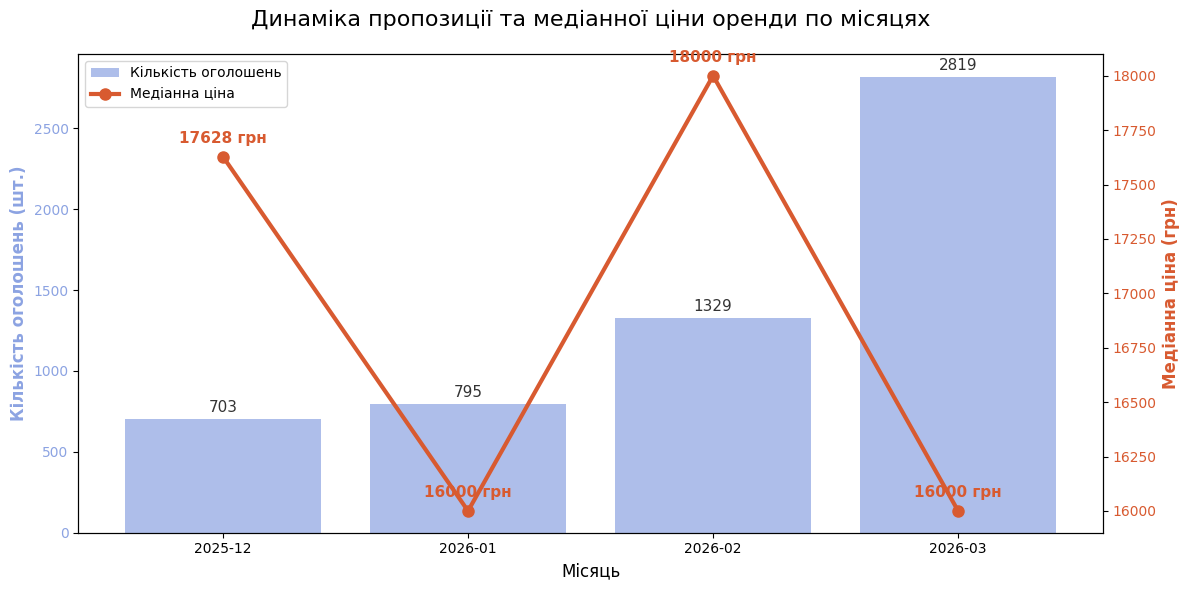


Детальна статистика по місяцях:
 Місяць  К-сть квартир  Медіанна ціна (грн)
2025-12            703              17628.0
2026-01            795              16000.0
2026-02           1329              18000.0
2026-03           2819              16000.0


In [292]:

# 1. Підготовка даних
# Групуємо дані по місяцях і рахуємо одночасно два показники: 'count' (кількість) і 'median' (медіана)
monthly_stats = cl_df.groupby('year_month')['price_UAH'].agg(['count', 'median']).reset_index()

# Перетворюємо місяці у звичайний текст (бо matplotlib іноді свариться на спеціальний формат period[M])
monthly_stats['year_month'] = monthly_stats['year_month'].astype(str)

# 2. Будуємо графік
fig, ax1 = plt.subplots(figsize=(12, 6))

# --- ПЕРША ВІСЬ (Стовпчики: Кількість оголошень) ---
color_count = '#8CA3E2' # М'який синій колір
ax1.bar(monthly_stats['year_month'], monthly_stats['count'], color=color_count, alpha=0.7, label='Кількість оголошень')

ax1.set_xlabel('Місяць', fontsize=12)
ax1.set_ylabel('Кількість оголошень (шт.)', color=color_count, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_count)

# Додаємо цифри кількості прямо на стовпчики (використовуємо наш новий улюблений метод)
ax1.bar_label(ax1.containers[0], padding=3, color='#333333', fontsize=11)


# --- ДРУГА ВІСЬ (Лінія: Медіанна ціна) ---
# МАГІЯ ТУТ: ax1.twinx() створює другу вісь Y, яка ділить ту саму вісь X (місяці)
ax2 = ax1.twinx() 
color_price = '#D85A30' # Контрастний помаранчевий/червоний колір

# Малюємо лінію цін поверх стовпчиків
ax2.plot(monthly_stats['year_month'], monthly_stats['median'], color=color_price, 
         marker='o', linewidth=3, markersize=8, label='Медіанна ціна')

ax2.set_ylabel('Медіанна ціна (грн)', color=color_price, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_price)

# Додаємо точні цифри цін над точками лінії
for i, price in enumerate(monthly_stats['median']):
    ax2.annotate(f"{int(price)} грн", 
                 (i, price), 
                 textcoords="offset points", 
                 xytext=(0, 10), # Трохи піднімаємо текст над точкою
                 ha='center', fontsize=11, color=color_price, fontweight='bold')


# --- КОСМЕТИКА ---
plt.title('Динаміка пропозиції та медіанної ціни оренди по місяцях', fontsize=16, pad=20)

# Збираємо легенду з обох осей до купи, щоб було красиво
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

# Вимикаємо сітку на другій осі, щоб лінії не перетиналися і не робили "кашу"
ax2.grid(False)

plt.tight_layout()
plt.show()

# Виводимо табличку для підтвердження
print("\nДетальна статистика по місяцях:")
print(monthly_stats.rename(columns={'year_month': 'Місяць', 'count': 'К-сть квартир', 'median': 'Медіанна ціна (грн)'}).to_string(index=False))

C:\Users\Acer\AppData\Local\Temp\ipykernel_20520\2003703107.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(
C:\Users\Acer\AppData\Local\Temp\ipykernel_20520\2003703107.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['Ні', 'Так', 'Не вказано'])


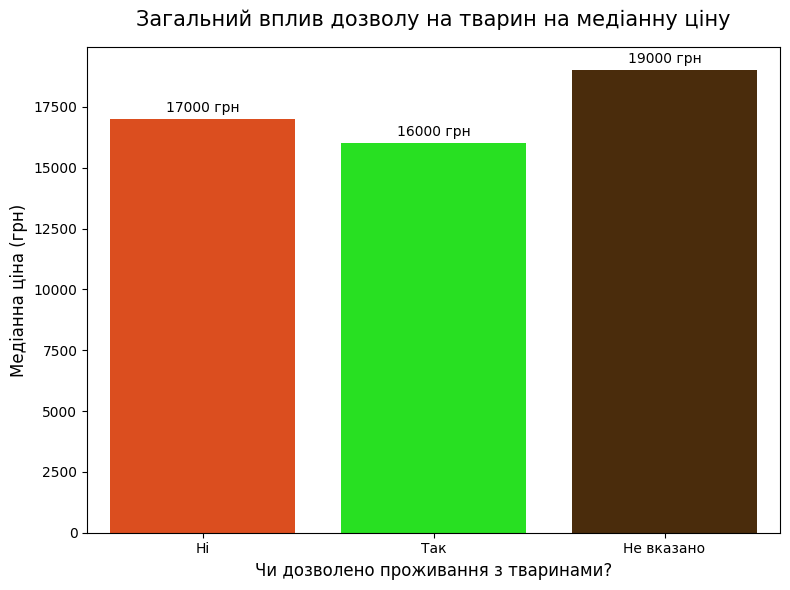

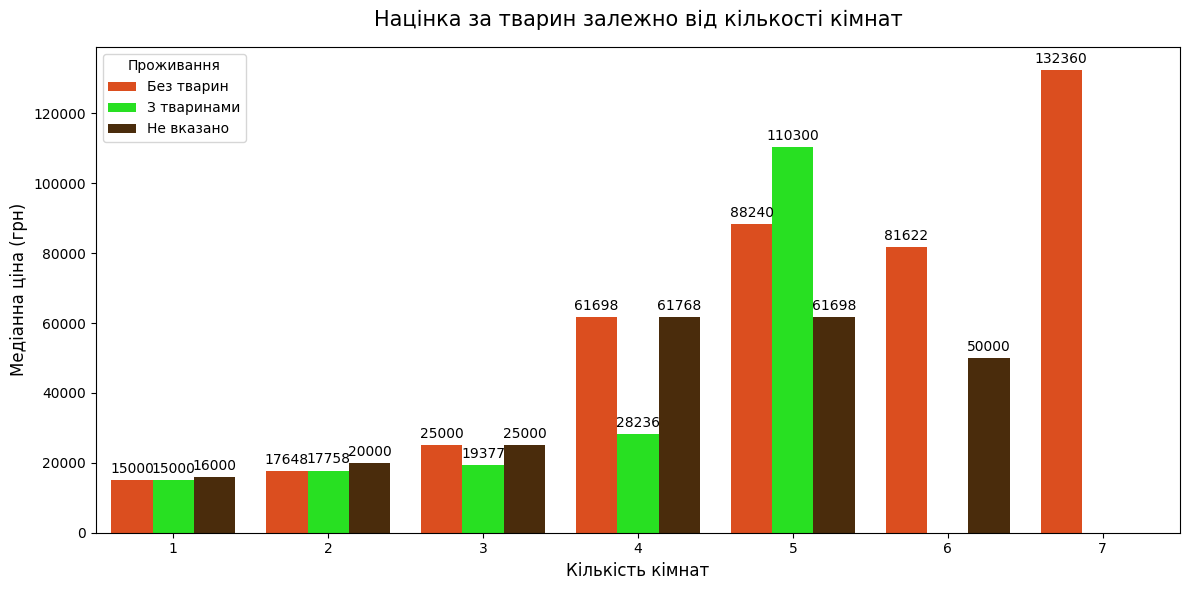


Точні цифри медіанної ціни (грн) по кімнатах та тваринах:
pets   Без тварин  Можна з тваринами  Не вказано
rooms                                           
1         15000.0            16000.0     15000.0
2         17758.0            20000.0     17648.0
3         19377.0            25000.0     25000.0
4         28236.0            61768.0     61698.0
5        110300.0            61698.0     88240.0
6            <NA>            50000.0     81622.0
7            <NA>               <NA>    132360.0


In [293]:
# Заміни 'pets_allowed' на точну назву твоєї колонки з тваринами!
pet_col = 'pets' 

# ==========================================
# ГРАФІК 1: Загальний вплив тварин на ціну
# ==========================================
plt.figure(figsize=(8, 6))
ax1 = sns.barplot(
    data=cl_df, 
    x=pet_col, 
    y='price_UAH', 
    estimator=np.median, 
    errorbar=None,
    palette=["#FA3E00", "#0BFF03", "#552C01A9"] # Червоний (Ні) і Синій (Так)
)

plt.title('Загальний вплив дозволу на тварин на медіанну ціну', fontsize=15, pad=15)
plt.xlabel('Чи дозволено проживання з тваринами?', fontsize=12)
plt.ylabel('Медіанна ціна (грн)', fontsize=12)

# Якщо в тебе значення 0 і 1, підпишемо їх по-людськи:
ax1.set_xticklabels(['Ні', 'Так', 'Не вказано'])

# Автоматично підписуємо стовпчики
for container in ax1.containers:
    ax1.bar_label(container, fmt='%d грн', padding=3)

# ax1.bar_label(ax1.containers[0], fmt='%d грн', padding=3, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


# ==========================================
# ГРАФІК 2: Націнка за тварин по кімнатах
# ==========================================
plt.figure(figsize=(12, 6))

ax2 = sns.barplot(
    data=cl_df, 
    x='rooms', 
    y='price_UAH', 
    hue=pet_col,          # Розбиваємо кожен стовпчик кімнат на два (з тваринами і без)
    estimator=np.median, 
    errorbar=None,
    palette=["#FA3E00", "#0BFF03", "#552C01A9"]
)

plt.title('Націнка за тварин залежно від кількості кімнат', fontsize=15, pad=15)
plt.xlabel('Кількість кімнат', fontsize=12)
plt.ylabel('Медіанна ціна (грн)', fontsize=12)

# Налаштовуємо легенду
handles, labels = ax2.get_legend_handles_labels()
plt.legend(handles=handles, labels=['Без тварин', 'З тваринами', 'Не вказано'], title='Проживання', loc='upper left')

# Оскільки в нас є hue (дві групи стовпчиків), використовуємо цикл по контейнерах, 
# про який ми говорили раніше, щоб підписати їх усі!
for container in ax2.containers:
    ax2.bar_label(container, fmt='%d', padding=3, fontsize=10)

plt.tight_layout()
plt.show()

# Текстова статистика для підтвердження
print("\nТочні цифри медіанної ціни (грн) по кімнатах та тваринах:")
print(cl_df.pivot_table(values='price_UAH', index='rooms', columns=pet_col, aggfunc='median').round(0))

#### Аналіз впливу географічного положення на ціну

In [294]:
cl_df['city_name'].value_counts()

city_name
Київ                          2017
Вінниця                        611
Одеса                          597
Дніпро                         516
Львів                          316
Хмельницький                   270
Тернопіль                      237
Рівне                          190
Івано-Франківськ               135
Харків                          95
Миколаїв                        67
Ірпінь                          63
Софіївська Борщагівка           59
Луцьк                           46
Чернівці                        42
Біла Церква                     35
Полтава                         31
Ужгород                         26
Лиманка                         25
Кривий Ріг                      21
Житомир                         18
Вишневе                         16
Сокільники                      12
Слобожанське                    11
Чабани                          11
Авангард                        10
Гатне                            9
Бровари                          9
Вінницькі 

In [295]:
df_kyiv = cl_df[cl_df['city_name'] == 'Київ']
print(len(df_kyiv))

2017


In [296]:
df_odesa = cl_df[cl_df['city_name'] == 'Одеса']
print(len(df_odesa))

597


In [297]:
df_lviv = cl_df[cl_df['city_name'] == 'Львів']
print(len(df_lviv))

316


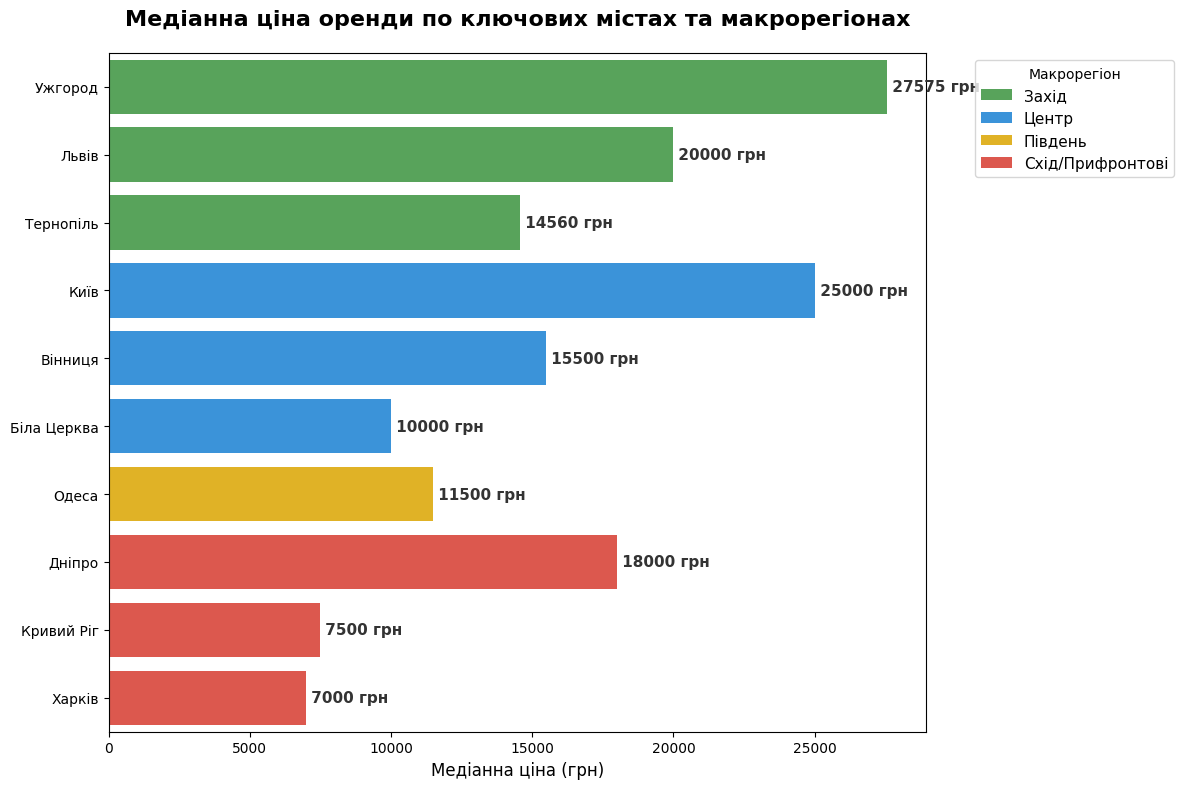


Зведена таблиця медіанних цін по містах:
    macro_region   city_name  price_UAH
           Захід     Ужгород    27575.0
           Захід       Львів    20000.0
           Захід   Тернопіль    14560.0
           Центр        Київ    25000.0
           Центр     Вінниця    15500.0
           Центр Біла Церква    10000.0
         Південь       Одеса    11500.0
Схід/Прифронтові      Дніпро    18000.0
Схід/Прифронтові  Кривий Ріг     7500.0
Схід/Прифронтові      Харків     7000.0


In [298]:
# 1. Створюємо словник груп міст
city_groups = {
    'Львів': 'Захід', 
    'Ужгород': 'Захід', 
    'Тернопіль': 'Захід',
    
    'Київ': 'Центр', 
    'Вінниця': 'Центр', 
    'Біла Церква': 'Центр',
    
    'Одеса': 'Південь',
    
    'Харків': 'Схід/Прифронтові', 
    'Дніпро': 'Схід/Прифронтові', 
    'Кривий Ріг': 'Схід/Прифронтові'
}

# 2. Фільтруємо датасет: залишаємо тільки ті міста, які є в нашому словнику
df_regions = cl_df[cl_df['city_name'].isin(city_groups.keys())].copy()

# Додаємо нову колонку 'macro_region' на основі нашого словника
df_regions['macro_region'] = df_regions['city_name'].map(city_groups)

# 3. Визначаємо правильний порядок для графіка
# Рахуємо медіани, щоб відсортувати міста всередині регіонів
median_prices = df_regions.groupby(['macro_region', 'city_name'])['price_UAH'].median().reset_index()

# Задаємо жорсткий порядок регіонів (від безпечного Заходу до прифронтового Сходу)
region_order = ['Захід', 'Центр', 'Південь', 'Схід/Прифронтові']
median_prices['macro_region'] = pd.Categorical(median_prices['macro_region'], categories=region_order, ordered=True)

# Сортуємо: спочатку за регіоном, потім за ціною за спаданням
sorted_cities = median_prices.sort_values(['macro_region', 'price_UAH'], ascending=[True, False])['city_name'].tolist()


# 4. Будуємо графік
plt.figure(figsize=(12, 8))

# Використовуємо кастомну палітру для регіонів, щоб вони чітко відрізнялися
region_colors = {
    'Захід': '#4CAF50',              # Зелений
    'Центр': '#2196F3',              # Синій
    'Південь': '#FFC107',            # Жовтий
    'Схід/Прифронтові': '#F44336'    # Червоний
}

ax = sns.barplot(
    data=df_regions,
    y='city_name',
    x='price_UAH',
    hue='macro_region',
    estimator=np.median,
    errorbar=None,
    order=sorted_cities,            # Наш відсортований список міст
    hue_order=region_order,         # Порядок регіонів у легенді
    dodge=False,                    # Щоб стовпчики були товстими і не роз'їжджалися
    palette=region_colors
)

# Косметика
plt.title('Медіанна ціна оренди по ключових містах та макрорегіонах', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Медіанна ціна (грн)', fontsize=12)
plt.ylabel('', fontsize=12) # Прибираємо слово "city_name", і так зрозуміло

# Легенда
plt.legend(title='Макрорегіон', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)

# Додаємо цифри на стовпчики (з перевіркою, щоб не підписувати порожні місця)
for p in ax.patches:
    width = p.get_width()
    if width > 0: # Якщо стовпчик існує
        ax.annotate(f" {int(width)} грн", 
                    (width, p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', fontsize=11, fontweight='bold', color='#333333')

plt.tight_layout()
plt.show()

# Текстовий вивід для перевірки
print("\nЗведена таблиця медіанних цін по містах:")
print(median_prices.sort_values(['macro_region', 'price_UAH'], ascending=[True, False]).to_string(index=False))

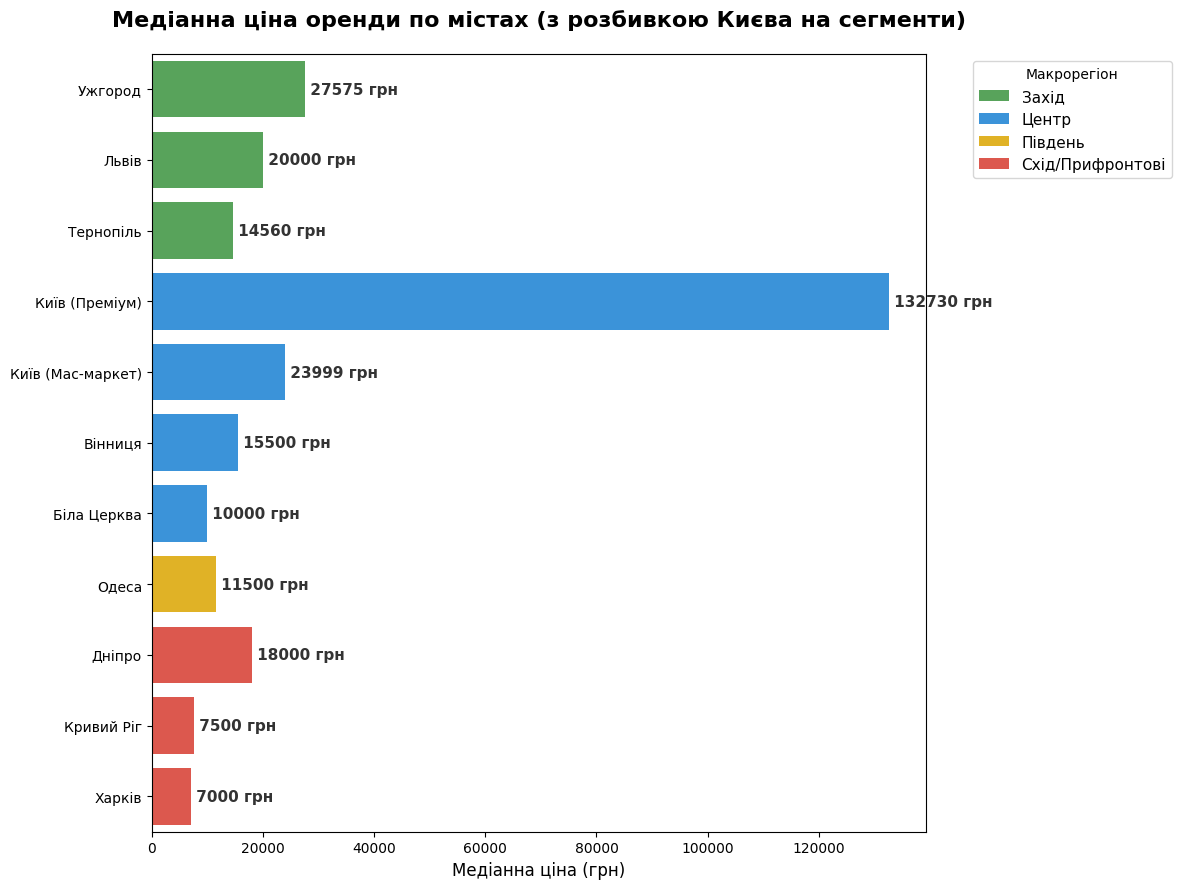


Медіанні ціни (з урахуванням розділення Києва):
    macro_region        city_split  price_UAH
           Захід           Ужгород    27575.0
           Захід             Львів    20000.0
           Захід         Тернопіль    14560.0
           Центр    Київ (Преміум)   132730.0
           Центр Київ (Мас-маркет)    23999.0
           Центр           Вінниця    15500.0
           Центр       Біла Церква    10000.0
         Південь             Одеса    11500.0
Схід/Прифронтові            Дніпро    18000.0
Схід/Прифронтові        Кривий Ріг     7500.0
Схід/Прифронтові            Харків     7000.0


In [299]:
# 1. Робимо копію датасету, щоб не зіпсувати оригінал
df_plot = cl_df.copy()

# Створюємо нову колонку для відображення міст
df_plot['city_split'] = df_plot['city_name']

# 2. РОЗДІЛЯЄМО КИЇВ НА ДВА СЕГМЕНТИ
# Поріг преміуму ставимо на 70 000 грн (можеш змінити на 50 000 або 100 000 за бажанням)
premium_threshold = 100000

# Мас-маркет
df_plot.loc[(df_plot['city_name'] == 'Київ') & (df_plot['price_UAH'] <= premium_threshold), 'city_split'] = 'Київ (Мас-маркет)'
# Преміум
df_plot.loc[(df_plot['city_name'] == 'Київ') & (df_plot['price_UAH'] > premium_threshold), 'city_split'] = 'Київ (Преміум)'

# 3. Оновлений словник груп міст (Київ тепер у двох варіантах)
city_groups = {
    'Львів': 'Захід', 
    'Ужгород': 'Захід', 
    'Тернопіль': 'Захід',
    
    'Київ (Преміум)': 'Центр', 
    'Київ (Мас-маркет)': 'Центр', 
    'Вінниця': 'Центр', 
    'Біла Церква': 'Центр',
    
    'Одеса': 'Південь',
    
    'Харків': 'Схід/Прифронтові', 
    'Дніпро': 'Схід/Прифронтові', 
    'Кривий Ріг': 'Схід/Прифронтові'
}

# 4. Фільтруємо і додаємо регіони
df_regions = df_plot[df_plot['city_split'].isin(city_groups.keys())].copy()
df_regions['macro_region'] = df_regions['city_split'].map(city_groups)

# 5. Рахуємо медіани і сортуємо
median_prices = df_regions.groupby(['macro_region', 'city_split'])['price_UAH'].median().reset_index()

region_order = ['Захід', 'Центр', 'Південь', 'Схід/Прифронтові']
median_prices['macro_region'] = pd.Categorical(median_prices['macro_region'], categories=region_order, ordered=True)

# Сортуємо: спочатку за регіоном, потім за ціною за спаданням
sorted_cities = median_prices.sort_values(['macro_region', 'price_UAH'], ascending=[True, False])['city_split'].tolist()

# 6. Будуємо графік
plt.figure(figsize=(12, 9)) # Зробив трохи вищим, бо додалося ще одне "місто"

region_colors = {
    'Захід': '#4CAF50',
    'Центр': '#2196F3',
    'Південь': '#FFC107',
    'Схід/Прифронтові': '#F44336'
}

ax = sns.barplot(
    data=df_regions,
    y='city_split',
    x='price_UAH',
    hue='macro_region',
    estimator=np.median,
    errorbar=None,
    order=sorted_cities,
    hue_order=region_order,
    dodge=False,
    palette=region_colors
)

plt.title('Медіанна ціна оренди по містах (з розбивкою Києва на сегменти)', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Медіанна ціна (грн)', fontsize=12)
plt.ylabel('', fontsize=12)

plt.legend(title='Макрорегіон', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)

# Додаємо цифри на стовпчики
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f" {int(width)} грн", 
                    (width, p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', fontsize=11, fontweight='bold', color='#333333')

plt.tight_layout()
plt.show()

# Текстовий вивід
print("\nМедіанні ціни (з урахуванням розділення Києва):")
print(median_prices.sort_values(['macro_region', 'price_UAH'], ascending=[True, False]).to_string(index=False))

### Створення додаткових колонок

In [300]:
cl_df.head(5)

,id,rooms,price_UAH,price_USD,date,city_name,district,metro,address,seller,experience_months,seller_level,area_total,area_living,area_kitchen,floor_current,floor_total,kitchen_studio,penthouse,multilevel,has_shelter,pets,no_light_internet,no_light_mobile_connection,no_light_water,no_light_heating,no_light_gas,no_light_elevator,url,has_metro,year_month,price_per_sqm
222,33956641,1,15000,340,2026-03-27,Київ,Харківський Масив,Вирлиця,вул. Кам’янська 6,Олена Гранд,18,Досвідчений,30.0,18.0,6.0,25,25,0,0,0,1,Не вказано,0,0,1,0,0,1,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-kiev-harkovskiy-massiv-kamenskaya-ulitsa-33956641.html,1,2026-03,500.0
212,33463352,1,9000,204,2026-03-27,Хмельницький,Ракове,Немає метро,"вул. Чорновола В’ячеслава 176/1, кв. 143",Юрій Анатолійович Яремчук,60,Експерт,55.7,17.4,11.3,1,4,0,0,0,0,Без тварин,0,0,0,0,0,0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-hmelnitskiy-rakovo-chernovola-vyacheslava-ulitsa-33463352.html,0,2026-03,161.579892
214,33671390,1,30884,700,2026-03-27,Одеса,Аркадія,Немає метро,пров. Курортний 2,Олександр,28,Досвідчений,45.0,18.0,11.9,18,25,1,0,0,1,Без тварин,0,0,1,1,0,1,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-odessa-arkadiya-kurortnyy-pereulok-33671390.html,0,2026-03,686.311111
219,34103613,2,17648,400,2026-03-27,Львів,Невідомий район,Немає метро,вул. Енергетична 16,володимир,60,Експерт,70.0,34.2,15.0,2,5,0,0,0,0,Можна з тваринами,0,0,0,0,0,0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-lvov-energeticheskaya-ulitsa-34103613.html,0,2026-03,252.114286
220,34103600,2,28678,650,2026-03-27,Чернівці,Шевченківський,Немає метро,вул. Каспрука Павла 1,Анастасія Рієлтор,37,Професіонал,65.0,34.2,12.0,6,10,0,0,0,0,Без тварин,0,0,0,0,0,0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-chernovtsy-shevchenkovskiy-kaspruka-pavla-ulitsa-34103600.html,0,2026-03,441.2


In [301]:
cl_df['city_name'].value_counts()

city_name
Київ                          2017
Вінниця                        611
Одеса                          597
Дніпро                         516
Львів                          316
Хмельницький                   270
Тернопіль                      237
Рівне                          190
Івано-Франківськ               135
Харків                          95
Миколаїв                        67
Ірпінь                          63
Софіївська Борщагівка           59
Луцьк                           46
Чернівці                        42
Біла Церква                     35
Полтава                         31
Ужгород                         26
Лиманка                         25
Кривий Ріг                      21
Житомир                         18
Вишневе                         16
Сокільники                      12
Слобожанське                    11
Чабани                          11
Авангард                        10
Гатне                            9
Бровари                          9
Вінницькі 

Додаємо колонку з назвою області за допомогою словника.

In [302]:
city_to_oblast = {
    # 🟢 ЗАХІД
    'Львів': 'Львівська', 'Дрогобич': 'Львівська', 'Стрий': 'Львівська', 
    'Сокільники': 'Львівська', 'Дубляни': 'Львівська', 'Лисиничі': 'Львівська', 
    'Малехів': 'Львівська', 'Пустомити': 'Львівська', 'Трускавець': 'Львівська', 
    'Рясне-Руське': 'Львівська', 'Моршин': 'Львівська', 'Лапаївка': 'Львівська', 
    'Басівка': 'Львівська', 'Березина': 'Львівська',
    
    'Ужгород': 'Закарпатська', 'Мукачево': 'Закарпатська', 
    'Баранинці': 'Закарпатська', 'Свалява': 'Закарпатська',
    
    'Луцьк': 'Волинська', 'Ковель': 'Волинська', 'Липини': 'Волинська', 
    'Рованці': 'Волинська', 'Зміїнець': 'Волинська', 'Тарасове': 'Волинська', 
    'Струмівка': 'Волинська', 'Великий Омеляник': 'Волинська',
    
    'Івано-Франківськ': 'Івано-Франківська', 'Коломия': 'Івано-Франківська', 
    'Вовчинець': 'Івано-Франківська', 'Яремчe': 'Івано-Франківська', 'Калуш': 'Івано-Франківська',
    
    'Тернопіль': 'Тернопільська', 'Байківці': 'Тернопільська', 'Петриків': 'Тернопільська', 
    'Великі Гаї': 'Тернопільська', 'Кременець': 'Тернопільська',
    
    'Чернівці': 'Чернівецька',
    
    'Рівне': 'Рівненська', 'Бармаки': 'Рівненська',
    
    'Хмельницький': 'Хмельницька', 'Кам\'янець-Подільський': 'Хмельницька',
    
    # 🔵 ЦЕНТР І ПІВНІЧ
    'Київ': 'м. Київ', # Столиця окремо
    'Біла Церква': 'Київська', 'Бровари': 'Київська', 'Ірпінь': 'Київська', 
    'Буча': 'Київська', 'Бориспіль': 'Київська', 'Фастів': 'Київська', 'Вишгород': 'Київська',
    'Софіївська Борщагівка': 'Київська', 'Вишневе': 'Київська', 'Чабани': 'Київська', 
    'Гатне': 'Київська', 'Крюківщина': 'Київська', 'Петропавлівська Борщагівка': 'Київська', 
    'Святопетрівське': 'Київська', 'Гостомель': 'Київська', 'Зазим\'я': 'Київська', 
    'Глеваха': 'Київська', 'Узин': 'Київська', 'Хотів': 'Київська', 'Ворзель': 'Київська',
    
    'Житомир': 'Житомирська', 'Бердичів': 'Житомирська',
    
    'Вінниця': 'Вінницька', 'Вінницькі Хутори': 'Вінницька', 'Зарванці': 'Вінницька', 
    'Агрономічне': 'Вінницька', 'Хмільник': 'Вінницька', 'Стрижавка': 'Вінницька', 'Бар': 'Вінницька',
    
    'Чернігів': 'Чернігівська',
    'Черкаси': 'Черкаська', 'Умань': 'Черкаська',
    'Кропивницький': 'Кіровоградська', 'Олександрія': 'Кіровоградська',
    
    'Полтава': 'Полтавська', 'Кременчук': 'Полтавська', 'Розсошенці': 'Полтавська',
    'Суми': 'Сумська',
    
    # 🟡 ПІВДЕНЬ
    'Одеса': 'Одеська', 'Чорноморськ': 'Одеська', 'Лиманка': 'Одеська', 
    'Авангард': 'Одеська', 'Таїрове': 'Одеська',
    
    'Миколаїв': 'Миколаївська', 'Первомайськ': 'Миколаївська',
    'Херсон': 'Херсонська',
    
    # 🔴 СХІД І ПРИФРОНТОВІ
    'Дніпро': 'Дніпропетровська', 'Кривий Ріг': 'Дніпропетровська', 'Кам\'янське': 'Дніпропетровська', 
    'Слобожанське': 'Дніпропетровська', 'Павлоград': 'Дніпропетровська',
    
    'Запоріжжя': 'Запорізька',
    'Харків': 'Харківська'
}

# Створюємо нову колонку 'region'. Якщо міста немає в словнику, буде 'Невідома область'
cl_df['region'] = cl_df['city_name'].map(city_to_oblast).fillna('Невідома область')

Створюємо колонку для розділення на оголошень на преміум та звичайні.

In [303]:
# 1. Рахуємо поріг (90-й перцентиль) для кожного регіону
thresholds = cl_df.groupby('region')['price_UAH'].transform(lambda x: x.quantile(0.90))

# 2. Створюємо НОВУ КОЛОНКУ 'segment' прямо в твоєму головному датасеті
# np.where працює як логіка "ЯКЩО ... ТО ... ІНАКШЕ ..."
cl_df['segment'] = np.where(cl_df['price_UAH'] > thresholds, 'Преміум', 'Мас-маркет')

print("Ярлики успішно наклеєно!")
print(cl_df['segment'].value_counts())

Ярлики успішно наклеєно!
segment
Мас-маркет    5113
Преміум        533
Name: count, dtype: int64


### 4. Аналіз-2

#### 1. Ціни по областям України (мас маркет, загальні, преміум)

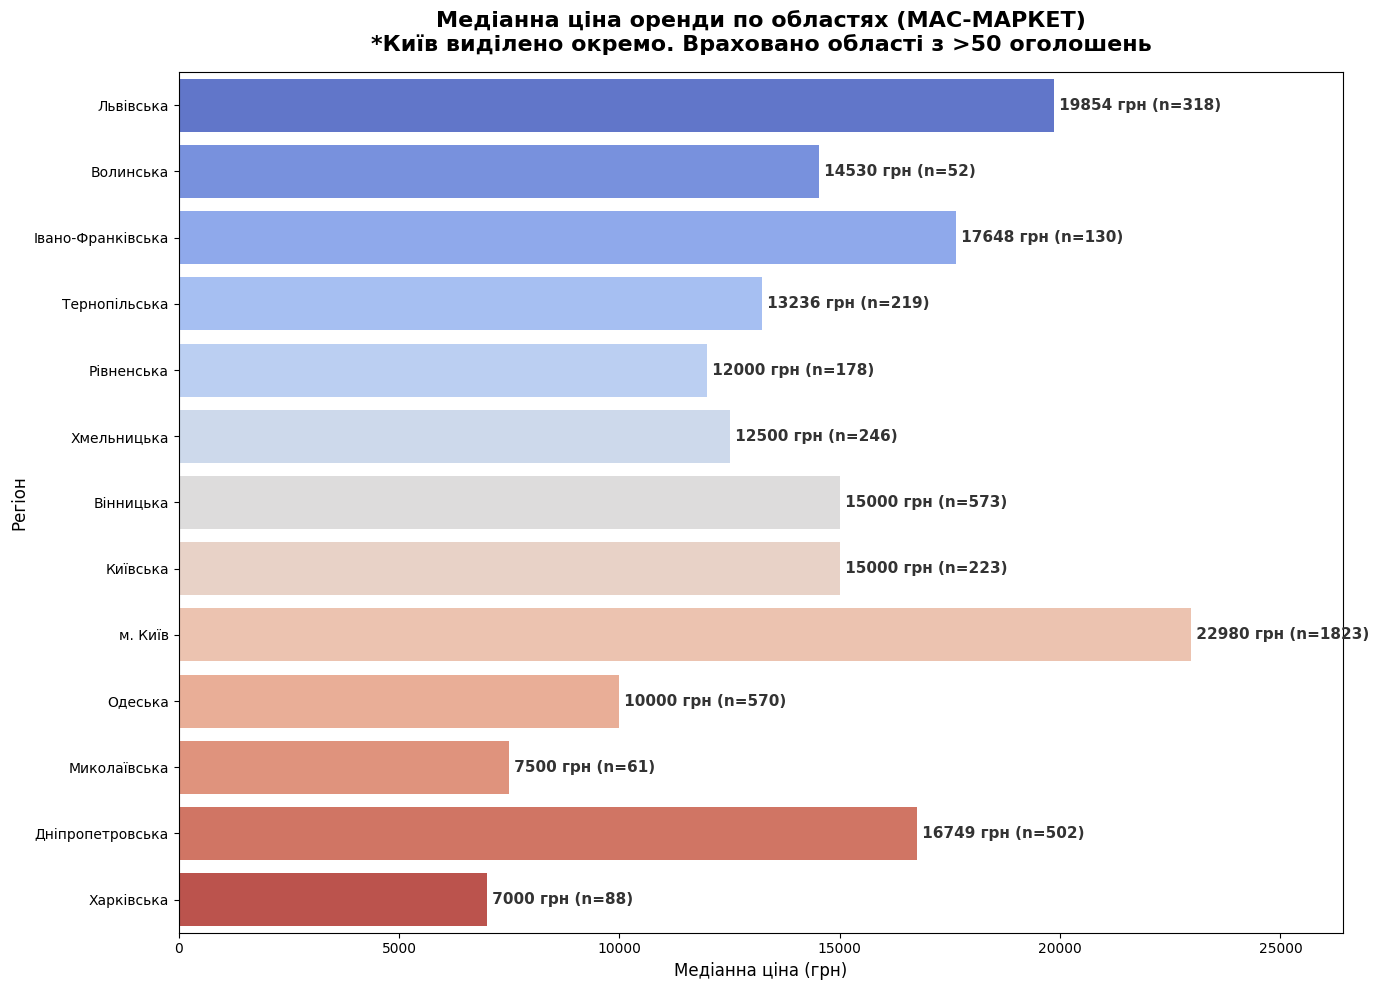


Детальна статистика (відсортовано Захід -> Схід):
           region  count  median_price
        Львівська    318       19854.0
        Волинська     52       14530.0
Івано-Франківська    130       17648.0
    Тернопільська    219       13236.0
       Рівненська    178       12000.0
      Хмельницька    246       12500.0
        Вінницька    573       15000.0
         Київська    223       15000.0
          м. Київ   1823       22980.0
          Одеська    570       10000.0
     Миколаївська     61        7500.0
 Дніпропетровська    502       16749.5
       Харківська     88        7000.0


In [304]:
df_geo = cl_df.copy()
df_geo = df_geo[df_geo['segment'] == 'Мас-маркет']

# Створюємо нову колонку 'region'. Якщо міста немає в словнику, буде 'Невідома область'
df_geo['region'] = df_geo['city_name'].map(city_to_oblast).fillna('Невідома область')

# Перевіримо, чи не загубили якісь великі міста:
unknown_cities = df_geo[df_geo['region'] == 'Невідома область']['city_name'].value_counts()
if not unknown_cities.empty:
    print("УВАГА! Ці міста не потрапили в жодну область. Додай їх у словник вище, якщо їх багато:")
    print(unknown_cities.head())
    print("-" * 50)


# ==========================================
# 2. ПІДГОТОВКА ДАНИХ (Групування та фільтр)
# ==========================================
region_stats = df_geo.groupby('region')['price_UAH'].agg(
    count='count', 
    median_price='median'
).reset_index()

# Видаляємо "Невідомі області" та ті, де менше 50 оголошень
region_stats = region_stats[(region_stats['count'] >= 50) & (region_stats['region'] != 'Невідома область')]


# ==========================================
# 3. СОРТУВАННЯ ІЗ ЗАХОДУ НА СХІД
# ==========================================
w2e_mapping = {
    'закарпат': 1, 'львів': 2, 'волин': 3, 'івано-франків': 4,
    'тернопіл': 5, 'чернівец': 6, 'рівнен': 7, 'хмельниц': 8,
    'житомир': 9, 'вінниц': 10, 'київська': 11, 'м. київ': 12, 
    'чернігів': 13, 'черкас': 14, 'кіровоград': 15, 'полтав': 16,
    'одес': 17, 'миколаїв': 18, 'херсон': 19,
    'сумськ': 20, 'дніпропетров': 21, 'запоріз': 22, 'харків': 23,
}

def get_w2e_order(region_name):
    name_lower = str(region_name).lower()
    for key, val in w2e_mapping.items():
        if key in name_lower:
            return val
    return 99 

region_stats['w2e_order'] = region_stats['region'].apply(get_w2e_order)
region_stats = region_stats.sort_values('w2e_order')


# ==========================================
# 4. ПОБУДОВА ГРАФІКА
# ==========================================
plt.figure(figsize=(14, 10))

ax = sns.barplot(
    data=region_stats, 
    y='region', 
    x='median_price', 
    palette='coolwarm',
    hue='region',
    legend=False
)

plt.title('Медіанна ціна оренди по областях (МАС-МАРКЕТ)\n*Київ виділено окремо. Враховано області з >50 оголошень', 
          fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Медіанна ціна (грн)', fontsize=12)
plt.ylabel('Регіон', fontsize=12)

for i, p in enumerate(ax.patches):
    width = p.get_width()
    count = region_stats.iloc[i]['count']
    ax.annotate(f" {int(width)} грн (n={count})", 
                (width, p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', fontsize=11, fontweight='bold', color='#333333')

plt.xlim(0, region_stats['median_price'].max() * 1.15)
plt.tight_layout()
plt.savefig('plots/01_price_by_region_01.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nДетальна статистика (відсортовано Захід -> Схід):")
print(region_stats[['region', 'count', 'median_price']].to_string(index=False))

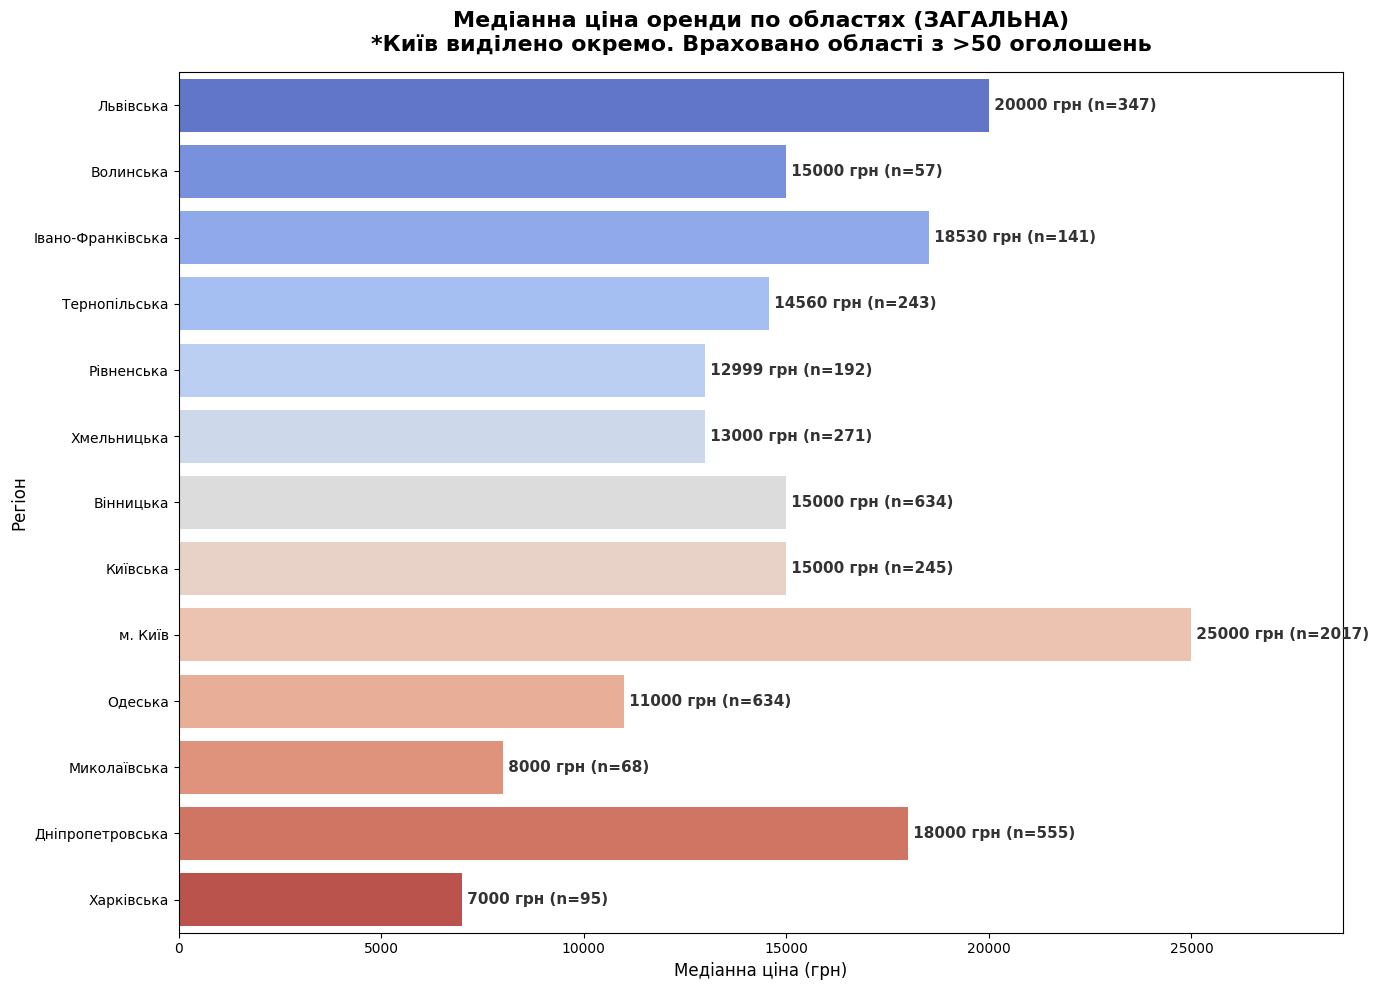


Детальна статистика (відсортовано Захід -> Схід):
           region  count  median_price
        Львівська    347       20000.0
        Волинська     57       15000.0
Івано-Франківська    141       18530.0
    Тернопільська    243       14560.0
       Рівненська    192       12999.5
      Хмельницька    271       13000.0
        Вінницька    634       15000.0
         Київська    245       15000.0
          м. Київ   2017       25000.0
          Одеська    634       11000.0
     Миколаївська     68        8000.0
 Дніпропетровська    555       18000.0
       Харківська     95        7000.0


In [305]:
df_geo = cl_df.copy()

# Створюємо нову колонку 'region'. Якщо міста немає в словнику, буде 'Невідома область'
df_geo['region'] = df_geo['city_name'].map(city_to_oblast).fillna('Невідома область')

# Перевіримо, чи не загубили якісь великі міста:
unknown_cities = df_geo[df_geo['region'] == 'Невідома область']['city_name'].value_counts()
if not unknown_cities.empty:
    print("УВАГА! Ці міста не потрапили в жодну область. Додай їх у словник вище, якщо їх багато:")
    print(unknown_cities.head())
    print("-" * 50)


# ==========================================
# 2. ПІДГОТОВКА ДАНИХ (Групування та фільтр)
# ==========================================
region_stats = df_geo.groupby('region')['price_UAH'].agg(
    count='count', 
    median_price='median'
).reset_index()

# Видаляємо "Невідомі області" та ті, де менше 50 оголошень
region_stats = region_stats[(region_stats['count'] >= 50) & (region_stats['region'] != 'Невідома область')]


# ==========================================
# 3. СОРТУВАННЯ ІЗ ЗАХОДУ НА СХІД
# ==========================================
w2e_mapping = {
    'закарпат': 1, 'львів': 2, 'волин': 3, 'івано-франків': 4,
    'тернопіл': 5, 'чернівец': 6, 'рівнен': 7, 'хмельниц': 8,
    'житомир': 9, 'вінниц': 10, 'київська': 11, 'м. київ': 12, 
    'чернігів': 13, 'черкас': 14, 'кіровоград': 15, 'полтав': 16,
    'одес': 17, 'миколаїв': 18, 'херсон': 19,
    'сумськ': 20, 'дніпропетров': 21, 'запоріз': 22, 'харків': 23,
}

def get_w2e_order(region_name):
    name_lower = str(region_name).lower()
    for key, val in w2e_mapping.items():
        if key in name_lower:
            return val
    return 99 

region_stats['w2e_order'] = region_stats['region'].apply(get_w2e_order)
region_stats = region_stats.sort_values('w2e_order')


# ==========================================
# 4. ПОБУДОВА ГРАФІКА
# ==========================================
plt.figure(figsize=(14, 10))

ax = sns.barplot(
    data=region_stats, 
    y='region', 
    x='median_price', 
    palette='coolwarm',
    hue='region',
    legend=False
)

plt.title('Медіанна ціна оренди по областях (ЗАГАЛЬНА)\n*Київ виділено окремо. Враховано області з >50 оголошень', 
          fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Медіанна ціна (грн)', fontsize=12)
plt.ylabel('Регіон', fontsize=12)

for i, p in enumerate(ax.patches):
    width = p.get_width()
    count = region_stats.iloc[i]['count']
    ax.annotate(f" {int(width)} грн (n={count})", 
                (width, p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', fontsize=11, fontweight='bold', color='#333333')

plt.xlim(0, region_stats['median_price'].max() * 1.15)
plt.tight_layout()
plt.savefig('plots/01_price_by_region_02.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nДетальна статистика (відсортовано Захід -> Схід):")
print(region_stats[['region', 'count', 'median_price']].to_string(index=False))

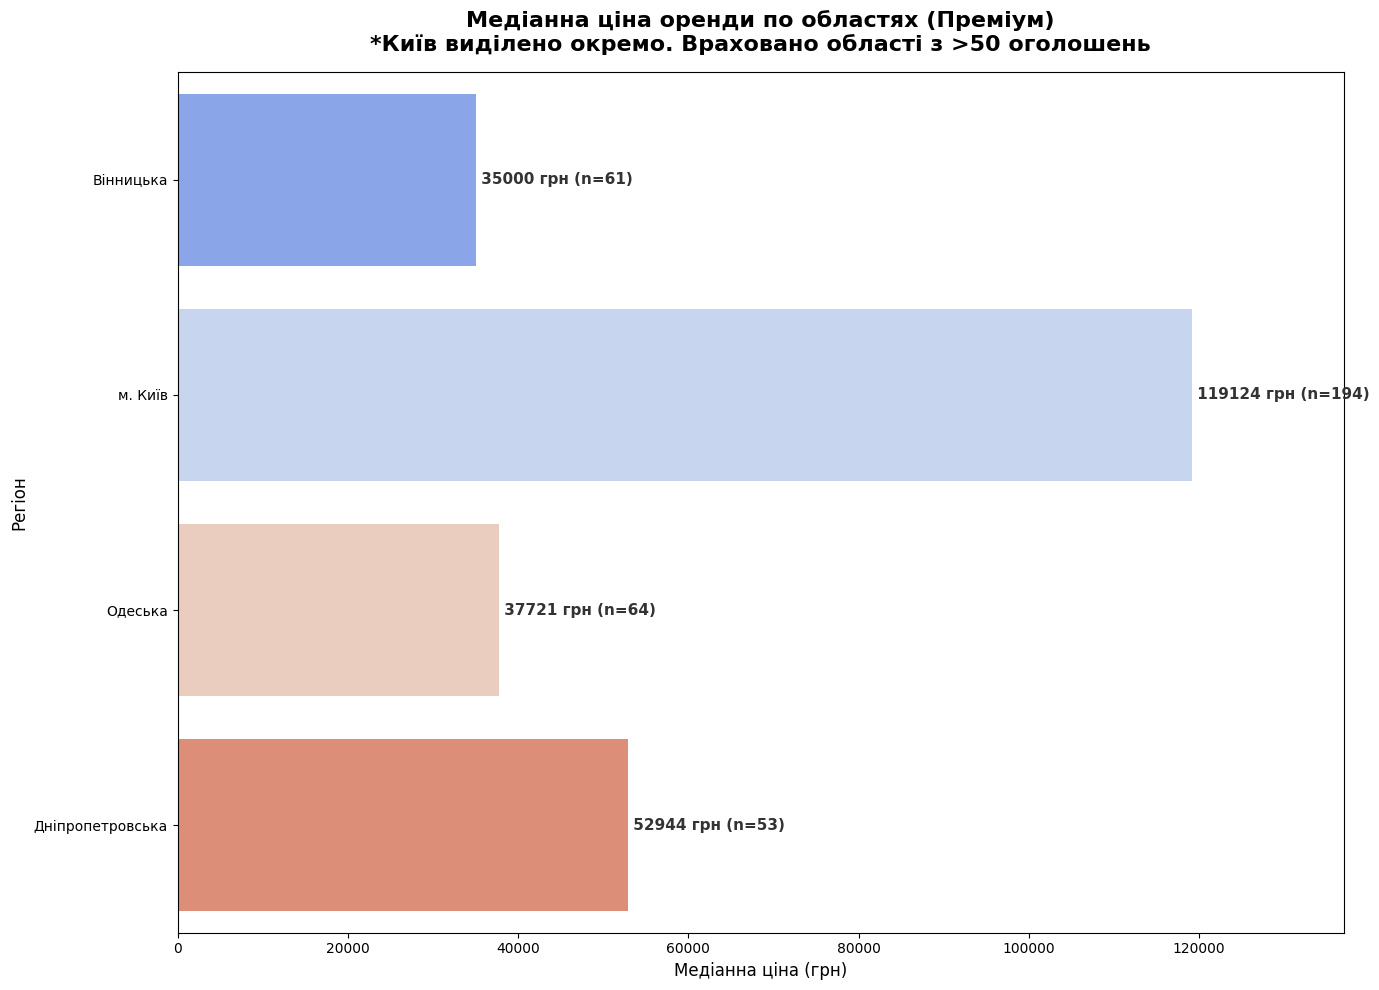


Детальна статистика (відсортовано Захід -> Схід):
          region  count  median_price
       Вінницька     61       35000.0
         м. Київ    194      119124.0
         Одеська     64       37721.5
Дніпропетровська     53       52944.0


In [306]:
df_geo = cl_df.copy()
df_geo = df_geo[df_geo['segment'] == 'Преміум']

# Створюємо нову колонку 'region'. Якщо міста немає в словнику, буде 'Невідома область'
df_geo['region'] = df_geo['city_name'].map(city_to_oblast).fillna('Невідома область')

# Перевіримо, чи не загубили якісь великі міста:
unknown_cities = df_geo[df_geo['region'] == 'Невідома область']['city_name'].value_counts()
if not unknown_cities.empty:
    print("УВАГА! Ці міста не потрапили в жодну область. Додай їх у словник вище, якщо їх багато:")
    print(unknown_cities.head())
    print("-" * 50)


# ==========================================
# 2. ПІДГОТОВКА ДАНИХ (Групування та фільтр)
# ==========================================
region_stats = df_geo.groupby('region')['price_UAH'].agg(
    count='count', 
    median_price='median'
).reset_index()

# Видаляємо "Невідомі області" та ті, де менше 50 оголошень
region_stats = region_stats[(region_stats['count'] >= 50) & (region_stats['region'] != 'Невідома область')]


# ==========================================
# 3. СОРТУВАННЯ ІЗ ЗАХОДУ НА СХІД
# ==========================================
w2e_mapping = {
    'закарпат': 1, 'львів': 2, 'волин': 3, 'івано-франків': 4,
    'тернопіл': 5, 'чернівец': 6, 'рівнен': 7, 'хмельниц': 8,
    'житомир': 9, 'вінниц': 10, 'київська': 11, 'м. київ': 12, 
    'чернігів': 13, 'черкас': 14, 'кіровоград': 15, 'полтав': 16,
    'одес': 17, 'миколаїв': 18, 'херсон': 19,
    'сумськ': 20, 'дніпропетров': 21, 'запоріз': 22, 'харків': 23,
}

def get_w2e_order(region_name):
    name_lower = str(region_name).lower()
    for key, val in w2e_mapping.items():
        if key in name_lower:
            return val
    return 99 

region_stats['w2e_order'] = region_stats['region'].apply(get_w2e_order)
region_stats = region_stats.sort_values('w2e_order')


# ==========================================
# 4. ПОБУДОВА ГРАФІКА
# ==========================================
plt.figure(figsize=(14, 10))

ax = sns.barplot(
    data=region_stats, 
    y='region', 
    x='median_price', 
    palette='coolwarm',
    hue='region',
    legend=False
)

plt.title('Медіанна ціна оренди по областях (Преміум)\n*Київ виділено окремо. Враховано області з >50 оголошень', 
          fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Медіанна ціна (грн)', fontsize=12)
plt.ylabel('Регіон', fontsize=12)

for i, p in enumerate(ax.patches):
    width = p.get_width()
    count = region_stats.iloc[i]['count']
    ax.annotate(f" {int(width)} грн (n={count})", 
                (width, p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', fontsize=11, fontweight='bold', color='#333333')

plt.xlim(0, region_stats['median_price'].max() * 1.15)
plt.tight_layout()
plt.savefig('plots/01_price_by_region_03.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nДетальна статистика (відсортовано Захід -> Схід):")
print(region_stats[['region', 'count', 'median_price']].to_string(index=False))

#### 2. Середня ціна по кімнатам

C:\Users\Acer\AppData\Local\Temp\ipykernel_20520\182621021.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


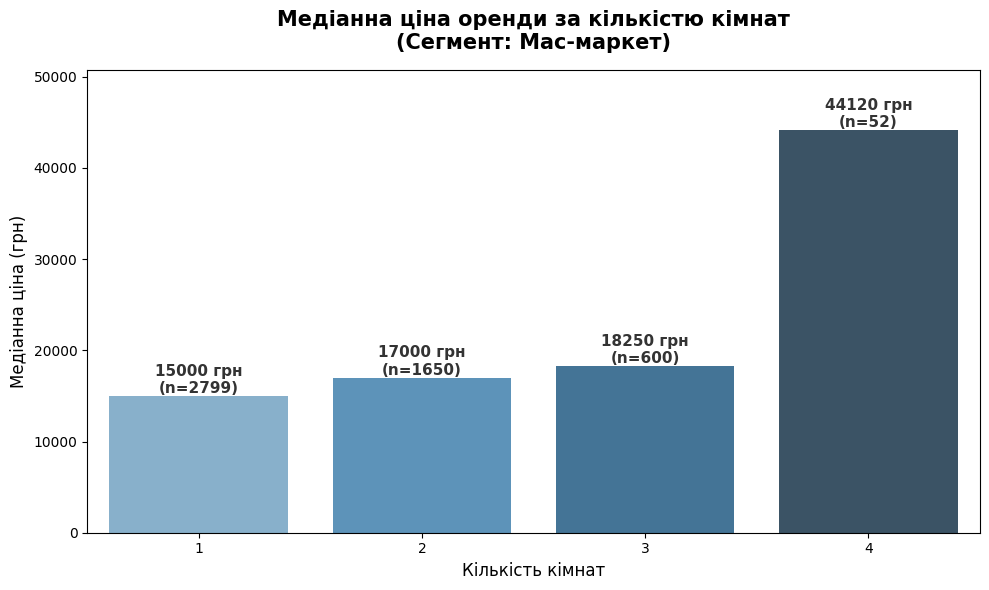


Точні медіанні ціни (Мас-маркет, до 4 кімнат):
 Кількість кімнат  Медіанна ціна (грн)
                1              15000.0
                2              17000.0
                3              18250.0
                4              44120.0


In [307]:
# ==========================================
# 1. ФІЛЬТРАЦІЯ ДАНИХ
# ==========================================
# Беремо тільки 'Мас-маркет' І (символ &) кількість кімнат <= 4
# Використовуємо .copy(), щоб випадково не змінити основний датасет
df_filtered = cl_df[(cl_df['segment'] == 'Мас-маркет') & (cl_df['rooms'] <= 4)].copy()

# Рахуємо медіану і кількість
stats = df_filtered.groupby('rooms').agg(
    median_price=('price_UAH', 'median'),
    count_ads=('price_UAH', 'count')
).reset_index()

# ==========================================
# 2. ПОБУДОВА ГРАФІКА
# ==========================================
plt.figure(figsize=(10, 6))

# Будуємо вертикальний графік
ax = sns.barplot(
    data=stats, 
    x='rooms', 
    y='median_price', 
    palette='Blues_d' # Красивий градієнт (від темного до світлого синього)
)

# Косметика
plt.title('Медіанна ціна оренди за кількістю кімнат\n(Сегмент: Мас-маркет)', fontsize=15, pad=15, fontweight='bold')
plt.xlabel('Кількість кімнат', fontsize=12)
plt.ylabel('Медіанна ціна (грн)', fontsize=12)

for index, row in stats.iterrows():
    # Текст, який ми хочемо вивести
    label_text = f"{int(row['median_price'])} грн\n(n={int(row['count_ads'])})"
    
    # plt.text бере точні координати з таблиці: x = index (0, 1, 2, 3), y = ціна
    plt.text(x=index, y=row['median_price'], s=label_text, 
             ha='center', va='bottom', fontsize=11, fontweight='bold', color='#333333')

# Трохи піднімаємо "стелю" графіка, щоб дворядковий текст не зрізався
plt.ylim(0, stats['median_price'].max() * 1.15)

plt.tight_layout()
plt.savefig('plots/02_price_by_rooms_01.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 3. ТЕКСТОВИЙ ВИВІД (ДЛЯ ПЕРЕВІРКИ)
# ==========================================
print("\nТочні медіанні ціни (Мас-маркет, до 4 кімнат):")
stats = df_filtered.groupby('rooms')['price_UAH'].median().reset_index()
stats.columns = ['Кількість кімнат', 'Медіанна ціна (грн)']
print(stats.to_string(index=False))

C:\Users\Acer\AppData\Local\Temp\ipykernel_20520\3053895162.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


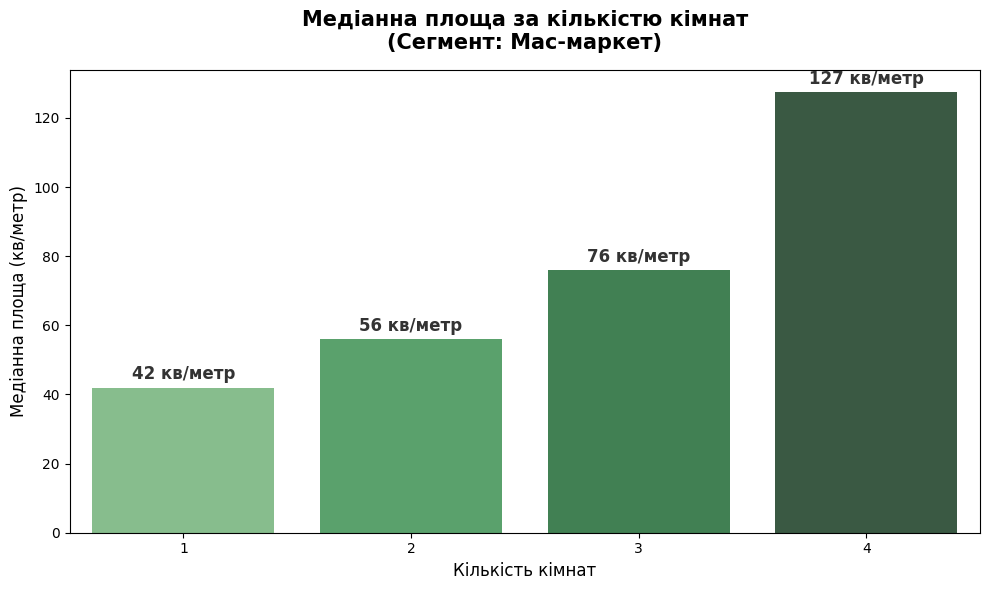


Точні медіанні ціни (Мас-маркет, до 4 кімнат):
 Кількість кімнат  Медіанна ціна (грн)
                1              15000.0
                2              17000.0
                3              18250.0
                4              44120.0


In [308]:
# ==========================================
# 1. ФІЛЬТРАЦІЯ ДАНИХ
# ==========================================
# Беремо тільки 'Мас-маркет' І (символ &) кількість кімнат <= 4
# Використовуємо .copy(), щоб випадково не змінити основний датасет
df_filtered = cl_df[(cl_df['segment'] == 'Мас-маркет') & (cl_df['rooms'] <= 4)].copy()

# ==========================================
# 2. ПОБУДОВА ГРАФІКА
# ==========================================
plt.figure(figsize=(10, 6))

# Будуємо вертикальний графік
ax = sns.barplot(
    data=df_filtered, 
    x='rooms', 
    y='area_total', 
    estimator=np.median, 
    errorbar=None,
    palette='Greens_d' # Красивий градієнт (від темного до світлого синього)
)

# Косметика
plt.title('Медіанна площа за кількістю кімнат\n(Сегмент: Мас-маркет)', fontsize=15, pad=15, fontweight='bold')
plt.xlabel('Кількість кімнат', fontsize=12)
plt.ylabel('Медіанна площа (кв/метр)', fontsize=12)

# Додаємо точні цифри над кожним стовпчиком (використовуємо сучасний метод)
for container in ax.containers:
    ax.bar_label(container, fmt='%d кв/метр', padding=3, fontsize=12, fontweight='bold', color='#333333')

plt.tight_layout()
plt.savefig('plots/02_total_area_by_rooms_02.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 3. ТЕКСТОВИЙ ВИВІД (ДЛЯ ПЕРЕВІРКИ)
# ==========================================
print("\nТочні медіанні ціни (Мас-маркет, до 4 кімнат):")
stats = df_filtered.groupby('rooms')['price_UAH'].median().reset_index()
stats.columns = ['Кількість кімнат', 'Медіанна ціна (грн)']
print(stats.to_string(index=False))

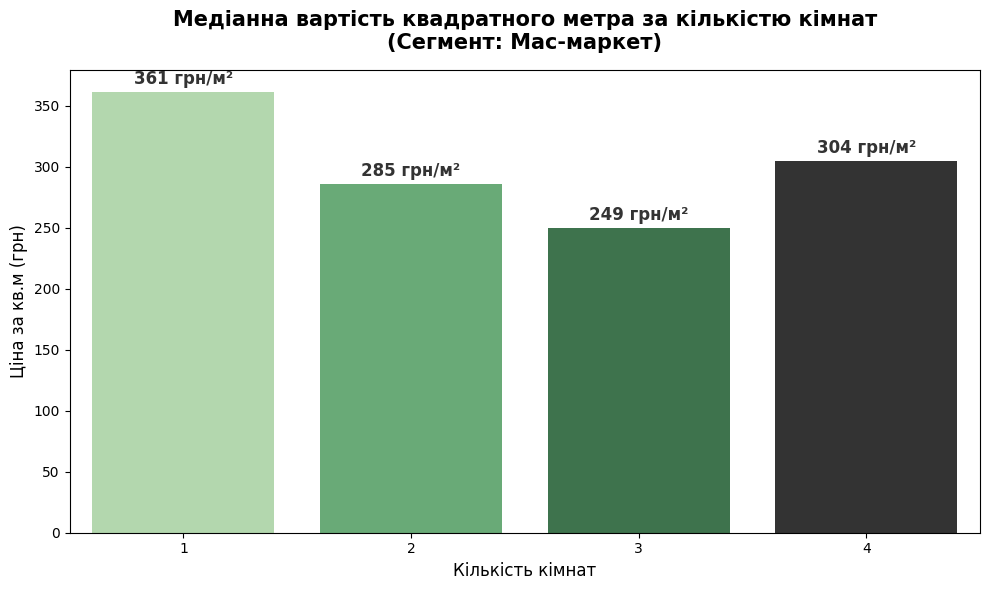


Точні медіанні ціни за кв.м (Мас-маркет, до 4 кімнат):
 Кількість кімнат  Медіанна ціна за кв.м (грн)
                1                        361.0
                2                        286.0
                3                        250.0
                4                        304.0


In [309]:
# ======================
# 1. ФІЛЬТРАЦІЯ ДАНИХ
# ==========================================
df_filtered = cl_df[(cl_df['segment'] == 'Мас-маркет') & (cl_df['rooms'] <= 4)].copy()

# ==========================================
# 2. ПОБУДОВА ГРАФІКА
# ==========================================
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=df_filtered, 
    x='rooms', 
    y='price_per_sqm',   # 🟢 ТЕПЕР АНАЛІЗУЄМО КВАДРАТНІ МЕТРИ
    hue='rooms',         # Додано для правильного відображення градієнта
    estimator=np.median, 
    errorbar=None,
    palette='Greens_d',  # Зелений градієнт
    legend=False
)

# Косметика
plt.title('Медіанна вартість квадратного метра за кількістю кімнат\n(Сегмент: Мас-маркет)', fontsize=15, pad=15, fontweight='bold')
plt.xlabel('Кількість кімнат', fontsize=12)
plt.ylabel('Ціна за кв.м (грн)', fontsize=12)

# Додаємо точні цифри над кожним стовпчиком (з позначкою грн/м²)
for container in ax.containers:
    # Використовуємо int() всередині форматування, щоб відкинути копійки, якщо вони є
    ax.bar_label(container, fmt='%d грн/м²', padding=3, fontsize=12, fontweight='bold', color='#333333')

plt.tight_layout()
plt.savefig('plots/02_area_per_sqm_by_rooms_03.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 3. ТЕКСТОВИЙ ВИВІД (ДЛЯ ПЕРЕВІРКИ)
# ==========================================
print("\nТочні медіанні ціни за кв.м (Мас-маркет, до 4 кімнат):")
stats_sqm = df_filtered.groupby('rooms')['price_per_sqm'].median().reset_index()
stats_sqm.columns = ['Кількість кімнат', 'Медіанна ціна за кв.м (грн)']
print(stats_sqm.round(0).to_string(index=False))

Отже, по цьому графіку можна сказати що 1-кімнатні квартири найдорожчі за квадратний метр. Це може бути спричинено величезним попитом або люди беруть просто дешевші однушки, тому що не можуть доплатити декілька тисяч для більш просторної двушки.

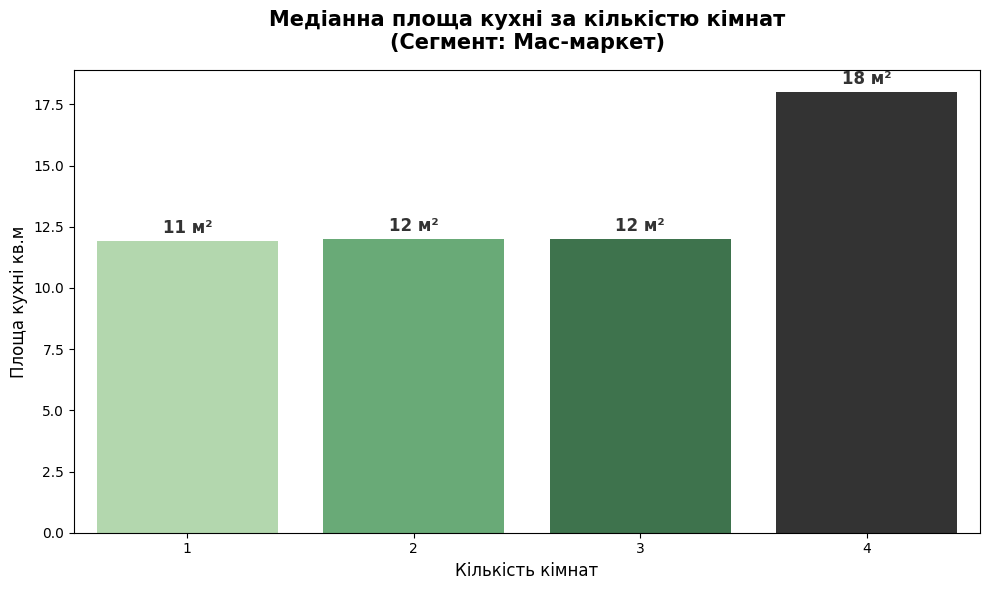

In [310]:
# ======================
# 1. ФІЛЬТРАЦІЯ ДАНИХ
# ==========================================
df_filtered = cl_df[(cl_df['segment'] == 'Мас-маркет') & (cl_df['rooms'] <= 4)].copy()

# ==========================================
# 2. ПОБУДОВА ГРАФІКА
# ==========================================
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=df_filtered, 
    x='rooms', 
    y='area_kitchen',   
    hue='rooms',         # Додано для правильного відображення градієнта
    estimator=np.median, 
    errorbar=None,
    palette='Greens_d',  # Зелений градієнт
    legend=False
)

# Косметика
plt.title('Медіанна площа кухні за кількістю кімнат\n(Сегмент: Мас-маркет)', fontsize=15, pad=15, fontweight='bold')
plt.xlabel('Кількість кімнат', fontsize=12)
plt.ylabel('Площа кухні кв.м', fontsize=12)

# Додаємо точні цифри над кожним стовпчиком
for container in ax.containers:
    # Використовуємо int() всередині форматування, щоб відкинути копійки, якщо вони є
    ax.bar_label(container, fmt='%d м²', padding=3, fontsize=12, fontweight='bold', color='#333333')

plt.tight_layout()
plt.savefig('plots/02_area_kitchen_by_rooms_04.png', dpi=300, bbox_inches='tight')
plt.show()

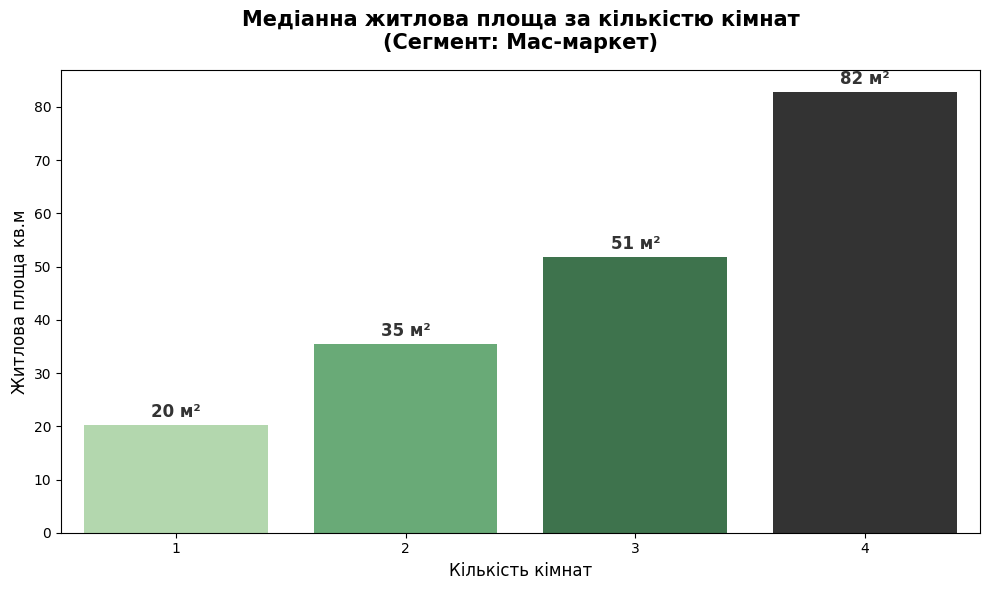

In [311]:
# ======================
# 1. ФІЛЬТРАЦІЯ ДАНИХ
# ==========================================
df_filtered = cl_df[(cl_df['segment'] == 'Мас-маркет') & (cl_df['rooms'] <= 4)].copy()

# ==========================================
# 2. ПОБУДОВА ГРАФІКА
# ==========================================
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=df_filtered, 
    x='rooms', 
    y='area_living',   
    hue='rooms',         # Додано для правильного відображення градієнта
    estimator=np.mean, 
    errorbar=None,
    palette='Greens_d',  # Зелений градієнт
    legend=False
)

# Косметика
plt.title('Медіанна житлова площа за кількістю кімнат\n(Сегмент: Мас-маркет)', fontsize=15, pad=15, fontweight='bold')
plt.xlabel('Кількість кімнат', fontsize=12)
plt.ylabel('Житлова площа кв.м', fontsize=12)

# Додаємо точні цифри над кожним стовпчиком
for container in ax.containers:
    # Використовуємо int() всередині форматування, щоб відкинути копійки, якщо вони є
    ax.bar_label(container, fmt='%d м²', padding=3, fontsize=12, fontweight='bold', color='#333333')

plt.tight_layout()
plt.savefig('plots/02_area_living_by_rooms_05.png', dpi=300, bbox_inches='tight')
plt.show()

**ВИСНОВКИ** 
1. Шалений попит на однокімнатні квартири

Квадратний метр в 1-кімнатних квартирах найдорожчий через колосальний попит. Однокімнатна квартира — це базовий, стартовий варіант для більшості орендарів (студентів, молодих спеціалістів, пар), які хочуть жити окремо. Оскільки в абсолютних цифрах (загальна сума за місяць) це найдешевше житло на ринку, за нього конкурує найбільша кількість людей. Цей постійний попит дозволяє власникам тримати ціну за квадратний метр на максимальному рівні.

2. Математика собівартості: "розмиття" дорогих зон

Графік наочно доводить: у багатокімнатних квартирах площа найдорожчої зони (кухні/санвузла з розводкою, плиткою та технікою) майже не змінюється. Метраж зростає виключно за рахунок додавання "дешевих" житлових кімнат (лише стіни, шпалери, ламінат). Оскільки у великих квартирах домінує дешева житлова площа, висока вартість ремонту комунікацій "розмазується", що робить кожен додатковий квадратний метр значно дешевшим.

#### 3. Ціна оренди кухні студії проти звичайних однокімнатних квартир

C:\Users\Acer\AppData\Local\Temp\ipykernel_20520\299113153.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


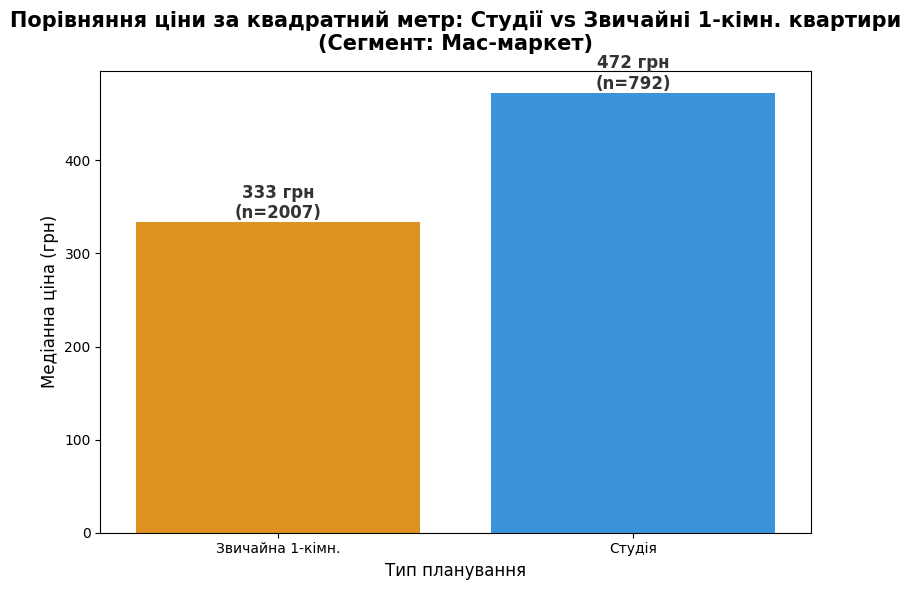

In [312]:
# ======================
# 1. ФІЛЬТРАЦІЯ ДАНИХ
# ==========================================
df_1room = cl_df[(cl_df['segment'] == 'Мас-маркет') & (cl_df['rooms'] == 1)].copy()

df_1room['flat_type'] = np.where(df_1room['kitchen_studio'] == 1, 'Студія', 'Звичайна 1-кімн.')

# Рахуємо медіанну ціну і кількість оголошень для кожної групи
stats = df_1room.groupby('flat_type').agg(
    median_price=('price_per_sqm', 'median'),
    count_ads=('price_per_sqm', 'count')
).reset_index()

# ==========================================
# 2. ПОБУДОВА ГРАФІКА
# ==========================================
plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=stats, 
    x='flat_type', 
    y='median_price',   
    palette=['#FF9800', '#2196F3']
)

# Косметика
plt.title('Порівняння ціни за квадратний метр: Студії vs Звичайні 1-кімн. квартири\n(Сегмент: Мас-маркет)', fontsize=15, pad=15, fontweight='bold')
plt.xlabel('Тип планування', fontsize=12)
plt.ylabel('Медіанна ціна (грн)', fontsize=12)

# Додаємо точні цифри над кожним стовпчиком
for index, row in stats.iterrows():
    label_text = f"{int(row['median_price'])} грн\n(n={int(row['count_ads'])})"
    plt.text(x=index, y=row['median_price'], s=label_text, 
             ha='center', va='bottom', fontsize=12, fontweight='bold', color='#333333')

plt.tight_layout()
plt.savefig('plots/03_price_per_sqm_kitchen_studio_vs_normal_00.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Acer\AppData\Local\Temp\ipykernel_20520\1779469226.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


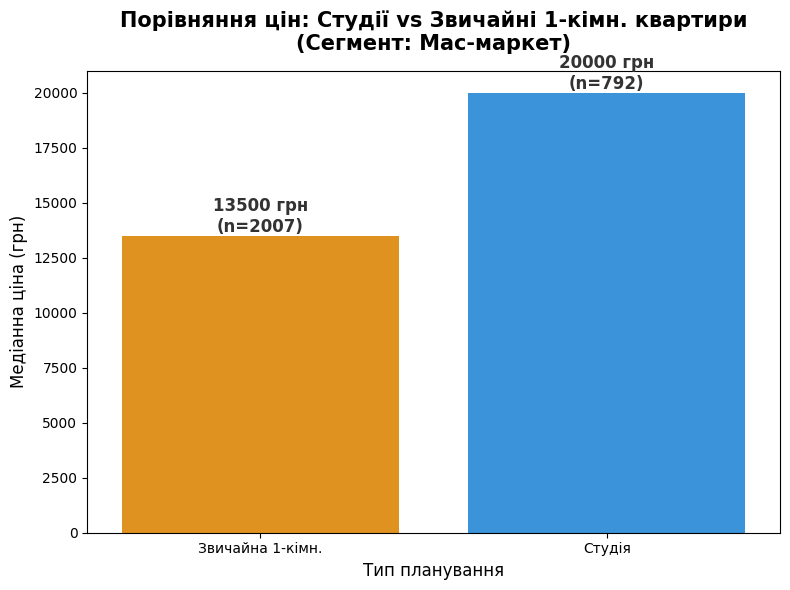

In [313]:
# ======================
# 1. ФІЛЬТРАЦІЯ ДАНИХ
# ==========================================
df_1room = cl_df[(cl_df['segment'] == 'Мас-маркет') & (cl_df['rooms'] == 1)].copy()

df_1room['flat_type'] = np.where(df_1room['kitchen_studio'] == 1, 'Студія', 'Звичайна 1-кімн.')

# Рахуємо медіанну ціну і кількість оголошень для кожної групи
stats = df_1room.groupby('flat_type').agg(
    median_price=('price_UAH', 'median'),
    count_ads=('price_UAH', 'count')
).reset_index()

# ==========================================
# 2. ПОБУДОВА ГРАФІКА
# ==========================================
plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=stats, 
    x='flat_type', 
    y='median_price',   
    palette=['#FF9800', '#2196F3']
)

# Косметика
plt.title('Порівняння цін: Студії vs Звичайні 1-кімн. квартири\n(Сегмент: Мас-маркет)', fontsize=15, pad=15, fontweight='bold')
plt.xlabel('Тип планування', fontsize=12)
plt.ylabel('Медіанна ціна (грн)', fontsize=12)

# Додаємо точні цифри над кожним стовпчиком
for index, row in stats.iterrows():
    label_text = f"{int(row['median_price'])} грн\n(n={int(row['count_ads'])})"
    plt.text(x=index, y=row['median_price'], s=label_text, 
             ha='center', va='bottom', fontsize=12, fontweight='bold', color='#333333')

plt.tight_layout()
plt.savefig('plots/03_price_kitchen_studio_vs_normal_01.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Acer\AppData\Local\Temp\ipykernel_20520\881208930.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


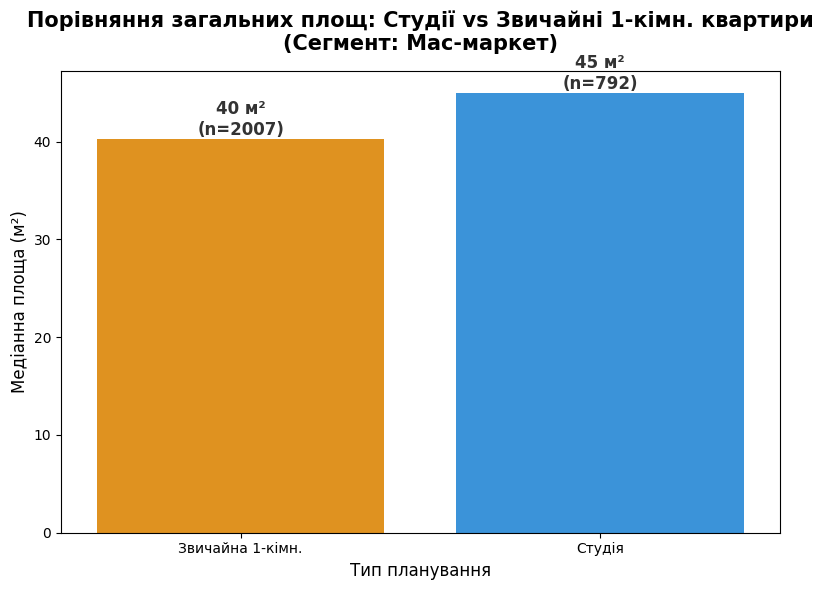

In [314]:
# ======================
# 1. ФІЛЬТРАЦІЯ ДАНИХ
# ==========================================
df_1room = cl_df[(cl_df['segment'] == 'Мас-маркет') & (cl_df['rooms'] == 1)].copy()

df_1room['flat_type'] = np.where(df_1room['kitchen_studio'] == 1, 'Студія', 'Звичайна 1-кімн.')

# Рахуємо медіанну ціну і кількість оголошень для кожної групи
stats = df_1room.groupby('flat_type').agg(
    median_area=('area_total', 'median'),
    count_ads=('area_total', 'count')
).reset_index()

# ==========================================
# 2. ПОБУДОВА ГРАФІКА
# ==========================================
plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=stats, 
    x='flat_type', 
    y='median_area',   
    palette=['#FF9800', '#2196F3']
)

# Косметика
plt.title('Порівняння загальних площ: Студії vs Звичайні 1-кімн. квартири\n(Сегмент: Мас-маркет)', fontsize=15, pad=15, fontweight='bold')
plt.xlabel('Тип планування', fontsize=12)
plt.ylabel('Медіанна площа (м²)', fontsize=12)

# Додаємо точні цифри над кожним стовпчиком
for index, row in stats.iterrows():
    label_text = f"{int(row['median_area'])} м²\n(n={int(row['count_ads'])})"
    plt.text(x=index, y=row['median_area'], s=label_text, 
             ha='center', va='bottom', fontsize=12, fontweight='bold', color='#333333')

plt.tight_layout()
plt.savefig('plots/03_areatotal_kitchen_studio_vs_normal_02.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Acer\AppData\Local\Temp\ipykernel_20520\3010370197.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


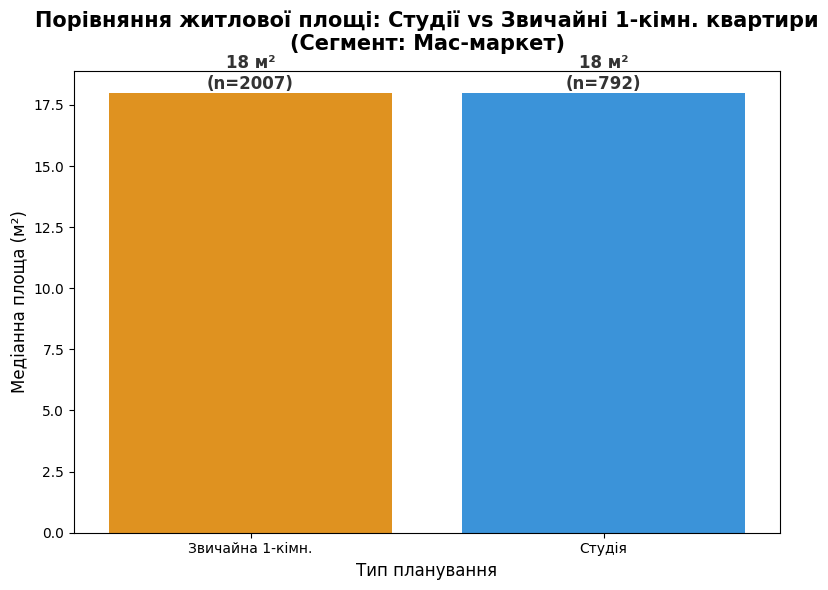

In [315]:
# ======================
# 1. ФІЛЬТРАЦІЯ ДАНИХ
# ==========================================
df_1room = cl_df[(cl_df['segment'] == 'Мас-маркет') & (cl_df['rooms'] == 1)].copy()

df_1room['flat_type'] = np.where(df_1room['kitchen_studio'] == 1, 'Студія', 'Звичайна 1-кімн.')

# Рахуємо медіанну ціну і кількість оголошень для кожної групи
stats = df_1room.groupby('flat_type').agg(
    median_area=('area_living', 'median'),
    count_ads=('area_living', 'count')
).reset_index()

# ==========================================
# 2. ПОБУДОВА ГРАФІКА
# ==========================================
plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=stats, 
    x='flat_type', 
    y='median_area',   
    palette=['#FF9800', '#2196F3']
)

# Косметика
plt.title('Порівняння житлової площі: Студії vs Звичайні 1-кімн. квартири\n(Сегмент: Мас-маркет)', fontsize=15, pad=15, fontweight='bold')
plt.xlabel('Тип планування', fontsize=12)
plt.ylabel('Медіанна площа (м²)', fontsize=12)

# Додаємо точні цифри над кожним стовпчиком
for index, row in stats.iterrows():
    label_text = f"{int(row['median_area'])} м²\n(n={int(row['count_ads'])})"
    plt.text(x=index, y=row['median_area'], s=label_text, 
             ha='center', va='bottom', fontsize=12, fontweight='bold', color='#333333')

plt.tight_layout()
plt.savefig('plots/03_arealiving_kitchen_studio_vs_normal_03.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Acer\AppData\Local\Temp\ipykernel_20520\4061135725.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


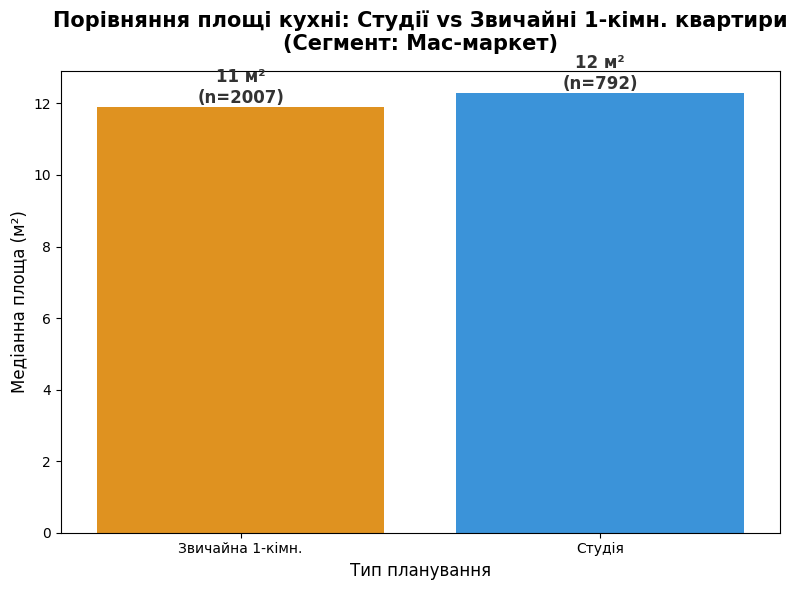

In [316]:
# ======================
# 1. ФІЛЬТРАЦІЯ ДАНИХ
# ==========================================
df_1room = cl_df[(cl_df['segment'] == 'Мас-маркет') & (cl_df['rooms'] == 1)].copy()

df_1room['flat_type'] = np.where(df_1room['kitchen_studio'] == 1, 'Студія', 'Звичайна 1-кімн.')

# Рахуємо медіанну ціну і кількість оголошень для кожної групи
stats = df_1room.groupby('flat_type').agg(
    median_area=('area_kitchen', 'median'),
    count_ads=('area_kitchen', 'count')
).reset_index()

# ==========================================
# 2. ПОБУДОВА ГРАФІКА
# ==========================================
plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=stats, 
    x='flat_type', 
    y='median_area',   
    palette=['#FF9800', '#2196F3']
)

# Косметика
plt.title('Порівняння площі кухні: Студії vs Звичайні 1-кімн. квартири\n(Сегмент: Мас-маркет)', fontsize=15, pad=15, fontweight='bold')
plt.xlabel('Тип планування', fontsize=12)
plt.ylabel('Медіанна площа (м²)', fontsize=12)

# Додаємо точні цифри над кожним стовпчиком
for index, row in stats.iterrows():
    label_text = f"{int(row['median_area'])} м²\n(n={int(row['count_ads'])})"
    plt.text(x=index, y=row['median_area'], s=label_text, 
             ha='center', va='bottom', fontsize=12, fontweight='bold', color='#333333')

plt.tight_layout()
plt.savefig('plots/03_areakitchen_studio_vs_normal_04.png', dpi=300, bbox_inches='tight')
plt.show()

**ВИСНОВОК:**
 
Аналіз показав неочевидний парадокс ринку: при однаковій житловій площі квартири-студії коштують в середньому на 7000 грн дорожче за класичні 1-кімнатні квартири. Ця націнка (близько 30-40%) формується не за рахунок квадратних метрів, а за рахунок сучасного вигляду та кращої ергономіки простору. По-перше, студії — це переважно нові будинки із сучасним ремонтом, орієнтовані на платоспроможну молодь. По-друге, відкрите планування вирішує проблему старого фонду із затиснутими 5-метровими ізольованими кухнями — у студіях кухонна зона інтегрована в загальну кімнату, що робить її просторішою та зручнішою для життя. Натомість медіанну ціну звичайних "однушок" сильно тягнуть вниз старі квартири без ремонту.

#### 4. Вплив наявності укриття на ціну

C:\Users\Acer\AppData\Local\Temp\ipykernel_20520\1311304371.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


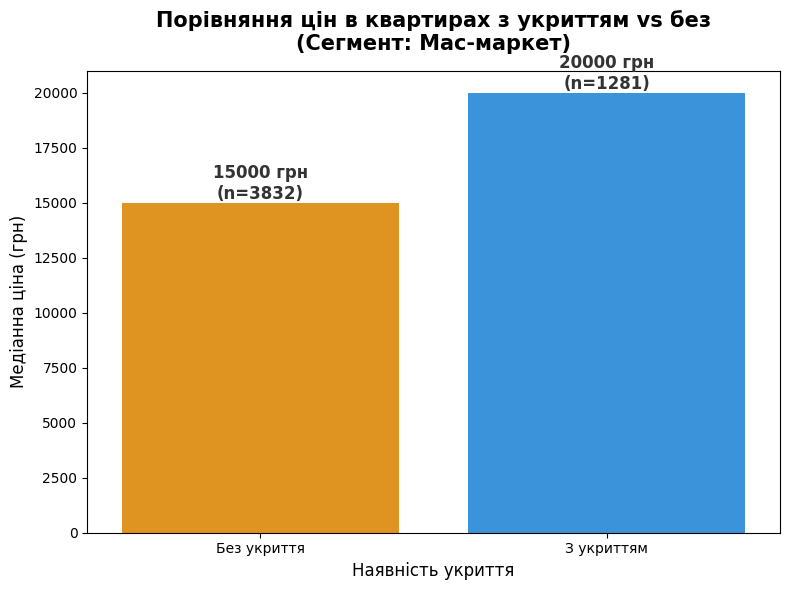

In [317]:
# ======================
# 1. ФІЛЬТРАЦІЯ ДАНИХ
# ==========================================
df_shelter = cl_df[(cl_df['segment'] == 'Мас-маркет')].copy()

df_shelter['shelter_type'] = np.where(df_shelter['has_shelter'] == 1, 'З укриттям', 'Без укриття')

# Рахуємо медіанну ціну і кількість оголошень для кожної групи
stats = df_shelter.groupby('shelter_type').agg(
    median_price=('price_UAH', 'median'),
    count_ads=('price_UAH', 'count')
).reset_index()

# ==========================================
# 2. ПОБУДОВА ГРАФІКА
# ==========================================
plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=stats, 
    x='shelter_type', 
    y='median_price',   
    palette=["#FF9900", '#2196F3']
)

# Косметика
plt.title('Порівняння цін в квартирах з укриттям vs без\n(Сегмент: Мас-маркет)', fontsize=15, pad=15, fontweight='bold')
plt.xlabel('Наявність укриття', fontsize=12)
plt.ylabel('Медіанна ціна (грн)', fontsize=12)

# Додаємо точні цифри над кожним стовпчиком
for index, row in stats.iterrows():
    label_text = f"{int(row['median_price'])} грн\n(n={int(row['count_ads'])})"
    plt.text(x=index, y=row['median_price'], s=label_text, 
             ha='center', va='bottom', fontsize=12, fontweight='bold', color='#333333')

plt.tight_layout()
plt.savefig('plots/04_price_shelter_is_not_01.png', dpi=300, bbox_inches='tight')
plt.show()

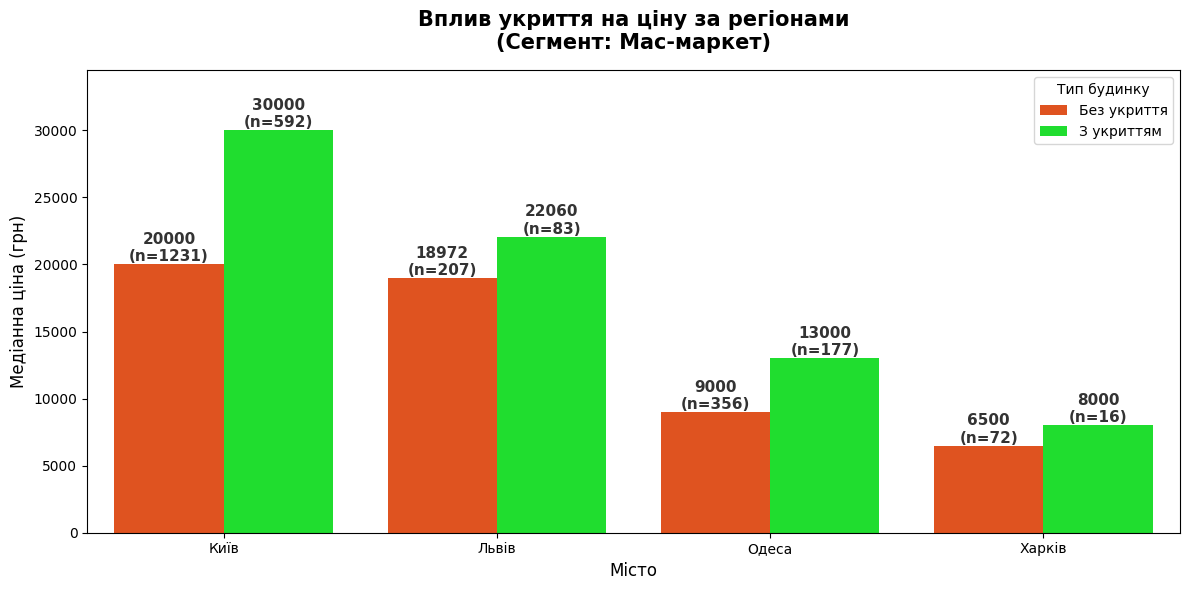

In [318]:
# ==========================================
# 1. ФІЛЬТРАЦІЯ ТА АГРЕГАЦІЯ
# ==========================================
target_cities = ['Київ', 'Львів', 'Одеса', 'Харків']

# Фільтруємо мас-маркет ТА залишаємо тільки потрібні міста
df_shelter = cl_df[(cl_df['segment'] == 'Мас-маркет') & (cl_df['city_name'].isin(target_cities))].copy()

df_shelter['shelter_type'] = np.where(df_shelter['has_shelter'] == 1, 'З укриттям', 'Без укриття')

# Групуємо відразу за двома колонками: містом та наявністю укриття
stats = df_shelter.groupby(['city_name', 'shelter_type']).agg(
    median_price=('price_UAH', 'median'),
    count_ads=('price_UAH', 'count')
).reset_index()

# ==========================================
# 2. ПОБУДОВА ГРАФІКА
# ==========================================
plt.figure(figsize=(12, 6)) # Зробив графік трохи ширшим для 4 міст

# hue='shelter_type' автоматично розіб'є міста на парні стовпчики
ax = sns.barplot(
    data=stats, 
    x='city_name', 
    y='median_price',   
    hue='shelter_type',         
    palette=["#FF4400", "#00FC15"] 
)

# Косметика
plt.title('Вплив укриття на ціну за регіонами\n(Сегмент: Мас-маркет)', fontsize=15, pad=15, fontweight='bold')
plt.xlabel('Місто', fontsize=12)
plt.ylabel('Медіанна ціна (грн)', fontsize=12)

# Броньований метод підписів для згрупованих стовпчиків
for p in ax.patches:
    height = p.get_height()
    
    # Пропускаємо порожні стовпчики (якщо десь немає даних)
    if np.isnan(height) or height == 0: 
        continue
        
    # Знаходимо кількість оголошень для цієї ціни
    count = stats.loc[stats['median_price'] == height, 'count_ads'].values[0]
    
    label_text = f"{int(height)}\n(n={count})"
    
    plt.text(p.get_x() + p.get_width() / 2., height, label_text, 
             ha='center', va='bottom', fontsize=11, fontweight='bold', color='#333333')

plt.ylim(0, stats['median_price'].max() * 1.15)

# Легенду залишаємо, щоб було зрозуміло, який колір що означає
plt.legend(title='Тип будинку', loc='upper right')
plt.tight_layout()
plt.savefig('plots/04_price_shelter_cities.png', dpi=300, bbox_inches='tight')
plt.show()

Дослідити чи справді укриття впливає чи немає побічної кореляції.

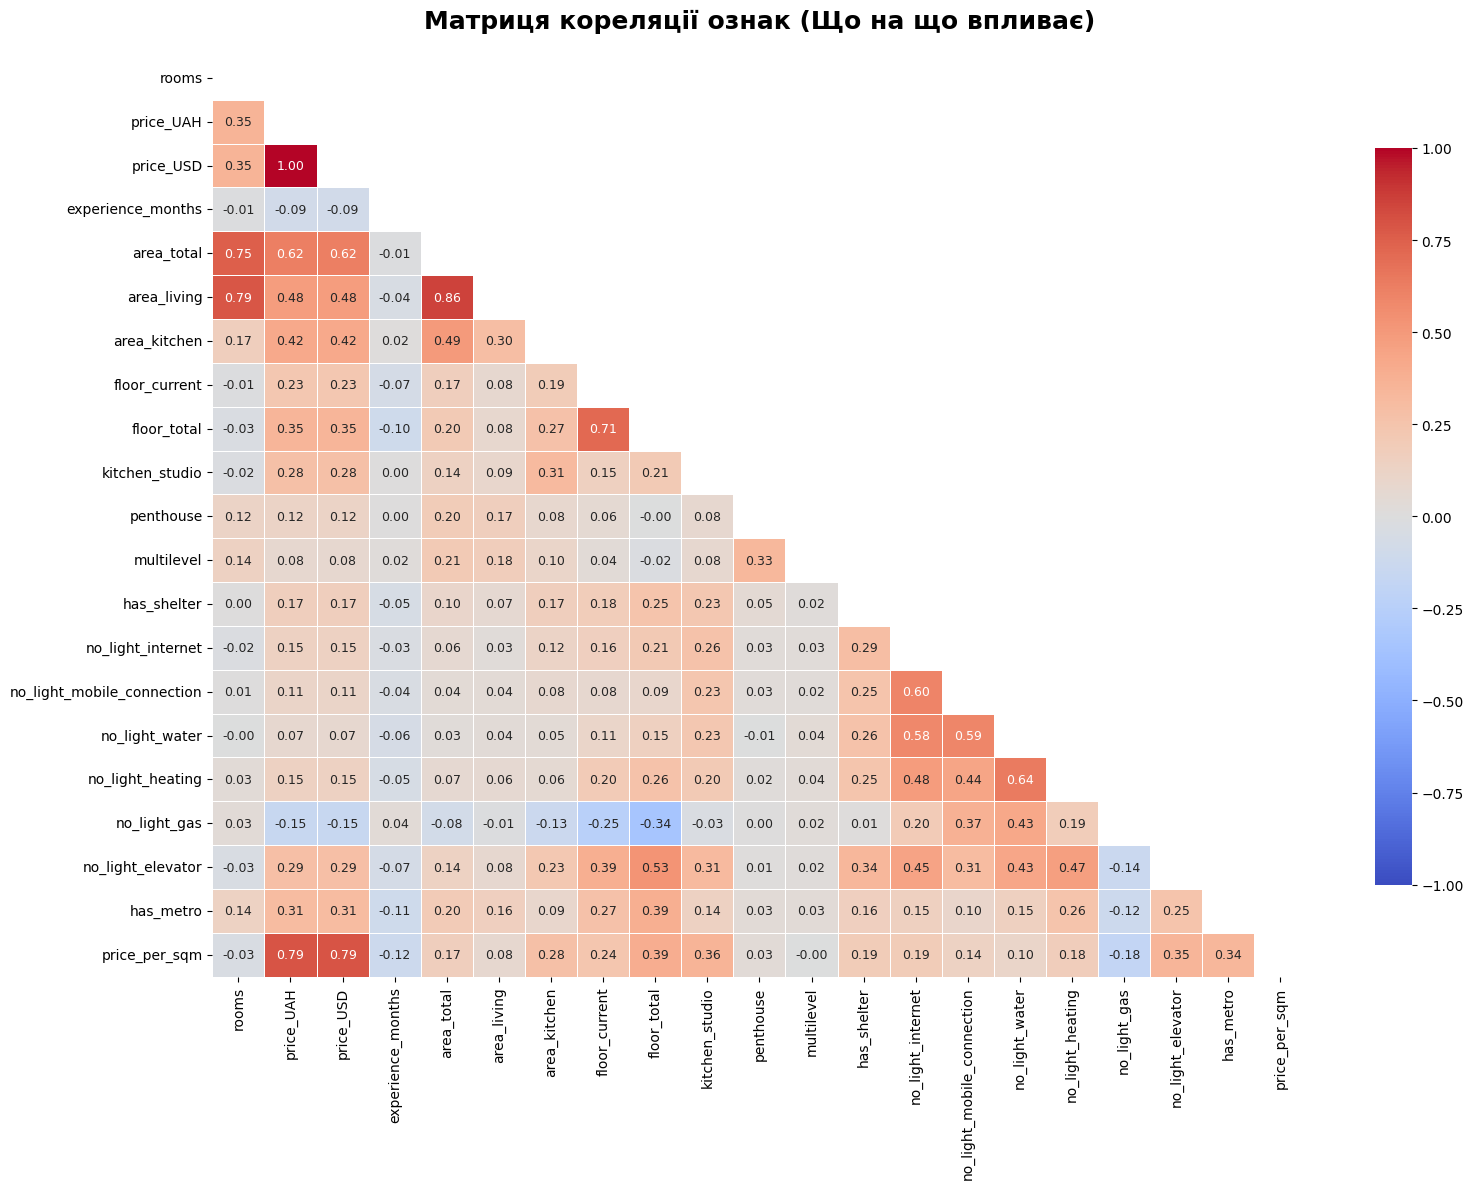

In [319]:
# ==========================================
# 1. ПІДГОТОВКА ДАНИХ
# ==========================================
# Вибираємо тільки числові та булеві (True/False) колонки
numeric_cols = cl_df.select_dtypes(include=[np.number, bool]).columns

# Створюємо датафрейм тільки з цими колонками
df_num = cl_df[numeric_cols].copy()

# Рахуємо саму кореляцію (метод Пірсона)
corr_matrix = df_num.corr()

# ==========================================
# 2. ПОБУДОВА ГРАФІКА (Heatmap)
# ==========================================
plt.figure(figsize=(16, 12)) # Робимо великий розмір, колонок багато

# Створюємо "маску", щоб приховати верхню половину матриці (вона віддзеркалює нижню)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Будуємо теплову карту
sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True,              # Показувати точні цифри
    fmt=".2f",               # 2 знаки після коми
    cmap="coolwarm",         # Палітра: синій (мінус) -> білий (нуль) -> червоний (плюс)
    vmin=-1, vmax=1,         # Жорсткі межі від -1 до 1
    center=0,                # Центр на нулі
    linewidths=0.5,          # Сітка між клітинками
    cbar_kws={"shrink": .8}, # Зменшуємо повзунок збоку
    annot_kws={"size": 9}    # Розмір шрифту цифр (зменшив, щоб не налізали)
)

plt.title('Матриця кореляції ознак (Що на що впливає)', fontsize=18, pad=20, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/05_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Acer\AppData\Local\Temp\ipykernel_20520\3779878640.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


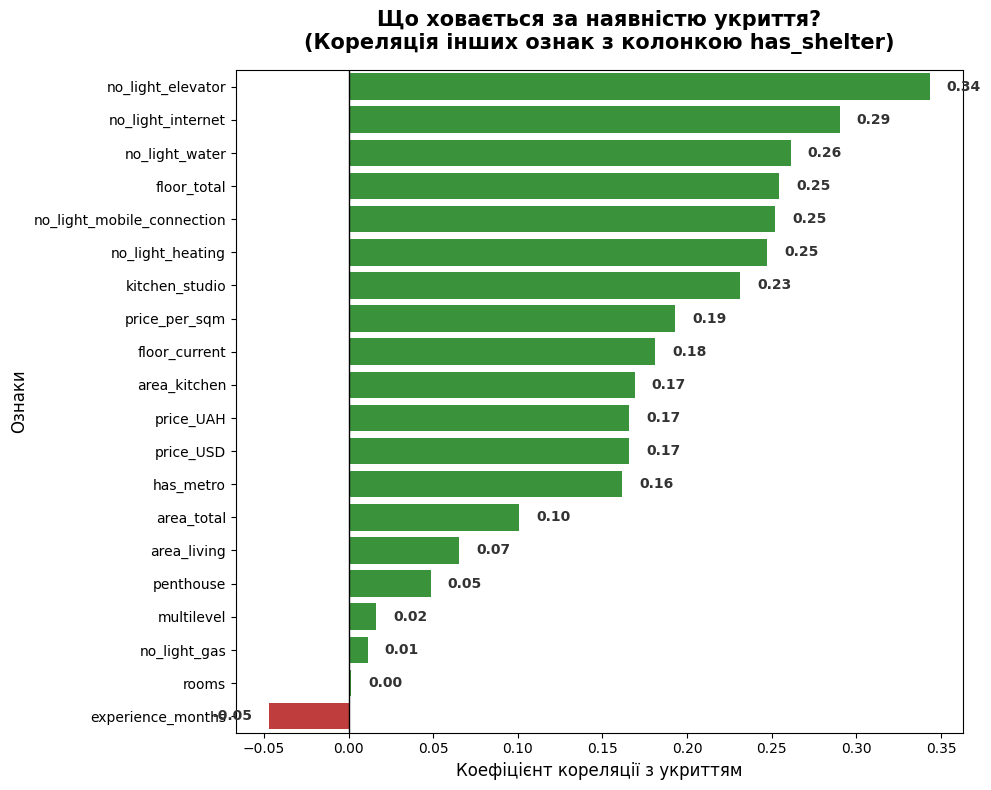

In [320]:
# ==========================================
# 1. ПІДГОТОВКА ДАНИХ
# ==========================================
# Беремо тільки числові та логічні колонки
numeric_cols = cl_df.select_dtypes(include=[np.number, bool]).columns
df_num = cl_df[numeric_cols].copy()

# Рахуємо кореляцію
corr_matrix = df_num.corr()

# ==========================================
# 2. ВИТЯГУЄМО "СУСІДІВ" УКРИТТЯ
# ==========================================
# Беремо тільки стовпець has_shelter і сортуємо його за спаданням
shelter_corr = corr_matrix[['has_shelter']].sort_values(by='has_shelter', ascending=False)

# Видаляємо саму has_shelter (бо вона сама з собою має ідеальну кореляцію 1.0)
shelter_corr = shelter_corr.drop(['has_shelter']) 

# ==========================================
# 3. ПОБУДОВА ГРАФІКА
# ==========================================
plt.figure(figsize=(10, 8))

# Фарбуємо додатні зв'язки в зелений, від'ємні в червоний
colors = ['#2CA02C' if c > 0 else '#D62728' for c in shelter_corr['has_shelter']]

ax = sns.barplot(
    x=shelter_corr['has_shelter'], 
    y=shelter_corr.index, 
    palette=colors
)

# Косметика
plt.title('Що ховається за наявністю укриття?\n(Кореляція інших ознак з колонкою has_shelter)', 
          fontsize=15, pad=15, fontweight='bold')
plt.xlabel('Коефіцієнт кореляції з укриттям', fontsize=12)
plt.ylabel('Ознаки', fontsize=12)

# Додаємо вертикальну лінію на нулі, щоб чітко бачити межу
plt.axvline(0, color='black', linewidth=1)

# Броньований метод додавання точних цифр на кінцях стовпчиків
for i, v in enumerate(shelter_corr['has_shelter']):
    # Трохи зсуваємо текст вправо для додатних і вліво для від'ємних, щоб він не налізав на стовпчик
    offset = 0.01 if v > 0 else -0.01
    ax.text(v + offset, i, f"{v:.2f}", 
            va='center', 
            ha='left' if v > 0 else 'right', 
            fontsize=10, fontweight='bold', color='#333333')

plt.tight_layout()
plt.savefig('plots/05_shelter_hidden_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

In [321]:
cl_df.head(3)

,id,rooms,price_UAH,price_USD,date,city_name,district,metro,address,seller,experience_months,seller_level,area_total,area_living,area_kitchen,floor_current,floor_total,kitchen_studio,penthouse,multilevel,has_shelter,pets,no_light_internet,no_light_mobile_connection,no_light_water,no_light_heating,no_light_gas,no_light_elevator,url,has_metro,year_month,price_per_sqm,region,segment
222,33956641,1,15000,340,2026-03-27,Київ,Харківський Масив,Вирлиця,вул. Кам’янська 6,Олена Гранд,18,Досвідчений,30.0,18.0,6.0,25,25,0,0,0,1,Не вказано,0,0,1,0,0,1,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-kiev-harkovskiy-massiv-kamenskaya-ulitsa-33956641.html,1,2026-03,500.0,м. Київ,Мас-маркет
212,33463352,1,9000,204,2026-03-27,Хмельницький,Ракове,Немає метро,"вул. Чорновола В’ячеслава 176/1, кв. 143",Юрій Анатолійович Яремчук,60,Експерт,55.7,17.4,11.3,1,4,0,0,0,0,Без тварин,0,0,0,0,0,0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-hmelnitskiy-rakovo-chernovola-vyacheslava-ulitsa-33463352.html,0,2026-03,161.579892,Хмельницька,Мас-маркет
214,33671390,1,30884,700,2026-03-27,Одеса,Аркадія,Немає метро,пров. Курортний 2,Олександр,28,Досвідчений,45.0,18.0,11.9,18,25,1,0,0,1,Без тварин,0,0,1,1,0,1,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-odessa-arkadiya-kurortnyy-pereulok-33671390.html,0,2026-03,686.311111,Одеська,Преміум


## 3. Аналіз гіпотез (Hypothesis Analysis)

### Тема 1: Вплив наявності укриття на вартість оренди

#### Гіпотеза 1.1: Географічна
Через бойові дії та вищі безпекові ризики наявність укриття сильніше впливає на ціноутворення оренди у східних та центральних регіонах порівняно із західними.

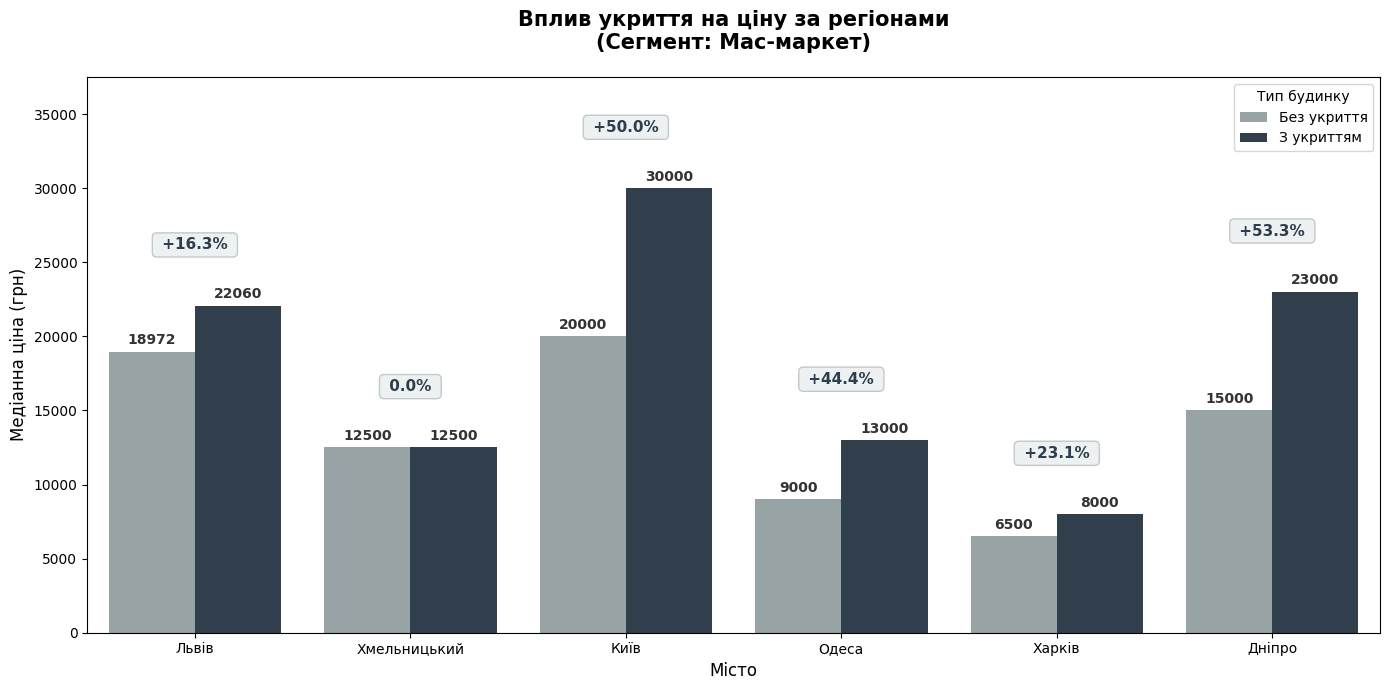

shelter_type  Без укриття  З укриттям
city_name                            
Дніпро            15000.0     23000.0
Київ              20000.0     30000.0
Львів             18972.0     22060.0
Одеса              9000.0     13000.0
Харків             6500.0      8000.0
Хмельницький      12500.0     12500.0


In [322]:
# ==========================================
# 1. ФІЛЬТРАЦІЯ ТА АГРЕГАЦІЯ
# ==========================================
target_cities = ['Львів', 'Хмельницький', 'Київ', 'Одеса', 'Харків', 'Дніпро']

# Фільтруємо мас-маркет ТА залишаємо тільки потрібні міста
df_shelter = cl_df[(cl_df['segment'] == 'Мас-маркет') & (cl_df['city_name'].isin(target_cities))].copy()

df_shelter['shelter_type'] = np.where(df_shelter['has_shelter'] == 1, 'З укриттям', 'Без укриття')

# Групуємо відразу за двома колонками: містом та наявністю укриття
stats = df_shelter.groupby(['city_name', 'shelter_type']).agg(
    median_price=('price_UAH', 'median')
).reset_index()

# Створюємо pivot-таблицю для зручного розрахунку різниці у відсотках
pivot_stats = stats.pivot(index='city_name', columns='shelter_type', values='median_price')

# ==========================================
# 2. ПОБУДОВА ГРАФІКА
# ==========================================
plt.figure(figsize=(14, 7)) # Трохи ширше для 6 міст та написів

# Спокійні кольори, які краще пасують до теми укриттів (сталеві/бетонні/нічні відтінки)
custom_palette = {'Без укриття': '#95a5a6', 'З укриттям': '#2c3e50'}
hue_order = ['Без укриття', 'З укриттям']

# order=target_cities жорстко фіксує порядок міст на осі X
ax = sns.barplot(
    data=stats, 
    x='city_name', 
    y='median_price',   
    hue='shelter_type',         
    palette=custom_palette,
    order=target_cities,
    hue_order=hue_order
)

# Косметика графіка
plt.title('Вплив укриття на ціну за регіонами\n(Сегмент: Мас-маркет)', fontsize=15, pad=20, fontweight='bold')
plt.xlabel('Місто', fontsize=12)
plt.ylabel('Медіанна ціна (грн)', fontsize=12)

# Підписи для згрупованих стовпчиків (більш надійний алгоритм)
for p in ax.patches:
    height = p.get_height()
    
    # Пропускаємо порожні стовпчики
    if np.isnan(height) or height == 0: 
        continue
        
    label_text = f"{int(height)}"
    
    # Додаємо текст над стовпчиком
    plt.text(p.get_x() + p.get_width() / 2., height + (stats['median_price'].max() * 0.01), 
             label_text, ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333333')

# Додаємо відсоток різниці між "З укриттям" та "Без укриття"
for i, city in enumerate(target_cities):
    if city in pivot_stats.index:
        try:
            price_no = pivot_stats.loc[city, 'Без укриття']
            price_yes = pivot_stats.loc[city, 'З укриттям']
            
            # Рахуємо різницю: (З укриттям - Без укриття) / Без укриття * 100
            if pd.notna(price_no) and pd.notna(price_yes) and price_no > 0:
                diff_pct = ((price_yes - price_no) / price_no) * 100
                
                max_height = max(price_no, price_yes)
                sign = "+" if diff_pct > 0 else ""
                diff_text = f" {sign}{diff_pct:.1f}% "
                
                # Розташовуємо по центру над парою стовпчиків (x = індекс міста)
                plt.text(i, max_height + (stats['median_price'].max() * 0.12), diff_text, 
                         ha='center', va='bottom', fontsize=11, fontweight='bold', color='#2c3e50',
                         bbox=dict(facecolor='#ecf0f1', alpha=0.9, edgecolor='#bdc3c7', boxstyle='round,pad=0.3'))
        except KeyError:
            continue

# Збільшуємо ліміт осі Y, щоб влізли плашки з відсотками
plt.ylim(0, stats['median_price'].max() * 1.25)

plt.legend(title='Тип будинку', loc='upper right')
plt.tight_layout()
plt.savefig('plots/test_analysis/h1_shelter_price_by_cities.png', dpi=300, bbox_inches='tight')
plt.show()

print(pivot_stats)

В аналіз не були включені квартири сегменту "Преміум", тому що зазвичай вони вже мають укриття як базову опцію, а їхня ціноутворююча модель кардинально відрізняється від мас-маркету через переплату за комфорт та дизайн.

Графік підтверджує гіпотезу: у містах з високими ризиками (Дніпро, Київ) націнка за укриття становить понад 50%, тоді як на заході (Хмельницький, Львів) вона мінімальна або нульова.

Аномальна різниця у 50% (наприклад, 10 000 грн для Києва) скоріш за все є наслідком побічної кореляції. Тобто на цю суму впливають й інші фактори. Щоб дізнатися "чисту" вартість виключно безпеки, ми відкинули загальні медіани і перейшли до порівняння абсолютно ідентичних квартир, щоб дізнатися чи має укриття різний регіональний вплив на ціноутворення.

In [323]:
# 1. Підготовка даних (фільтрація за містами та сегментом)
target_cities = ['Львів', 'Хмельницький', 'Київ', 'Одеса', 'Харків', 'Дніпро']
df_final = cl_df[(cl_df['segment'] == 'Мас-маркет') & 
                 (cl_df['city_name'].isin(target_cities)) & 
                 (cl_df['rooms'] <= 4)].copy()

# ==========================================
# 2. ГРУПУВАННЯ ЗА ЯКІСТЮ (ЦІНА ЗА КВАДРАТ)
# ==========================================
# Розбиваємо ціну за кв.м на 3 класи якості (Бюджет, Стандарт, Комфорт+)
# Це дозволяє порівнювати укриття серед об'єктів зі схожим рівнем ремонту
df_final['quality_bucket'] = pd.qcut(df_final['price_per_sqm'], q=3, 
                                     labels=['Бюджетний_сегмент', 'Середній_сегмент', 'Високий_сегмент'])

# ==========================================
# 3. ПОРІВНЯННЯ "ЯБЛУК З ЯБЛУКАМИ"
# ==========================================
# Групуємо за ФАКТАМИ: місто, район, кількість кімнат та рівень ціни за квадрат
grouped = df_final.groupby(['city_name', 'district', 'rooms', 'quality_bucket', 'has_shelter'], 
                           observed=True)['price_UAH'].median().unstack('has_shelter')

# Перейменовуємо для зрозумілості
grouped.columns = ['Без_укриття', 'З_укриттям']

# ЗАЛИШАЄМО ТІЛЬКИ ЧИСНІ ПАРИ (де в одному районі є об'єкти і з укриттям, і без)
grouped = grouped.dropna()

# ==========================================
# 4. РОЗРАХУНОК РЕЗУЛЬТАТІВ
# ==========================================
grouped['Чиста_різниця_грн'] = grouped['З_укриттям'] - grouped['Без_укриття']
grouped['Різниця_%'] = ((grouped['Чиста_різниця_грн'] / grouped['Без_укриття']) * 100).round(1)

# Скидаємо індекси для таблиці
comparison_results = grouped.reset_index()

print("МАТРИЦЯ ПОРІВНЯННЯ ЗА РАЙОНАМИ ТА ЯКІСТЮ:")
print(comparison_results.head(10).to_string(index=False))

# Фінальні медіанні показники чистого впливу
median_diff_pct = comparison_results['Різниця_%'].median()
median_diff_cash = comparison_results['Чиста_різниця_грн'].median()

print("\n" + "="*60)
print(f"ПІДСУМОК ПО ВСІХ РАЙОНАХ ТА СЕГМЕНТАХ:")
print(f"Реальна медіанна націнка за укриття: {int(median_diff_cash)} грн")
print(f"Реальна медіанна націнка у відсотках: {median_diff_pct}%")
print("="*60)

МАТРИЦЯ ПОРІВНЯННЯ ЗА РАЙОНАМИ ТА ЯКІСТЮ:
city_name                district  rooms    quality_bucket  Без_укриття  З_укриттям  Чиста_різниця_грн  Різниця_%
   Дніпро                1 травня      1   Високий_сегмент      28000.0     39708.0            11708.0       41.8
   Дніпро       Єврейська слобода      1   Високий_сегмент      24000.0     31442.0             7442.0       31.0
   Дніпро Амур-Нижньодніпровський      2 Бюджетний_сегмент      12500.0     16000.0             3500.0       28.0
   Дніпро                    ДІІТ      1  Середній_сегмент      10000.0     20000.0            10000.0      100.0
   Дніпро                 Косіора      1 Бюджетний_сегмент       8000.0      8000.0                0.0        0.0
   Дніпро                 Косіора      2  Середній_сегмент      14000.0     13000.0            -1000.0       -7.1
   Дніпро            Лівобережний      1  Середній_сегмент      14500.0     21000.0             6500.0       44.8
   Дніпро             Мандриківка      1  Сере

In [324]:
# ==========================================
# 1. ПІДГОТОВКА ТИХ САМИХ ДАНИХ
# ==========================================
target_cities = ['Київ', 'Львів', 'Одеса', 'Харків']

# Беремо мас-маркет і тільки наші 4 міста
df_reg = cl_df[(cl_df['segment'] == 'Мас-маркет') & 
               (cl_df['city_name'].isin(target_cities))].copy()

# ==========================================
# 2. ПОБУДОВА СТАТИСТИЧНОЇ МОДЕЛІ (РЕГРЕСІЯ)
# ==========================================
# Формула: Ціна залежить від Укриття + Міста + Району + Кількості кімнат + Площі
# statsmodels сам зрозуміє, що city_name та district - це текст, і розіб'є їх на категорії
formula = 'price_UAH ~ has_shelter + area_total + rooms + city_name + district'

# Навчаємо модель
model = smf.ols(formula=formula, data=df_reg).fit()

# ==========================================
# 3. ВИВІД РЕЗУЛЬТАТІВ
# ==========================================
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              price_UAH   R-squared:                       0.685
Model:                            OLS   Adj. R-squared:                  0.664
Method:                 Least Squares   F-statistic:                     32.98
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:30:06   Log-Likelihood:                -28877.
No. Observations:                2734   AIC:                         5.809e+04
Df Residuals:                    2564   BIC:                         5.910e+04
Df Model:                         169                                         
Covariance Type:            nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

C:\Users\Acer\AppData\Local\Temp\ipykernel_20520\3822496769.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


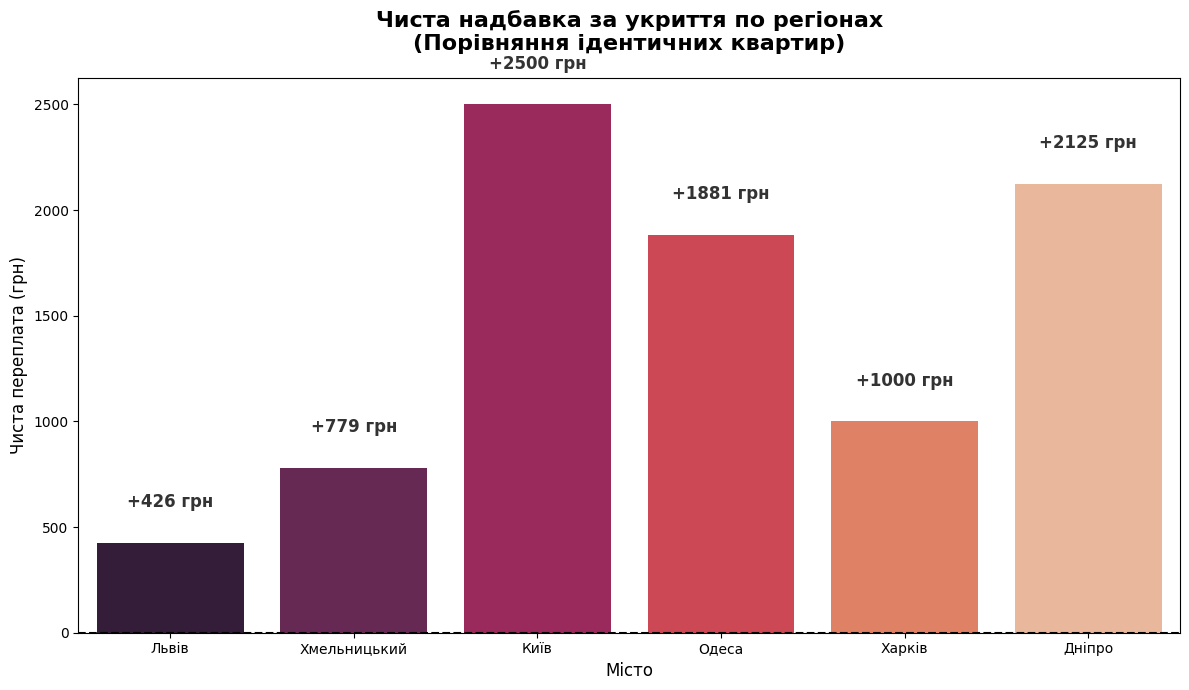

In [325]:
# ==========================================
# 1. ПІДГОТОВКА ДАНИХ ДЛЯ 6 МІСТ
# ==========================================
target_cities = ['Львів', 'Хмельницький', 'Київ', 'Одеса', 'Харків', 'Дніпро']

df_final = cl_df[(cl_df['segment'] == 'Мас-маркет') & 
                 (cl_df['city_name'].isin(target_cities)) & 
                 (cl_df['rooms'] <= 4)].copy()

# Розбиваємо ціну за кв.м на класи якості для чесного порівняння
df_final['quality_bucket'] = pd.qcut(df_final['price_per_sqm'], q=3, labels=['Бюджет', 'Стандарт', 'Комфорт+'])

# ==========================================
# 2. ПОРІВНЯННЯ "ЯБЛУК З ЯБЛУКАМИ"
# ==========================================
# Групуємо ідентичні об'єкти
grouped = df_final.groupby(['city_name', 'district', 'rooms', 'quality_bucket', 'has_shelter'], 
                           observed=True)['price_UAH'].median().unstack('has_shelter')

grouped.columns = ['Без_укриття', 'З_укриттям']
grouped = grouped.dropna() # Викидаємо нерівні умови

# Рахуємо чисту різницю в гривнях
grouped['Чиста_різниця_грн'] = grouped['З_укриттям'] - grouped['Без_укриття']

# ==========================================
# 3. АГРЕГАЦІЯ ПО МІСТАХ ДЛЯ ГРАФІКА
# ==========================================
comparison_results = grouped.reset_index()

# Знаходимо медіанну чисту націнку для кожного міста
city_pure_premium = comparison_results.groupby('city_name').agg(
    pure_premium=('Чиста_різниця_грн', 'median')
).reset_index()

# Сортуємо від найвищої доплати до найнижчої
city_pure_premium = city_pure_premium.sort_values(by='pure_premium', ascending=False)

# ==========================================
# 4. ПОБУДОВА ГРАФІКА
# ==========================================
plt.figure(figsize=(12, 7))

# Використовуємо градієнтну палітру: від червоного (велика націнка) до синього/сірого (мала націнка)
ax = sns.barplot(
    data=city_pure_premium, 
    x='city_name', 
    y='pure_premium', 
    palette='rocket',
    order= target_cities
)

plt.title('Чиста надбавка за укриття по регіонах\n(Порівняння ідентичних квартир)', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Місто', fontsize=12)
plt.ylabel('Чиста переплата (грн)', fontsize=12)

# Лінія нуля для наглядності
plt.axhline(0, color='black', linewidth=1.5, linestyle='--')

# Додаємо красиві підписи над стовпчиками
for p in ax.patches:
    height = p.get_height()
    
    # Якщо націнка вийшла нульова або від'ємна, трохи зміщуємо текст
    va = 'bottom' if height > 0 else 'top'
    offset = 150 if height > 0 else -150
    
    plt.text(p.get_x() + p.get_width() / 2., height + offset, 
             f"+{int(height)} грн" if height > 0 else f"{int(height)} грн", 
             ha='center', va=va, fontsize=12, fontweight='bold', color='#333333')

plt.tight_layout()
plt.savefig('plots/test_analysis/h1_real_increase_price_for_shelter.png', dpi=300, bbox_inches='tight')
plt.show()

Для того щоб очистити «ціну безпеки» від сторонніх факторів, ми застосували метод стратифікації. Всі квартири в датасеті були розбиті на групи за чотирма жорсткими критеріями: район міста, кількість кімнат, площа та ціна за квадратний метр (як показник класу об’єкта). Ми порівнювали медіанну вартість оренди тільки всередині цих груп, де об’єкти були фактично ідентичними за всіма параметрами, крім наявності укриття.

Паралельно результати були перевірені за допомогою моделі множинної регресії, яка математично ізолювала вплив кожного фактора. Обидва методи дали схожі результати: чиста націнка виключно за укриття становить у середньому 2000–2540 грн, що значно менше за первинні 50%.

Фінальні цифри підтверджують регіональну залежність. У Києві та Дніпрі орендарі готові платити за безпеку найбільше — від 2100 до 2500 грн. В Одесі цей показник становить близько 1900 грн. У Харкові, попри ризики, чиста націнка тримається на рівні 1000 грн через низьку платоспроможність ринку. Найменший вплив фактор безпеки має на заході: у Львові та Хмельницькому доплата за укриття мінімальна — від 400 до 800 грн.

##### **Висновок**

Первинні дані показували аномально високу надбавку за укриття (до 50%), що виявилося наслідком побічної кореляції з загальною вищою якістю сучасних житлових комплексів. Після очищення даних методами стратифікації ідентичних квартир та множинної регресії було встановлено справжню вартість безпеки: вона становить від 2100-2500 грн у містах високого ризику (Київ, Дніпро) до маргінальних 400-800 грн на заході країни (Львів, Хмельницький).

Гіпотеза щодо географічного розподілу націнки за укриття підтверджена ✅.

### Тема 2: Вплив поверху на вартість оренди

#### Гіпотеза 1.2: Вплив поверховості
Через загрозу обстрілів та перебої зі світлом у східних і центральних регіонах нижні поверхи коштують дорожче як більш безпечні та автономні, тоді як на заході вищу ціну зберігають верхні поверхи завдяки кращим видовим характеристикам.

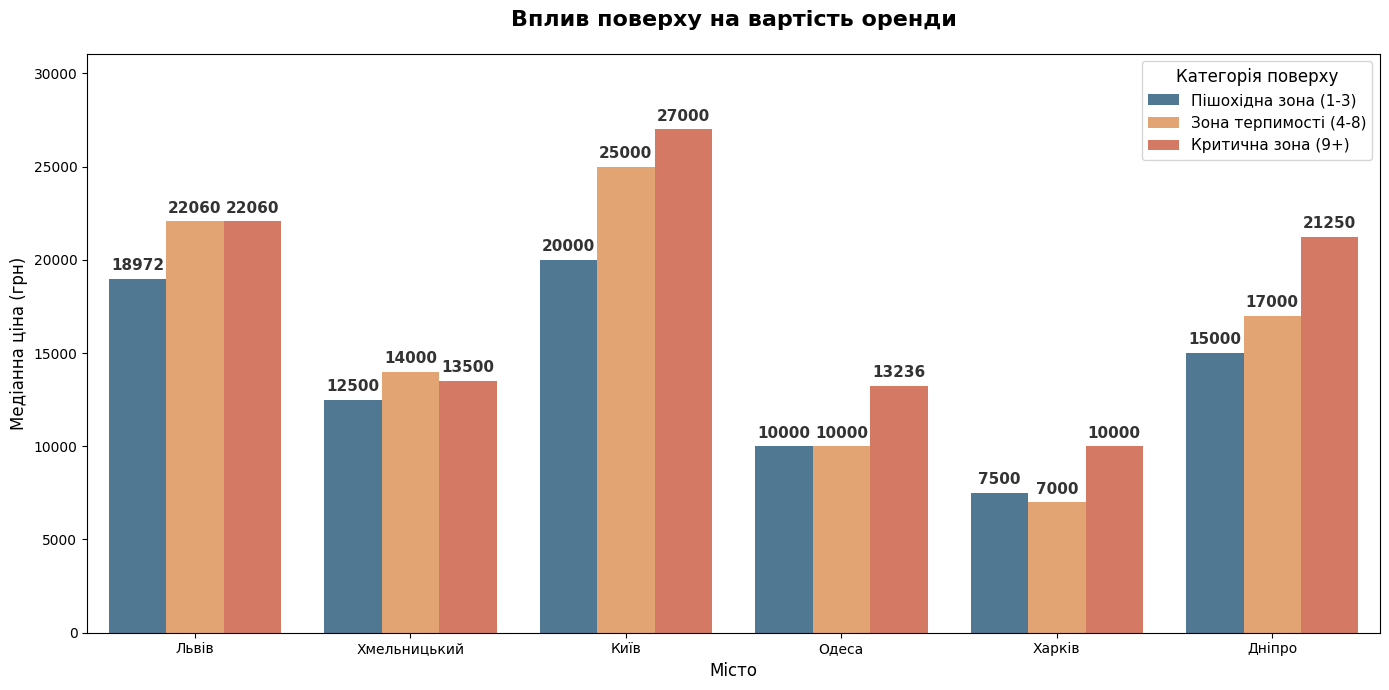

In [326]:
# ==========================================
# 1. ПІДГОТОВКА ДАНИХ (Весь датасет, 6 міст)
# ==========================================
target_cities = ['Львів', 'Хмельницький', 'Київ', 'Одеса', 'Харків', 'Дніпро']

# Беремо всі сегменти
df_floors = cl_df[cl_df['city_name'].isin(target_cities)].copy()

# ==========================================
# 2. КАТЕГОРИЗАЦІЯ ПОВЕРХІВ
# ==========================================
def categorize_floor(floor):
    if pd.isna(floor):
        return np.nan
    if floor <= 3:
        return 'Пішохідна зона (1-3)'
    elif floor <= 8:
        return 'Зона терпимості (4-8)'
    else:
        return 'Критична зона (9+)'

# Створюємо колонку з категоріями
df_floors['floor_category'] = df_floors['floor_current'].apply(categorize_floor)
df_floors = df_floors.dropna(subset=['floor_category']) # Викидаємо, якщо поверх не вказаний

# Рахуємо медіану
floor_stats = df_floors.groupby(['city_name', 'floor_category'])['price_UAH'].median().reset_index()

# Фіксуємо правильний порядок для графіка, щоб вони йшли логічно знизу вгору
floor_order = ['Пішохідна зона (1-3)', 'Зона терпимості (4-8)', 'Критична зона (9+)']
floor_stats['floor_category'] = pd.Categorical(floor_stats['floor_category'], categories=floor_order, ordered=True)

# ==========================================
# 3. ПОБУДОВА ГРАФІКА
# ==========================================
plt.figure(figsize=(14, 7))

# Приємна, "спокійна" палітра без плямистих кольорів
palette = ['#457b9d', '#f4a261', '#e76f51']

ax = sns.barplot(
    data=floor_stats,
    x='city_name',
    y='price_UAH',
    hue='floor_category',
    palette=palette,
    order=target_cities # Зберігаємо звичний порядок міст
)

plt.title('Вплив поверху на вартість оренди', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Місто', fontsize=12)
plt.ylabel('Медіанна ціна (грн)', fontsize=12)

# Додаємо красиві підписи цін над стовпчиками
for p in ax.patches:
    height = p.get_height()
    if pd.isna(height) or height == 0:
        continue
        
    ax.annotate(f'{int(height)}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=11, fontweight='bold', color='#333333',
                xytext=(0, 4), textcoords='offset points')

# Налаштовуємо легенду та відступи
plt.legend(title='Категорія поверху', fontsize=11, title_fontsize=12, loc='upper right')
# Трохи збільшуємо верхню межу, щоб цифри не налазили на край графіка
plt.ylim(0, floor_stats['price_UAH'].max() * 1.15)
plt.tight_layout()

# Зберігаємо та показуємо
plt.savefig('plots/test_analysis/h2_floor_impact.png', dpi=300, bbox_inches='tight')
plt.show()

Первинний аналіз загальних медіан показав зворотну картину: у всіх містах "критична зона" (9+ поверхів) виявилася суттєво дорожчою за нижні поверхи. Оскільки високі поверхи найчастіше представлені в нових ЖК, існував ризик побічної кореляції — можливо, люди переплачували не за висоту, а просто за сучасний будинок.

Щоб дізнатися правду, ми застосували метод стратифікації: порівняли ціни на 1-3 та 9+ поверхи виключно для ідентичних квартир (однаковий район, кількість кімнат та клас якості за ціною кв.м).

In [327]:
# ==========================================
# 1. ПІДГОТОВКА ТИХ САМИХ ПАРАМЕТРІВ
# ==========================================
target_cities = ['Львів', 'Хмельницький', 'Київ', 'Одеса', 'Харків', 'Дніпро']
df_similar = cl_df[cl_df['city_name'].isin(target_cities)].copy()

# Категоризуємо поверхи (беремо тільки крайні зони для чіткого порівняння)
def floor_compare(floor):
    if floor <= 3: return 'Низ (1-3)'
    if floor >= 9: return 'Верх (9+)'
    return None

df_similar['floor_type'] = df_similar['floor_current'].apply(floor_compare)
df_similar = df_similar.dropna(subset=['floor_type'])

# Створюємо кошики якості за ціною за квадрат (як у минулій гіпотезі)
df_similar['quality_bucket'] = pd.qcut(df_similar['price_per_sqm'], q=4, 
                                       labels=['Економ', 'Стандарт', 'Комфорт', 'Преміум'])

# ==========================================
# 2. ПОШУК СХОЖИХ КВАРТИР
# ==========================================
# Групуємо: район + кімнати + якість. Дивимось різницю між верхом і низом.
grouped_floors = df_similar.groupby(['city_name', 'district', 'rooms', 'quality_bucket', 'floor_type'], 
                                   observed=True)['price_UAH'].median().unstack('floor_type')

# Лишаємо тільки ті групи, де є І НИЗ, І ВЕРХ (чесне порівняння)
grouped_floors = grouped_floors.dropna()

# Рахуємо "Чисту переплату за верхній поверх"
grouped_floors['Чиста_різниця_грн'] = grouped_floors['Верх (9+)'] - grouped_floors['Низ (1-3)']

# ==========================================
# 3. ФІНАЛЬНИЙ РЕЗУЛЬТАТ ПО МІСТАХ
# ==========================================
city_floor_premium = grouped_floors.groupby('city_name')['Чиста_різниця_грн'].median().reset_index()
city_floor_premium = city_floor_premium.sort_values(by='Чиста_різниця_грн', ascending=False)

print("ЧИСТА ПЕРЕПЛАТА ЗА ВЕРХНІЙ ПОВЕРХ (9+) ПОРІВНЯНО З НИЖНІМ (1-3):")
print("-" * 65)
for index, row in city_floor_premium.iterrows():
    prefix = "+" if row['Чиста_різниця_грн'] > 0 else ""
    print(f"{row['city_name']:15} | {prefix}{int(row['Чиста_різниця_грн'])} грн")
print("-" * 65)

ЧИСТА ПЕРЕПЛАТА ЗА ВЕРХНІЙ ПОВЕРХ (9+) ПОРІВНЯНО З НИЖНІМ (1-3):
-----------------------------------------------------------------
Київ            | +3500 грн
Львів           | +2206 грн
Одеса           | +2000 грн
Харків          | +1875 грн
Хмельницький    | +1000 грн
Дніпро          | 0 грн
-----------------------------------------------------------------


Розрахунок "чистої" дельти остаточно розбив початкове припущення. Навіть в ідентичних умовах орендарі продовжують доплачувати за верхні поверхи:

У Києві премія за висоту становить +3500 грн.

У Львові та Одесі: +2000...2206 грн.

У Харкові (місті з найбільшими безпековими ризиками): +1875 грн.

Лише у Дніпрі різниця знівелювалася до 0 грн, зрівнявши попит на низ і верх.

**Висновок:**

Гіпотеза не підтвердилася ❌. Загроза обстрілів та відключення світла не змінили фундаментальних правил ринку нерухомості. Орендарі у всіх регіонах України (включно з прифронтовими) продовжують цінувати видові характеристики, кращу інсоляцію та відсутність вуличного шуму більше, ніж автономність нижніх поверхів. Крім того, сучасні висотні будинки все частіше обладнуються резервними генераторами для ліфтів та насосів, що робить страх перед блекаутами менш критичним фактором ціноутворення.

### Тема 3: Вплив можливості проживання з тваринами на ціну оренди

#### Гіпотеза 1.3: Націнка за "pet-friendly" статус
Через високий попит та обмежену пропозицію на ринку, власники квартир, які дозволяють проживання з тваринами, закладають у вартість оренди додаткову "премію за ризик" (можливе пошкодження ремонту чи меблів). Тому pet-friendly квартири коштують дорожче за аналогічні об'єкти, де проживання з улюбленцями суворо заборонено.

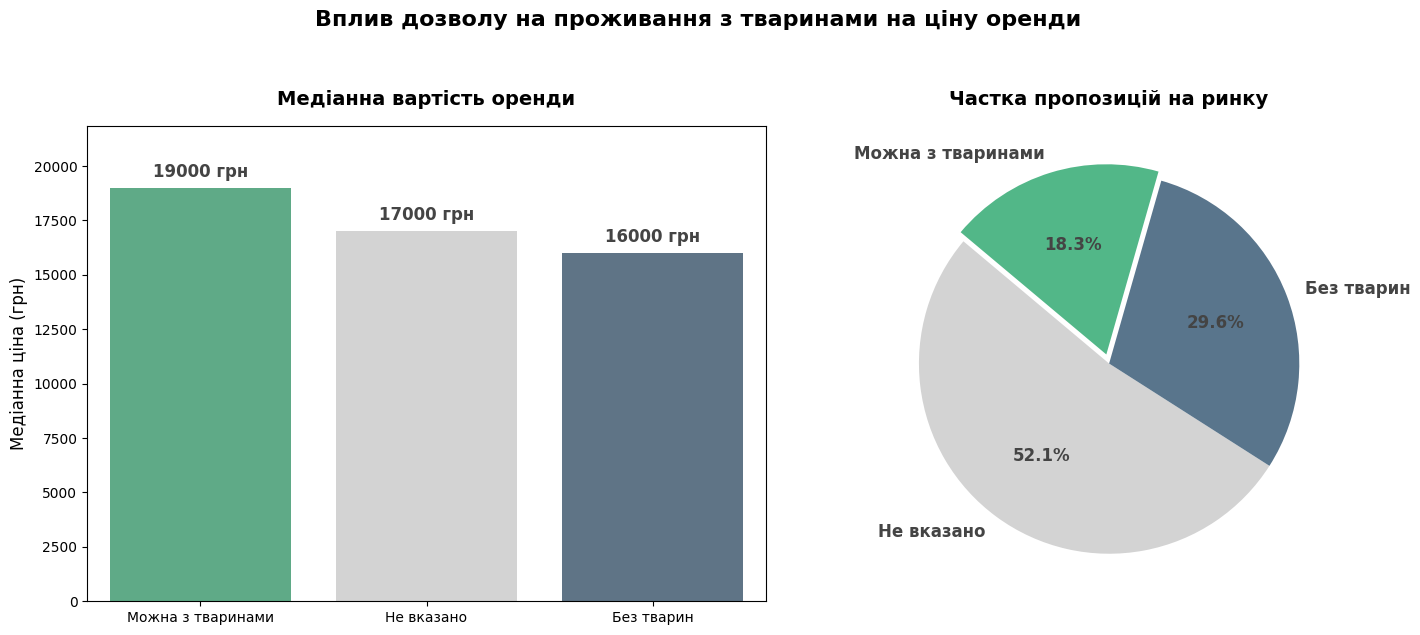

In [328]:
# ==========================================
# 1. ПІДГОТОВКА ДАНИХ (Вся Україна, Мас-маркет)
# ==========================================
# Беремо весь мас-маркет без обмежень по містах
df_pets_all = cl_df.copy()

df_pets_all['pets_category'] = df_pets_all['pets']

# Задаємо порядок і кольори
pets_order = ['Можна з тваринами', 'Не вказано', 'Без тварин']
color_map = {
    'Можна з тваринами': '#52b788', # Зелений 
    'Не вказано': '#d3d3d3',        # Світло-сірий
    'Без тварин': '#59758c'         # Синьо-сірий
}

# ==========================================
# 2. РОЗРАХУНКИ
# ==========================================
# Рахуємо медіану для барчарту
pets_stats = df_pets_all.groupby('pets_category')['price_UAH'].median().reindex(pets_order).reset_index()

# Рахуємо кількість для кругової діаграми
pets_counts = df_pets_all['pets_category'].value_counts()

# ==========================================
# 3. ПОБУДОВА ГРАФІКІВ ПОРУЧ (1 рядок, 2 колонки)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- ЛІВИЙ ГРАФІК: Медіанна ціна ---
sns.barplot(
    data=pets_stats,
    x='pets_category',
    y='price_UAH',
    palette=color_map,
    hue='pets_category',
    ax=axes[0],
    order=pets_order
)
axes[0].set_title('Медіанна вартість оренди', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('')
axes[0].set_ylabel('Медіанна ціна (грн)', fontsize=12)

# Додаємо підписи цін над стовпчиками
for p in axes[0].patches:
    height = p.get_height()
    if pd.isna(height) or height == 0:
        continue
    axes[0].annotate(f'{int(height)} грн',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=12, fontweight='bold', color="#444444",
                xytext=(0, 5), textcoords='offset points')
axes[0].set_ylim(0, pets_stats['price_UAH'].max() * 1.15)

# --- ПРАВИЙ ГРАФІК: Кругова діаграма (Частка ринку) ---
pie_colors = [color_map[label] for label in pets_counts.index]
# Робимо акцент (відриваємо шматок) тільки якщо це "Можна з тваринами"
explode = [0.05 if label == 'Можна з тваринами' else 0 for label in pets_counts.index]

axes[1].pie(
    pets_counts, 
    labels=pets_counts.index, 
    autopct='%1.1f%%', 
    startangle=140,
    colors=pie_colors, 
    explode=explode,
    textprops={'fontsize': 12, 'fontweight': 'bold', 'color': "#444444"}
)
axes[1].set_title('Частка пропозицій на ринку', fontsize=14, fontweight='bold', pad=15)

# Загальний заголовок для всієї картинки
plt.suptitle('Вплив дозволу на проживання з тваринами на ціну оренди            ', 
             fontsize=16, fontweight='bold', y=1.05)

plt.tight_layout()
plt.savefig('plots/test_analysis/h3_all_pets_ukraine_combined.png', dpi=300, bbox_inches='tight')
plt.show()

**Висновок:**

Дані чітко підтверджують наявність цінової націнки за pet-friendly статус. Ринок демонструє гострий дефіцит лояльних власників: лише 18.3% оголошень відкрито дозволяють жити з тваринами. Такий дисбаланс попиту та пропозиції дозволяє власникам диктувати умови та завищувати прайс. Медіанна вартість квартир, де раді тваринам, становить 19 000 грн — це на 3 000 грн дорожче за об'єкти з жорсткою забороною (16 000 грн). При цьому більше половини ринку (52.1%) взагалі не вказує цю умову в оголошеннях, утворюючи середній ціновий сегмент із медіаною 17 000 грн. Отже, відкритий дозвіл на котика чи собаку — це ексклюзивна опція, за яку власники спокійно накидають ціну зверху.

Гіпотеза щодо цінової націнки за pet-friendly статус повністю підтверджена ✅.

### Тема 4: Вплив автономності при відключеннях електроенергії на ціну оренди

#### Гіпотеза 4.1: Пріоритет критичної інфраструктури
Кожен елемент автономності збільшує вартість оренди, проте найбільшу цінову премію формують критичні для виживання опції: наявність гарантованого опалення та водопостачання. Додаткові опції комфорту, такі як робочий ліфт чи безперебійний інтернет, впливають на ціну менше, оскільки не є базовою потребою під час блекауту.

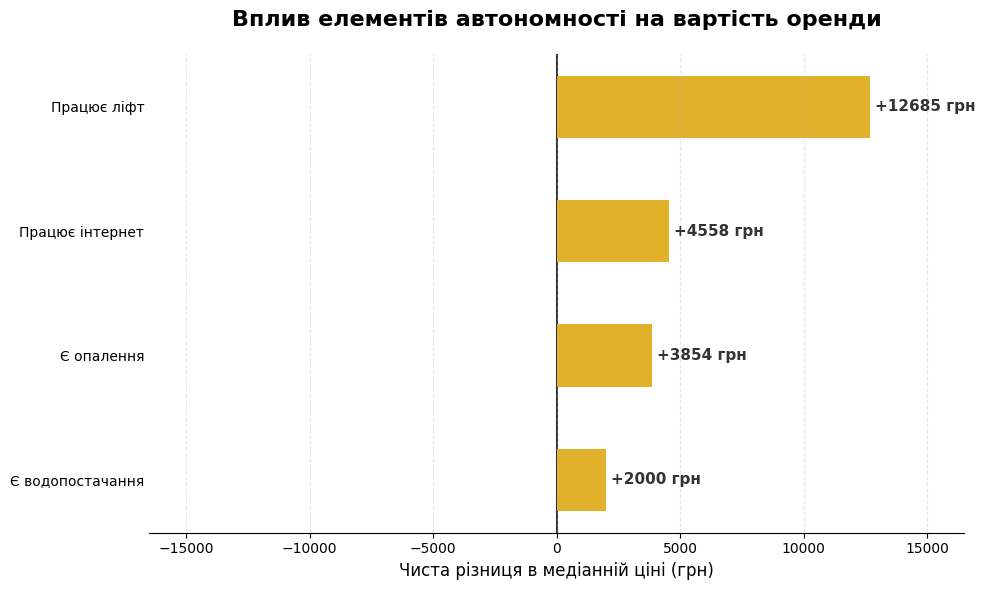

In [329]:
# ==========================================
# 1. ПІДГОТОВКА ДАНИХ 
# ==========================================
autonomy_features = {
    'no_light_internet': 'Працює інтернет',
    'no_light_water': 'Є водопостачання',
    'no_light_heating': 'Є опалення',
    'no_light_elevator': 'Працює ліфт'
}

results = []
for col, name in autonomy_features.items():
    cl_df[col] = pd.to_numeric(cl_df[col], errors='coerce').fillna(0)
    median_0 = cl_df[cl_df[col] == 0]['price_UAH'].median()
    median_1 = cl_df[cl_df[col] == 1]['price_UAH'].median()
    
    if pd.notna(median_0) and pd.notna(median_1):
        diff = median_1 - median_0
        results.append({'feature': name, 'diff': diff})

df_res = pd.DataFrame(results)

# Сортуємо від найбільшого здешевлення до найбільшої націнки
df_res = df_res.sort_values('diff', ascending=True).reset_index(drop=True)

# ==========================================
# 2. ПОБУДОВА ГРАФІКА ВІДХИЛЕНЬ (DIVERGING BARS)
# ==========================================
plt.figure(figsize=(10, 6))

# Визначаємо кольори: якщо > 0, то акцентний (наприклад, жовто-оранжевий), якщо < 0 - сіро-синій
colors = ['#e1b12c' if val > 0 else '#59758c' for val in df_res['diff']]

# Малюємо горизонтальні смуги
bars = plt.barh(df_res['feature'], df_res['diff'], color=colors, height=0.5)

# Малюємо чітку нульову лінію
plt.axvline(0, color='#333333', linewidth=1.5, zorder=0)

# Додаємо підписи значень прямо біля смуг
for bar, value in zip(bars, df_res['diff']):
    # Форматуємо текст (додаємо + для додатних)
    text = f"+{int(value)} грн" if value > 0 else f"{int(value)} грн"
    
    # Визначаємо позицію тексту (трохи відступаємо від краю смуги)
    if value > 0:
        plt.text(value + 200, bar.get_y() + bar.get_height()/2, text, 
                 va='center', ha='left', fontsize=11, fontweight='bold', color='#333333')
    else:
        plt.text(value - 200, bar.get_y() + bar.get_height()/2, text, 
                 va='center', ha='right', fontsize=11, fontweight='bold', color='#333333')

# Оформлення
plt.title('Вплив елементів автономності на вартість оренди', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Чиста різниця в медіанній ціні (грн)', fontsize=12)

# Розширюємо вісь X, щоб влізли підписи
max_abs_val = abs(df_res['diff']).max()
plt.xlim(-max_abs_val * 1.3, max_abs_val * 1.3)

# Легка сітка для зручності
plt.grid(axis='x', linestyle='--', alpha=0.3)

# Прибираємо зайві рамки
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)

# Прибираємо мітки на осі Y, залишаємо тільки текст
plt.tick_params(axis='y', length=0)

plt.tight_layout()
plt.savefig('plots/test_analysis/h4_autonomy_diverging.png', dpi=300)
plt.show()

Гіпотеза передбачала, що ринок найбільше оцінює базові потреби для виживання під час блекаутів, такі як опалення чи вода. Проте перший загальний графік показав парадоксальну картину: робочий ліфт дає аномальну націнку у майже 13 тисяч. Це класична ілюзія невідфільтрованих даних, де наявність генератору для ліфта є ознакою дорогих сучасних ЖК.

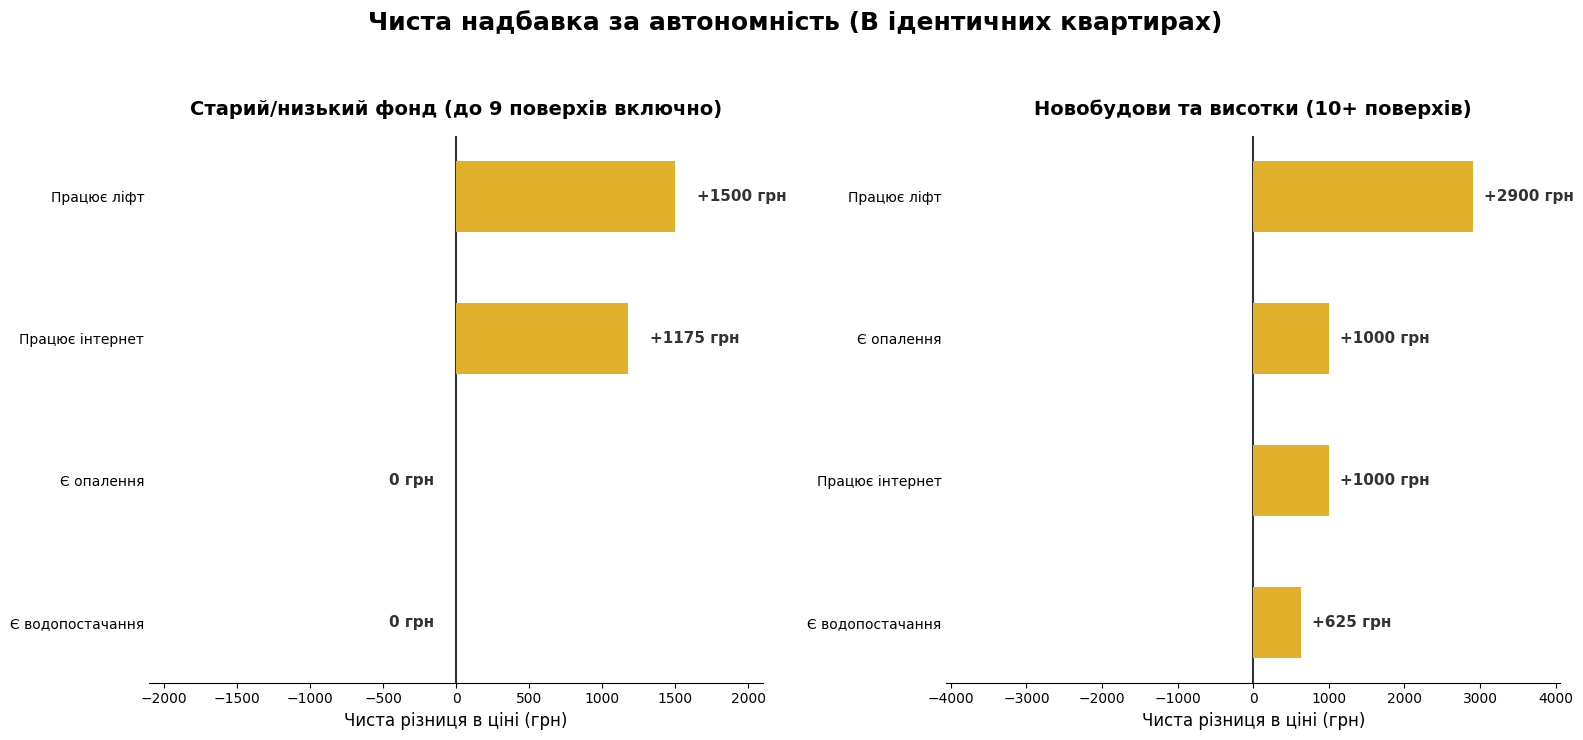

In [330]:
df_low = cl_df[(cl_df['segment'] == 'Мас-маркет') & (cl_df['rooms'] <= 4) & (cl_df['floor_total'] <= 9)].copy()
df_high = cl_df[(cl_df['segment'] == 'Мас-маркет') & (cl_df['rooms'] <= 4) & (cl_df['floor_total'] > 9)].copy()

df_low['area_bucket'] = pd.qcut(df_low['area_total'], q=3, labels=['Компактна', 'Стандартна', 'Простора'])
df_high['area_bucket'] = pd.qcut(df_high['area_total'], q=3, labels=['Компактна', 'Стандартна', 'Простора'])

autonomy_features = {
    'no_light_internet': 'Працює інтернет',
    'no_light_water': 'Є водопостачання',
    'no_light_heating': 'Є опалення',
    'no_light_elevator': 'Працює ліфт'
}

def get_pure_premium(df, min_comparisons=5):
    res = []
    for col, name in autonomy_features.items():
        df_clean = df.dropna(subset=[col]).copy()
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
        
        grouped = df_clean.groupby(['city_name', 'district', 'rooms', 'area_bucket', 'pets', col], observed=True)['price_UAH'].median().unstack(col)
        
        if not grouped.empty and len(grouped) >= min_comparisons:
            grouped['Чиста_різниця'] = grouped[1] - grouped[0]
            premium = grouped['Чиста_різниця'].median()
            res.append({'Опція': name, 'Чиста націнка': premium})
                
    return pd.DataFrame(res).sort_values('Чиста націнка', ascending=True).reset_index(drop=True)

res_low = get_pure_premium(df_low, min_comparisons=200)
res_high = get_pure_premium(df_high, min_comparisons=200)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

def draw_bar(ax, df_res, title):
    if df_res.empty:
        ax.set_title(title + "\n(Недостатньо даних)", fontsize=14, fontweight='bold')
        ax.axis('off')
        return
        
    colors = ['#e1b12c' if val > 0 else '#59758c' for val in df_res['Чиста націнка']]
    bars = ax.barh(df_res['Опція'], df_res['Чиста націнка'], color=colors, height=0.5)
    
    ax.axvline(0, color='#333333', linewidth=1.5, zorder=0)

    for bar, value in zip(bars, df_res['Чиста націнка']):
        text = f"+{int(value)} грн" if value > 0 else f"{int(value)} грн"
        offset = 150 if value > 0 else -150
        align = 'left' if value > 0 else 'right'
        ax.text(value + offset, bar.get_y() + bar.get_height()/2, text, 
                va='center', ha=align, fontsize=11, fontweight='bold', color='#333333')

    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Чиста різниця в ціні (грн)', fontsize=12)

    max_abs_val = abs(df_res['Чиста націнка']).max()
    if pd.isna(max_abs_val) or max_abs_val == 0:
        max_abs_val = 1000 
    ax.set_xlim(-max_abs_val * 1.4, max_abs_val * 1.4)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='y', length=0)

draw_bar(axes[0], res_low, 'Старий/низький фонд (до 9 поверхів включно)')
draw_bar(axes[1], res_high, 'Новобудови та висотки (10+ поверхів)')

plt.suptitle('Чиста надбавка за автономність (В ідентичних квартирах)', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('plots/test_analysis/h4_autonomy_area_bucket.png', dpi=300, bbox_inches='tight')
plt.show()

Щоб дізнатися справжню ціну автономності, ми ізолювали вплив віку та класу житла, порівнявши квартири однакової площі всередині двох категорій: до 9 поверхів та від 10 поверхів. Очищені дані показали зовсім іншу реальність. У старому фонді базові комунікації (вода, тепло) є настільки базовим стандартом, що не формують жодної додаткової націнки, тоді як комфорт у вигляді стабільного інтернету та ліфта додає понад 1000 грн. У висотних новобудовах абсолютним лідером є робочий ліфт (+2900 грн), оскільки без нього життя на високих поверхах блокується. Інтернет, водопостачання та опалення тут цінуються однаково високо (близько +1000 грн).

**Висновок:**

Гіпотезу спростовано ❌. Ринок оренди в умовах блекаутів пріоритезує не просто «мінімум для виживання», а збереження звичного способу життя та мобільності. Найбільшу чисту цінову премію орендарі готові платити за працюючий ліфт (особливо у висотках) та безперебійний інтернет.

Водночас наявність опалення та водопостачання у старому низькому фонді сприймається як базовий стандарт за замовчуванням, що практично не створює додаткової фінансової цінності при порівнянні ідентичних об'єктів. Проте у нових висотках ці опції стають ключовими маркерами автономності, за які власники обґрунтовано додають націнку. Це пояснюється тим, що у сучасних ЖК робота котелень та подача води на верхні поверхи прямо залежать від наявності будинкових генераторів, тоді як у старому фонді ці системи переважно залишаються централізованими.

### Тема 5: Особливості ціноутворення однокімнатних квартир на ринку оренди

#### Гіпотеза 5.1: Однокімнатні квартири мають найвищу вартість за квадратний метр через максимальний попит.
Через високу ліквідність та найширшу цільову аудиторію (студенти, молоді спеціалісти, пари без дітей), однокімнатні квартири є найзатребуванішими на ринку. Це призводить до того, що їхня вартість у перерахунку на один квадратний метр є найвищою порівняно з дво-, три- та чотирикімнатними об'єктами. 

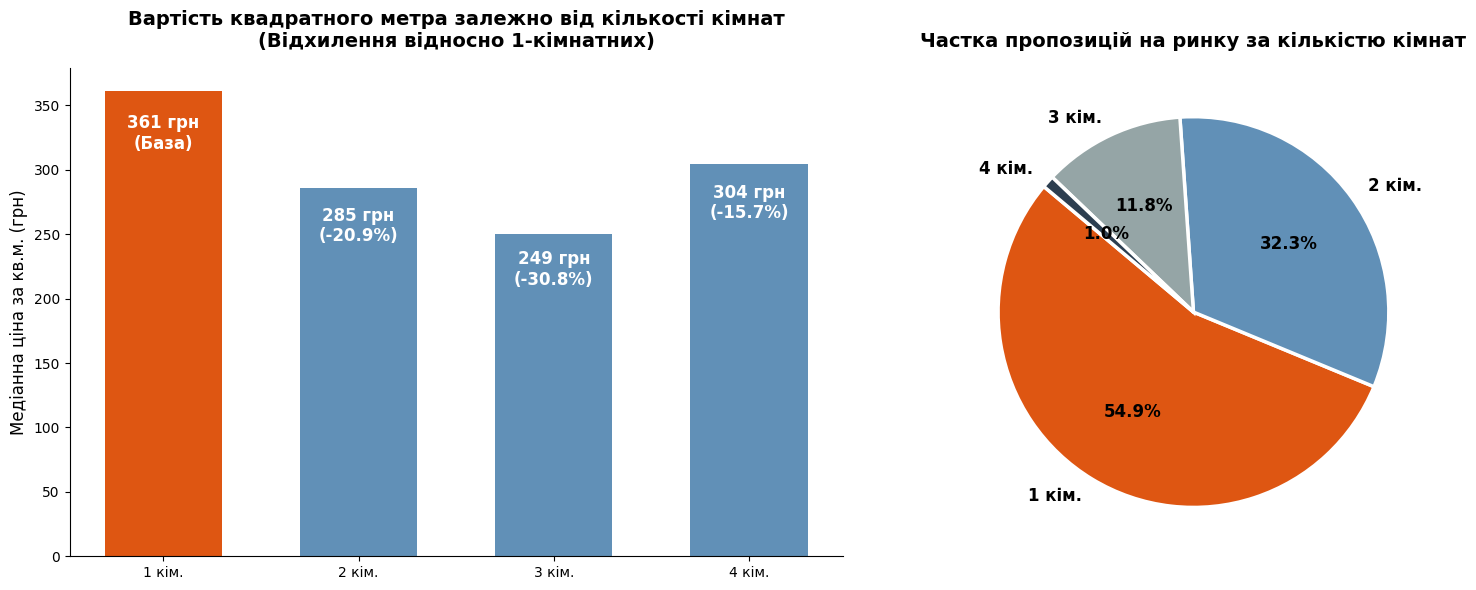

In [331]:
# Фільтруємо дані
df_standard = cl_df[(cl_df['segment'] == 'Мас-маркет') & (cl_df['rooms'] >= 1) & (cl_df['rooms'] <= 4)].copy()

# Підготовка даних для графіка 1 (Стовпці)
price_per_sqm_by_rooms = df_standard.groupby('rooms', observed=True)['price_per_sqm'].median()
base_price = price_per_sqm_by_rooms[1]

# Підготовка даних для графіка 2 (Кругова діаграма)
rooms_count = df_standard['rooms'].value_counts().sort_index()

# Створюємо фігуру з двома графіками поруч
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ==========================================
# 1. СТОВПЧАСТИЙ ГРАФІК (ЛІВОРУЧ)
# ==========================================
colors_bar = ["#de5612" if r == 1 else "#6190b7" for r in price_per_sqm_by_rooms.index]
bars = axes[0].bar(price_per_sqm_by_rooms.index.astype(str) + ' кім.', price_per_sqm_by_rooms.values, color=colors_bar, width=0.6)

axes[0].set_title('Вартість квадратного метра залежно від кількості кімнат\n(Відхилення відносно 1-кімнатних)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel('Медіанна ціна за кв.м. (грн)', fontsize=12)

# Підписи значень
for idx, bar in zip(price_per_sqm_by_rooms.index, bars):
    yval = bar.get_height()
    
    if idx == 1:
        text = f"{int(yval)} грн\n(База)"
    else:
        pct_diff = ((yval - base_price) / base_price) * 100
        sign = '+' if pct_diff > 0 else ''
        text = f"{int(yval)} грн\n({sign}{pct_diff:.1f}%)"
        
    axes[0].text(bar.get_x() + bar.get_width()/2, yval - (yval * 0.05), text, 
                 ha='center', va='top', color='white', fontweight='bold', fontsize=12)

axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ==========================================
# 2. КРУГОВА ДІАГРАМА (ПРАВОРУЧ)
# ==========================================
# Кольори для діаграми в тон лівому графіку
colors_pie = ['#de5612', '#6190b7', '#95a5a6', '#2c3e50'] 

axes[1].pie(rooms_count.values, 
        labels=[f"{int(idx)} кім." for idx in rooms_count.index], 
        colors=colors_pie, 
        autopct='%1.1f%%', 
        startangle=140, 
        textprops={'fontsize': 12, 'fontweight': 'bold'},
        wedgeprops={'edgecolor': 'white', 'linewidth': 2.5})

axes[1].set_title('Частка пропозицій на ринку за кількістю кімнат', fontsize=14, fontweight='bold', pad=15)

# Фінальне компонування
plt.tight_layout()
plt.savefig('plots/21_price_and_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

**Висновок:**
 
Гіпотезу підтверджено ✅ щодо найвищої вартості однокімнатних квартир. Однокімнатні об'єкти дійсно є найдорожчими на ринку (361 грн за квадрат), що повністю підтверджує масову переплату за приватність та стабільно високий попит. Зі збільшенням площі вартість метра стрімко падає: двокімнатні дешевші на 21%, а трикімнатні виявилися найбільш економічно вигідним варіантом для орендаря, даючи знижку майже 31% за кожен метр порівняно з «однушкою».

Проте на чотирикімнатних квартирах тренд ламається і ціна знову йде вгору. Це пояснюється специфікою самого ринку: такі великі площі є рідкістю для класичного мас-маркету, вибірка там значно менша, а самі об'єкти часто мають нестандартні планування (наприклад, дворівневі), що одразу тягне медіанну ціну вгору.

#### Гіпотеза 5.2: Премія за формат "кухня-студія" в однокімнатних квартирах

Наявність планування "кухня-студія" дозволяє власникам формувати додаткову цінову премію. Такий формат є сучаснішим і найчастіше свідчить про новий житловий фонд або свіжий дизайнерський ремонт, що значно підвищує медіанну вартість оренди порівняно зі стандартними однокімнатними квартирами з глухою стіною та відокремленою кухнею.

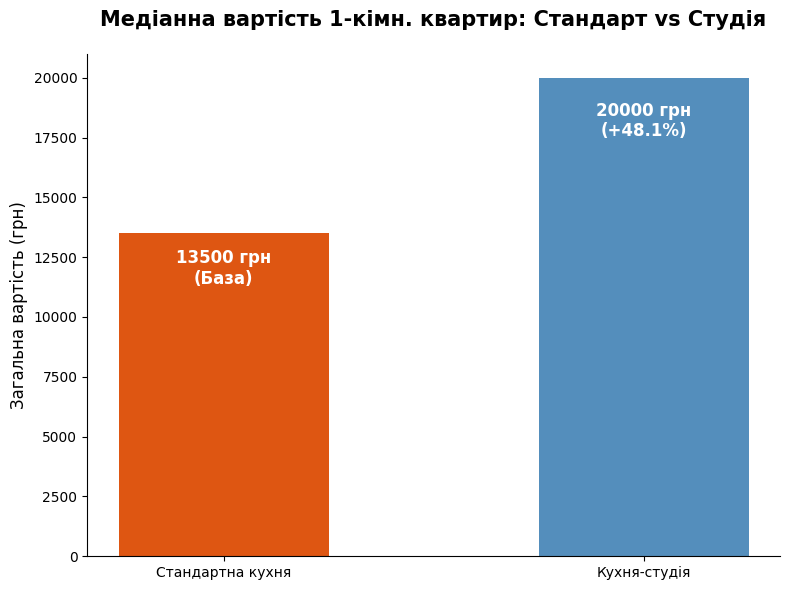

In [332]:
df_1room = cl_df[(cl_df['segment'] == 'Мас-маркет') & (cl_df['rooms'] == 1)].copy()

studio_price = df_1room.groupby('kitchen_studio', observed=True)['price_UAH'].median()

base_price = studio_price.get(0, 0)
studio_val = studio_price.get(1, 0)

plt.figure(figsize=(8, 6))

labels = ['Стандартна кухня', 'Кухня-студія']
values = [base_price, studio_val]
colors = ['#de5612', "#548ebc",]

bars = plt.bar(labels, values, color=colors, width=0.5)

plt.title('Медіанна вартість 1-кімн. квартир: Стандарт vs Студія', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Загальна вартість (грн)', fontsize=12)

for bar, val in zip(bars, values):
    yval = bar.get_height()
    
    if val == base_price:
        text = f"{int(yval)} грн\n(База)"
    else:
        pct_diff = ((yval - base_price) / base_price) * 100 if base_price > 0 else 0
        sign = '+' if pct_diff > 0 else ''
        text = f"{int(yval)} грн\n({sign}{pct_diff:.1f}%)"
        
    plt.text(bar.get_x() + bar.get_width()/2, yval - (yval * 0.05), text, 
             ha='center', va='top', color='white', fontweight='bold', fontsize=12)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('plots/22_studio_premium.png', dpi=300, bbox_inches='tight')
plt.show()

**Висновок:**

Гіпотезу повністю підтверджено✅. Планування "кухня-студія" в однокімнатних квартирах дозволяє власникам підняти медіанну вартість оренди аж на 48.1%. Така колосальна націнка з 13500 до 20000 грн доводить, що студія є не просто варіантом планування, а потужним маркером свіжого ремонту та нового житлового фонду, за який орендарі готові суттєво переплачувати.

In [333]:
cl_df['floor_current'].value_counts().sort_index(ascending=False)

floor_current
34      1
33      1
30      3
29      2
28      6
27      3
26      9
25     19
24     39
23     45
22     34
21     45
20     53
19     45
18     72
17     76
16     95
15    101
14     98
13    107
12    116
11    151
10    226
9     341
8     336
7     382
6     398
5     508
4     550
3     670
2     694
1     420
Name: count, dtype: Int64

In [334]:
cl_df.info()

<class 'pandas.DataFrame'>
Index: 5646 entries, 222 to 6208
Data columns (total 34 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   id                          5646 non-null   str           
 1   rooms                       5646 non-null   Int64         
 2   price_UAH                   5646 non-null   Int64         
 3   price_USD                   5646 non-null   Int64         
 4   date                        5646 non-null   datetime64[us]
 5   city_name                   5646 non-null   str           
 6   district                    5646 non-null   str           
 7   metro                       5646 non-null   str           
 8   address                     5646 non-null   str           
 9   seller                      5646 non-null   str           
 10  experience_months           5646 non-null   int64         
 11  seller_level                5646 non-null   str           
 12  area_t

In [335]:
cl_df.head(3)

,id,rooms,price_UAH,price_USD,date,city_name,district,metro,address,seller,experience_months,seller_level,area_total,area_living,area_kitchen,floor_current,floor_total,kitchen_studio,penthouse,multilevel,has_shelter,pets,no_light_internet,no_light_mobile_connection,no_light_water,no_light_heating,no_light_gas,no_light_elevator,url,has_metro,year_month,price_per_sqm,region,segment
222,33956641,1,15000,340,2026-03-27,Київ,Харківський Масив,Вирлиця,вул. Кам’янська 6,Олена Гранд,18,Досвідчений,30.0,18.0,6.0,25,25,0,0,0,1,Не вказано,0,0,1,0,0,1,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-kiev-harkovskiy-massiv-kamenskaya-ulitsa-33956641.html,1,2026-03,500.0,м. Київ,Мас-маркет
212,33463352,1,9000,204,2026-03-27,Хмельницький,Ракове,Немає метро,"вул. Чорновола В’ячеслава 176/1, кв. 143",Юрій Анатолійович Яремчук,60,Експерт,55.7,17.4,11.3,1,4,0,0,0,0,Без тварин,0,0,0,0,0,0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-hmelnitskiy-rakovo-chernovola-vyacheslava-ulitsa-33463352.html,0,2026-03,161.579892,Хмельницька,Мас-маркет
214,33671390,1,30884,700,2026-03-27,Одеса,Аркадія,Немає метро,пров. Курортний 2,Олександр,28,Досвідчений,45.0,18.0,11.9,18,25,1,0,0,1,Без тварин,0,0,1,1,0,1,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-odessa-arkadiya-kurortnyy-pereulok-33671390.html,0,2026-03,686.311111,Одеська,Преміум
